In [68]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Time series diagnostics
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.gofplots import qqplot

# Time series models
from statsmodels.tsa.statespace.sarimax import SARIMAX

# ML models for later sections
from sklearn.linear_model import Ridge, Lasso, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier, GradientBoostingRegressor, GradientBoostingClassifier

# Prophet for later sections
try:
    from prophet import Prophet
except ImportError:
    from fbprophet import Prophet

# Plot settings
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.grid"] = True

RANDOM_STATE = 42

In [69]:
multivariate_path = r"C:\Users\lamby\Downloads\Final Code 2\Final Code\Miami_and_Hialeah_with_environmental_factors.csv"

df_multi = pd.read_csv(multivariate_path)

print("Dataset shape:", df_multi.shape)
df_multi.head()

Dataset shape: (15759, 57)


,TRAPID,City,YEAR,MONTH,WEEK,Cx_quinquefasciatus_fem,Manhole_within_1KM,ElevationinFeet,DistancetoCanal,POVERTY_RATE,...,Min_Temperature-2,Mean_Temperature-3,Max_Temperature-3,Min_Temperature-3,Mean_Temperature-4,Max_Temperature-4,Min_Temperature-4,Mean_Temperature-5,Max_Temperature-5,Min_Temperature-5
0,BR2,Miami,2016,9,1,1.0,35.0,9.89,1054.359932,13.8,...,79.525000,84.508732,92.300,78.020000,82.493122,90.860000,75.920000,83.403694,90.020000,75.045714
1,CC107,Miami,2018,8,2,3.0,27.0,15.86,401.826224,28.4,...,76.266667,83.238805,91.075,76.725000,84.425721,92.266667,78.400000,82.611552,91.600000,74.920000
2,CC107,Miami,2018,8,3,1.0,27.0,15.86,401.826224,28.4,...,77.666667,81.081190,87.700,76.266667,83.238805,91.075000,76.725000,84.425721,92.266667,78.400000
3,CC107,Miami,2018,9,2,3.0,27.0,15.86,401.826224,28.4,...,78.187500,82.469029,89.100,75.416667,84.138739,89.700000,77.366667,82.060519,91.266667,73.900000
4,CC107,Miami,2018,9,3,8.0,27.0,15.86,401.826224,28.4,...,75.483333,82.415094,87.380,78.187500,82.469029,89.100000,75.416667,84.138739,89.700000,77.366667


In [70]:
display(df_multi.info())

display(df_multi.describe(include="all").T.head(20))

missing_summary = (
    df_multi
    .isna()
    .sum()
    .sort_values(ascending=False)
    .to_frame("Missing Count")
)

missing_summary["Missing Percent"] = (
    missing_summary["Missing Count"] / len(df_multi)
) * 100

missing_summary.head(20)

<class 'pandas.DataFrame'>
RangeIndex: 15759 entries, 0 to 15758
Data columns (total 57 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TRAPID                   15759 non-null  str    
 1   City                     15759 non-null  str    
 2   YEAR                     15759 non-null  int64  
 3   MONTH                    15759 non-null  int64  
 4   WEEK                     15759 non-null  int64  
 5   Cx_quinquefasciatus_fem  15759 non-null  float64
 6   Manhole_within_1KM       15759 non-null  float64
 7   ElevationinFeet          15759 non-null  float64
 8   DistancetoCanal          15759 non-null  float64
 9   POVERTY_RATE             15759 non-null  float64
 10  POVERTY_NUMBER           15759 non-null  float64
 11  NDVI                     15759 non-null  float64
 12  NDVI_-1                  15759 non-null  float64
 13  WATER_BODY               15759 non-null  float64
 14  WATER_BODY_-1            15759 no

None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
TRAPID,15759,166,WY14,246,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,15759,2,Miami,13854,NaN,NaN,NaN,NaN,NaN,NaN,NaN
YEAR,15759.0,NaN,NaN,NaN,2019.165873,1.576786,2016.0,2018.0,2019.0,2021.0,2021.0
MONTH,15759.0,NaN,NaN,NaN,6.264928,3.41468,1.0,3.0,6.0,9.0,12.0
WEEK,15759.0,NaN,NaN,NaN,2.710895,1.285465,1.0,2.0,3.0,4.0,5.0
Cx_quinquefasciatus_fem,15759.0,NaN,NaN,NaN,23.583677,51.92706,1.0,3.0,8.0,22.0,1040.0
Manhole_within_1KM,15759.0,NaN,NaN,NaN,11.042605,8.685146,0.0,4.0,10.0,16.0,37.0
ElevationinFeet,15759.0,NaN,NaN,NaN,9.442971,3.751508,-1.0,6.83,8.48,13.205,27.610001
DistancetoCanal,15759.0,NaN,NaN,NaN,1189.733598,955.803491,39.466176,398.651073,989.485092,1900.565981,7124.57148
POVERTY_RATE,15759.0,NaN,NaN,NaN,19.241737,13.894546,0.0,8.3,14.9,26.88,63.1


,Missing Count,Missing Percent
TRAPID,0,0.0
City,0,0.0
YEAR,0,0.0
MONTH,0,0.0
WEEK,0,0.0
Cx_quinquefasciatus_fem,0,0.0
Manhole_within_1KM,0,0.0
ElevationinFeet,0,0.0
DistancetoCanal,0,0.0
POVERTY_RATE,0,0.0


In [71]:
TARGET_COL = "Cx_quinquefasciatus_fem"

df_multi["City"] = df_multi["City"].astype(str).str.strip()

for col in df_multi.columns:
    if col not in ["TRAPID", "City"]:
        df_multi[col] = pd.to_numeric(df_multi[col], errors="coerce")

df_multi = df_multi.sort_values(["City", "YEAR", "MONTH", "WEEK", "TRAPID"]).reset_index(drop=True)

df_multi["time_period"] = (
    df_multi["YEAR"].astype(int).astype(str)
    + "-"
    + df_multi["MONTH"].astype(int).astype(str).str.zfill(2)
    + "-W"
    + df_multi["WEEK"].astype(int).astype(str)
)

df_multi[["City", "YEAR", "MONTH", "WEEK", "time_period"]].head()

,City,YEAR,MONTH,WEEK,time_period
0,Hialeah,2016,9,1,2016-09-W1
1,Hialeah,2016,9,2,2016-09-W2
2,Hialeah,2016,9,3,2016-09-W3
3,Hialeah,2016,9,3,2016-09-W3
4,Hialeah,2016,9,3,2016-09-W3


In [72]:
df_multi["approx_day"] = 1 + (df_multi["WEEK"] - 1) * 7

df_multi["approx_day"] = df_multi["approx_day"].clip(lower=1, upper=28)

df_multi["date"] = pd.to_datetime(
    dict(
        year=df_multi["YEAR"].astype(int),
        month=df_multi["MONTH"].astype(int),
        day=df_multi["approx_day"].astype(int)
    ),
    errors="coerce"
)

df_multi = df_multi.sort_values(["City", "date", "TRAPID"]).reset_index(drop=True)

df_multi[["City", "YEAR", "MONTH", "WEEK", "date", "time_period"]].head()

,City,YEAR,MONTH,WEEK,date,time_period
0,Hialeah,2016,9,1,2016-09-01,2016-09-W1
1,Hialeah,2016,9,2,2016-09-08,2016-09-W2
2,Hialeah,2016,9,3,2016-09-15,2016-09-W3
3,Hialeah,2016,9,3,2016-09-15,2016-09-W3
4,Hialeah,2016,9,3,2016-09-15,2016-09-W3


In [73]:
def aggregate_city_time(df, target_col):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

    cols_to_exclude = [
        target_col,
        "YEAR",
        "MONTH",
        "WEEK",
        "approx_day"
    ]

    feature_cols_to_avg = [
        col for col in numeric_cols
        if col not in cols_to_exclude
    ]

    agg_dict = {target_col: "sum"}

    for col in feature_cols_to_avg:
        agg_dict[col] = "mean"

    city_time_df = (
        df
        .groupby(["City", "YEAR", "MONTH", "WEEK", "time_period", "date"], as_index=False)
        .agg(agg_dict)
        .sort_values(["City", "date"])
        .reset_index(drop=True)
    )

    return city_time_df


df_city_time = aggregate_city_time(df_multi, TARGET_COL)

print("Aggregated city-time shape:", df_city_time.shape)
df_city_time.head()

Aggregated city-time shape: (561, 58)


,City,YEAR,MONTH,WEEK,time_period,date,Cx_quinquefasciatus_fem,Manhole_within_1KM,ElevationinFeet,DistancetoCanal,...,Min_Temperature-2,Mean_Temperature-3,Max_Temperature-3,Min_Temperature-3,Mean_Temperature-4,Max_Temperature-4,Min_Temperature-4,Mean_Temperature-5,Max_Temperature-5,Min_Temperature-5
0,Hialeah,2016,9,1,2016-09-W1,2016-09-01,17.00,0.000000,6.830000,543.705674,...,79.020000,84.699366,93.02,78.080000,82.240120,90.77,75.245000,83.312966,91.34,74.200
1,Hialeah,2016,9,2,2016-09-W2,2016-09-08,46.00,0.000000,6.830000,543.705674,...,75.020000,85.120232,92.60,79.020000,84.699366,93.02,78.080000,82.240120,90.77,75.245
2,Hialeah,2016,9,3,2016-09-W3,2016-09-15,28.00,11.300000,6.491000,782.674722,...,75.251429,80.356375,86.27,75.020000,85.120232,92.60,79.020000,84.699366,93.02,78.080
3,Hialeah,2016,9,4,2016-09-W4,2016-09-22,45.75,9.416667,6.574167,743.031213,...,78.380000,82.896003,91.34,75.251429,80.356375,86.27,75.020000,85.120232,92.60,79.020
4,Hialeah,2016,9,5,2016-09-W5,2016-09-28,2.00,6.000000,4.905000,198.571191,...,76.640000,82.500033,88.34,78.380000,82.896003,91.34,75.251429,80.356375,86.27,75.020


In [74]:
df_miami = df_city_time[df_city_time["City"].str.lower() == "miami"].copy()
df_hialeah = df_city_time[df_city_time["City"].str.lower() == "hialeah"].copy()

df_miami = df_miami.sort_values("date").reset_index(drop=True)
df_hialeah = df_hialeah.sort_values("date").reset_index(drop=True)

print("Miami shape:", df_miami.shape)
print("Hialeah shape:", df_hialeah.shape)

display(df_miami.head())
display(df_hialeah.head())

Miami shape: (291, 58)
Hialeah shape: (270, 58)


,City,YEAR,MONTH,WEEK,time_period,date,Cx_quinquefasciatus_fem,Manhole_within_1KM,ElevationinFeet,DistancetoCanal,...,Min_Temperature-2,Mean_Temperature-3,Max_Temperature-3,Min_Temperature-3,Mean_Temperature-4,Max_Temperature-4,Min_Temperature-4,Mean_Temperature-5,Max_Temperature-5,Min_Temperature-5
0,Miami,2016,9,1,2016-09-W1,2016-09-01,136.916667,14.654167,11.868958,2063.143228,...,79.274250,84.431227,92.339000,77.745579,82.464054,90.835700,75.794173,83.405889,90.167000,74.911857
1,Miami,2016,9,2,2016-09-W2,2016-09-08,101.000000,11.421296,11.940139,1737.204224,...,75.253750,85.410091,92.316667,79.496944,84.519323,92.340000,78.023333,82.479066,90.855000,75.882500
2,Miami,2016,9,3,2016-09-W3,2016-09-15,115.916667,9.870690,10.118937,1497.608622,...,75.331764,80.084573,85.166987,75.303631,85.090040,92.422069,78.956552,84.391365,92.376552,77.601089
3,Miami,2016,9,4,2016-09-W4,2016-09-22,122.916667,11.108333,10.654778,1549.661826,...,78.166000,82.683951,90.588000,75.267821,79.975929,85.131154,75.276426,84.993577,92.410000,78.891500
4,Miami,2016,9,5,2016-09-W5,2016-09-28,52.500000,15.053571,14.180417,1941.797125,...,76.775000,83.205806,88.520000,78.380000,82.955957,90.620000,75.717500,80.093563,84.920000,75.267500


,City,YEAR,MONTH,WEEK,time_period,date,Cx_quinquefasciatus_fem,Manhole_within_1KM,ElevationinFeet,DistancetoCanal,...,Min_Temperature-2,Mean_Temperature-3,Max_Temperature-3,Min_Temperature-3,Mean_Temperature-4,Max_Temperature-4,Min_Temperature-4,Mean_Temperature-5,Max_Temperature-5,Min_Temperature-5
0,Hialeah,2016,9,1,2016-09-W1,2016-09-01,17.00,0.000000,6.830000,543.705674,...,79.020000,84.699366,93.02,78.080000,82.240120,90.77,75.245000,83.312966,91.34,74.200
1,Hialeah,2016,9,2,2016-09-W2,2016-09-08,46.00,0.000000,6.830000,543.705674,...,75.020000,85.120232,92.60,79.020000,84.699366,93.02,78.080000,82.240120,90.77,75.245
2,Hialeah,2016,9,3,2016-09-W3,2016-09-15,28.00,11.300000,6.491000,782.674722,...,75.251429,80.356375,86.27,75.020000,85.120232,92.60,79.020000,84.699366,93.02,78.080
3,Hialeah,2016,9,4,2016-09-W4,2016-09-22,45.75,9.416667,6.574167,743.031213,...,78.380000,82.896003,91.34,75.251429,80.356375,86.27,75.020000,85.120232,92.60,79.020
4,Hialeah,2016,9,5,2016-09-W5,2016-09-28,2.00,6.000000,4.905000,198.571191,...,76.640000,82.500033,88.34,78.380000,82.896003,91.34,75.251429,80.356375,86.27,75.020


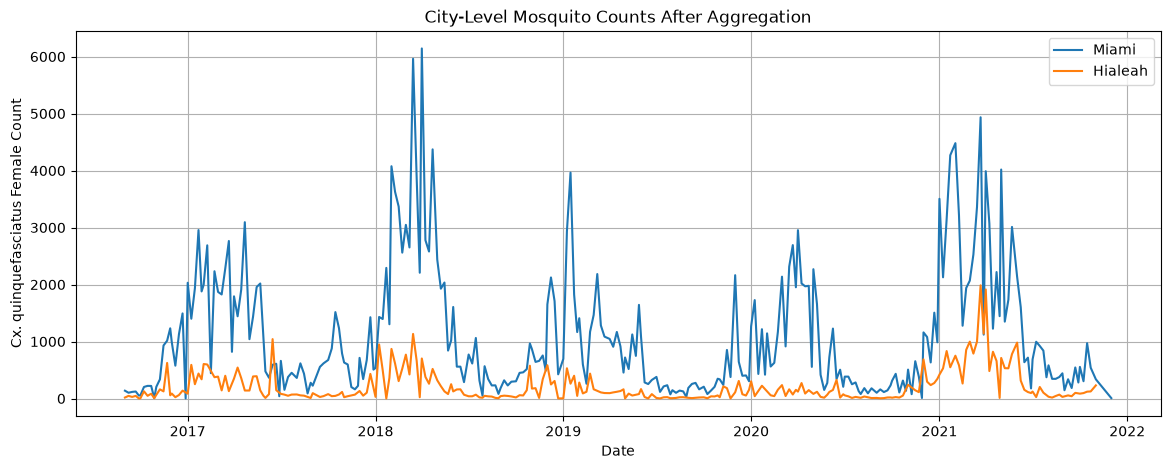

In [75]:
plt.figure(figsize=(14, 5))

plt.plot(
    df_miami["date"],
    df_miami[TARGET_COL],
    label="Miami"
)

plt.plot(
    df_hialeah["date"],
    df_hialeah[TARGET_COL],
    label="Hialeah"
)

plt.title("City-Level Mosquito Counts After Aggregation")
plt.xlabel("Date")
plt.ylabel("Cx. quinquefasciatus Female Count")
plt.legend()
plt.show()

In [76]:
STATIC_VARS = [
    "Manhole_within_1KM",
    "ElevationinFeet",
    "DistancetoCanal",
    "POVERTY_RATE",
    "POVERTY_NUMBER"
]

ENVIRONMENTAL_CONTEXT_VARS = [
    "NDVI",
    "NDVI_-1",
    "WATER_BODY",
    "WATER_BODY_-1"
]

PRECIP_VARS = [
    col for col in df_city_time.columns
    if "Precipitation" in col
]

HUMIDITY_VARS = [
    col for col in df_city_time.columns
    if "Humidity" in col or "Humidity" in col or "Max_Humidity" in col or "Min_Humidity" in col
]

TEMP_VARS = [
    col for col in df_city_time.columns
    if "Temperature" in col or "Max_Temperature" in col or "Min_Temperature" in col
]

STATIC_VARS = [col for col in STATIC_VARS if col in df_city_time.columns]
ENVIRONMENTAL_CONTEXT_VARS = [col for col in ENVIRONMENTAL_CONTEXT_VARS if col in df_city_time.columns]
PRECIP_VARS = [col for col in PRECIP_VARS if col in df_city_time.columns]
HUMIDITY_VARS = [col for col in HUMIDITY_VARS if col in df_city_time.columns]
TEMP_VARS = [col for col in TEMP_VARS if col in df_city_time.columns]

print("Static variables:", STATIC_VARS)
print("Environmental context variables:", ENVIRONMENTAL_CONTEXT_VARS)
print("Precipitation variables:", PRECIP_VARS)
print("Humidity variables:", HUMIDITY_VARS)
print("Temperature variables:", TEMP_VARS)

Static variables: ['Manhole_within_1KM', 'ElevationinFeet', 'DistancetoCanal', 'POVERTY_RATE', 'POVERTY_NUMBER']
Environmental context variables: ['NDVI', 'NDVI_-1', 'WATER_BODY', 'WATER_BODY_-1']
Precipitation variables: ['Mean_Precipitation', 'Mean_Precipitation-1', 'Mean_Precipitation-2', 'Mean_Precipitation-3', 'Mean_Precipitation-4', 'Mean_Precipitation-5']
Humidity variables: ['Mean_Humidity', 'Maximum_Humidity', 'Minimum_Humidity', 'Mean_Humidity-1', 'Max_Humidity-1', 'Min_Humidity-1', 'Mean_Humidity-2', 'Max_Humidity-2', 'Min_Humidity-2', 'Mean_Humidity-3', 'Max_Humidity-3', 'Min_Humidity-3', 'Mean_Humidity-4', 'Max_Humidity-4', 'Min_Humidity-4', 'Mean_Humidity-5', 'Max_Humidity-5', 'Min_Humidity-5']
Temperature variables: ['Mean_Temperature', 'Maximum_Temperature', 'Minimum_Temperature', 'Mean_Temperature-1', 'Max_Temperature-1', 'Min_Temperature-1', 'Mean_Temperature-2', 'Max_Temperature-2', 'Min_Temperature-2', 'Mean_Temperature-3', 'Max_Temperature-3', 'Min_Temperature-3', 

In [77]:
ENV_FEATURE_COLS = (
    STATIC_VARS
    + ENVIRONMENTAL_CONTEXT_VARS
    + PRECIP_VARS
    + HUMIDITY_VARS
    + TEMP_VARS
)

ENV_FEATURE_COLS = list(dict.fromkeys(ENV_FEATURE_COLS))

print("Number of environmental/context features:", len(ENV_FEATURE_COLS))
ENV_FEATURE_COLS

Number of environmental/context features: 51


['Manhole_within_1KM',
 'ElevationinFeet',
 'DistancetoCanal',
 'POVERTY_RATE',
 'POVERTY_NUMBER',
 'NDVI',
 'NDVI_-1',
 'WATER_BODY',
 'WATER_BODY_-1',
 'Mean_Precipitation',
 'Mean_Precipitation-1',
 'Mean_Precipitation-2',
 'Mean_Precipitation-3',
 'Mean_Precipitation-4',
 'Mean_Precipitation-5',
 'Mean_Humidity',
 'Maximum_Humidity',
 'Minimum_Humidity',
 'Mean_Humidity-1',
 'Max_Humidity-1',
 'Min_Humidity-1',
 'Mean_Humidity-2',
 'Max_Humidity-2',
 'Min_Humidity-2',
 'Mean_Humidity-3',
 'Max_Humidity-3',
 'Min_Humidity-3',
 'Mean_Humidity-4',
 'Max_Humidity-4',
 'Min_Humidity-4',
 'Mean_Humidity-5',
 'Max_Humidity-5',
 'Min_Humidity-5',
 'Mean_Temperature',
 'Maximum_Temperature',
 'Minimum_Temperature',
 'Mean_Temperature-1',
 'Max_Temperature-1',
 'Min_Temperature-1',
 'Mean_Temperature-2',
 'Max_Temperature-2',
 'Min_Temperature-2',
 'Mean_Temperature-3',
 'Max_Temperature-3',
 'Min_Temperature-3',
 'Mean_Temperature-4',
 'Max_Temperature-4',
 'Min_Temperature-4',
 'Mean_Tempe

In [78]:
def add_outbreak_label(df, target_col, percentile=0.80):
    df = df.copy()

    threshold = df[target_col].quantile(percentile)

    df["outbreak_80"] = (
        df[target_col] >= threshold
    ).astype(int)

    return df, threshold


df_miami, miami_outbreak_threshold = add_outbreak_label(
    df_miami,
    TARGET_COL,
    percentile=0.80
)

df_hialeah, hialeah_outbreak_threshold = add_outbreak_label(
    df_hialeah,
    TARGET_COL,
    percentile=0.80
)

print("Miami 80th percentile outbreak threshold:", miami_outbreak_threshold)
print("Hialeah 80th percentile outbreak threshold:", hialeah_outbreak_threshold)

print("Miami outbreak weeks:", df_miami["outbreak_80"].sum(), "of", len(df_miami))
print("Hialeah outbreak weeks:", df_hialeah["outbreak_80"].sum(), "of", len(df_hialeah))

Miami 80th percentile outbreak threshold: 1927.0
Hialeah 80th percentile outbreak threshold: 351.60000000000014
Miami outbreak weeks: 59 of 291
Hialeah outbreak weeks: 54 of 270


In [79]:
def add_mosquito_history_features(df, target_col):
    df = df.copy()

    df["mosq_lag_1"] = df[target_col].shift(1)
    df["mosq_lag_2"] = df[target_col].shift(2)
    df["mosq_lag_3"] = df[target_col].shift(3)
    df["mosq_lag_4"] = df[target_col].shift(4)

    df["mosq_roll_mean_2"] = (
        df[target_col]
        .shift(1)
        .rolling(window=2)
        .mean()
    )

    df["mosq_roll_mean_4"] = (
        df[target_col]
        .shift(1)
        .rolling(window=4)
        .mean()
    )

    df["mosq_growth_1"] = (
        (df[target_col].shift(1) - df[target_col].shift(2)) /
        df[target_col].shift(2).replace(0, np.nan)
    )

    df["mosq_growth_1"] = df["mosq_growth_1"].replace([np.inf, -np.inf], np.nan)

    return df


df_miami = add_mosquito_history_features(df_miami, TARGET_COL)
df_hialeah = add_mosquito_history_features(df_hialeah, TARGET_COL)

MOSQ_HISTORY_COLS = [
    "mosq_lag_1",
    "mosq_lag_2",
    "mosq_lag_3",
    "mosq_lag_4",
    "mosq_roll_mean_2",
    "mosq_roll_mean_4",
    "mosq_growth_1"
]

df_miami[MOSQ_HISTORY_COLS + ["outbreak_80"]].head(10)

,mosq_lag_1,mosq_lag_2,mosq_lag_3,mosq_lag_4,mosq_roll_mean_2,mosq_roll_mean_4,mosq_growth_1,outbreak_80
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0
1,136.916667,NaN,NaN,NaN,NaN,NaN,NaN,0
2,101.000000,136.916667,NaN,NaN,118.958333,NaN,-0.262325,0
3,115.916667,101.000000,136.916667,NaN,108.458333,NaN,0.147690,0
4,122.916667,115.916667,101.000000,136.916667,119.416667,119.187500,0.060388,0
5,52.500000,122.916667,115.916667,101.000000,87.708333,98.083333,-0.572881,0
6,54.000000,52.500000,122.916667,115.916667,53.250000,86.333333,0.028571,0
7,202.750000,54.000000,52.500000,122.916667,128.375000,108.041667,2.754630,0
8,221.550000,202.750000,54.000000,52.500000,212.150000,132.700000,0.092725,0
9,220.440476,221.550000,202.750000,54.000000,220.995238,174.685119,-0.005008,0


In [80]:
def clean_modeling_dataframe(df, feature_cols, target_col):
    df = df.copy()

    for col in feature_cols:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    df = df.replace([np.inf, -np.inf], np.nan)

    required_cols = [target_col, "outbreak_80"] + MOSQ_HISTORY_COLS

    df = df.dropna(subset=required_cols)

    for col in feature_cols + MOSQ_HISTORY_COLS:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    return df.reset_index(drop=True)


df_miami_model = clean_modeling_dataframe(
    df_miami,
    ENV_FEATURE_COLS,
    TARGET_COL
)

df_hialeah_model = clean_modeling_dataframe(
    df_hialeah,
    ENV_FEATURE_COLS,
    TARGET_COL
)

print("Miami modeling shape:", df_miami_model.shape)
print("Hialeah modeling shape:", df_hialeah_model.shape)

Miami modeling shape: (287, 66)
Hialeah modeling shape: (266, 66)


In [81]:
def time_train_test_split(df, train_frac=0.80):
    split_idx = int(len(df) * train_frac)

    train_df = df.iloc[:split_idx].copy()
    test_df = df.iloc[split_idx:].copy()

    return train_df, test_df


miami_train, miami_test = time_train_test_split(df_miami_model, train_frac=0.80)
hialeah_train, hialeah_test = time_train_test_split(df_hialeah_model, train_frac=0.80)

print("Miami train/test:", miami_train.shape, miami_test.shape)
print("Hialeah train/test:", hialeah_train.shape, hialeah_test.shape)

Miami train/test: (229, 66) (58, 66)
Hialeah train/test: (212, 66) (54, 66)


In [82]:
def compute_regression_metrics(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    nrmse = rmse / np.mean(y_true) if np.mean(y_true) != 0 else np.nan

    nonzero_mask = y_true != 0
    if np.sum(nonzero_mask) > 0:
        mape = np.mean(
            np.abs((y_true[nonzero_mask] - y_pred[nonzero_mask]) / y_true[nonzero_mask])
        ) * 100
    else:
        mape = np.nan

    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    smape_mask = denominator != 0
    if np.sum(smape_mask) > 0:
        smape = np.mean(
            np.abs(y_true[smape_mask] - y_pred[smape_mask]) / denominator[smape_mask]
        ) * 100
    else:
        smape = np.nan

    return {
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "nRMSE": nrmse,
        "MAPE": mape,
        "SMAPE": smape
    }


def compute_classification_metrics(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0)
    }

In [83]:
def residual_diagnostics(residuals, fitted_values=None, title="Residual Diagnostics"):
    residuals = pd.Series(residuals).dropna()

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))

    axes[0, 0].plot(residuals)
    axes[0, 0].axhline(0, linestyle="--")
    axes[0, 0].set_title("Residuals Over Time")

    if fitted_values is not None:
        fitted_values = np.array(fitted_values)
        min_len = min(len(fitted_values), len(residuals))
        axes[0, 1].scatter(fitted_values[-min_len:], residuals[-min_len:])
        axes[0, 1].axhline(0, linestyle="--")
        axes[0, 1].set_title("Residuals vs Fitted")
    else:
        axes[0, 1].hist(residuals, bins=25)
        axes[0, 1].set_title("Residual Distribution")

    plot_acf(residuals, ax=axes[1, 0])
    axes[1, 0].set_title("ACF of Residuals")

    qqplot(residuals, line="s", ax=axes[1, 1])
    axes[1, 1].set_title("Q-Q Plot")

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

    print("Ljung-Box Test:")
    display(acorr_ljungbox(residuals, lags=[10, 20], return_df=True))

In [84]:
print("Environmental feature count:", len(ENV_FEATURE_COLS))
print("Mosquito-history feature count:", len(MOSQ_HISTORY_COLS))

print("\nMiami target summary:")
display(df_miami_model[TARGET_COL].describe())

print("\nHialeah target summary:")
display(df_hialeah_model[TARGET_COL].describe())

print("\nMiami outbreak rate:")
print(df_miami_model["outbreak_80"].mean())

print("\nHialeah outbreak rate:")
print(df_hialeah_model["outbreak_80"].mean())

Environmental feature count: 51
Mosquito-history feature count: 7

Miami target summary:


count     287.000000
mean     1095.489680
std      1097.395353
min         1.000000
25%       307.500000
50%       654.000000
75%      1604.500000
max      6143.000000
Name: Cx_quinquefasciatus_fem, dtype: float64


Hialeah target summary:


count     266.000000
mean      212.917786
std       288.030931
min         1.000000
25%        38.000000
50%        97.500000
75%       278.000000
max      1986.000000
Name: Cx_quinquefasciatus_fem, dtype: float64


Miami outbreak rate:
0.20557491289198607

Hialeah outbreak rate:
0.20300751879699247


In [85]:
def extract_lag_number(col):
    """
    Extracts lag number from environmental variable names.

    Examples:
    Mean_Precipitation      -> 0
    Mean_Precipitation-1    -> 1
    Mean_Temperature-3      -> 3
    Max_Humidity-5          -> 5
    """
    if "-" in col:
        try:
            return int(col.split("-")[-1])
        except:
            return 0
    else:
        return 0

In [86]:
PRECIP_LAG_COLS = [
    col for col in ENV_FEATURE_COLS
    if "Precipitation" in col
]

MEAN_HUMIDITY_LAG_COLS = [
    col for col in ENV_FEATURE_COLS
    if col.startswith("Mean_Humidity")
]

MAX_HUMIDITY_LAG_COLS = [
    col for col in ENV_FEATURE_COLS
    if col.startswith("Maximum_Humidity") or col.startswith("Max_Humidity")
]

MIN_HUMIDITY_LAG_COLS = [
    col for col in ENV_FEATURE_COLS
    if col.startswith("Minimum_Humidity") or col.startswith("Min_Humidity")
]

MEAN_TEMP_LAG_COLS = [
    col for col in ENV_FEATURE_COLS
    if col.startswith("Mean_Temperature")
]

MAX_TEMP_LAG_COLS = [
    col for col in ENV_FEATURE_COLS
    if col.startswith("Maximum_Temperature") or col.startswith("Max_Temperature")
]

MIN_TEMP_LAG_COLS = [
    col for col in ENV_FEATURE_COLS
    if col.startswith("Minimum_Temperature") or col.startswith("Min_Temperature")
]

lag_families = {
    "Precipitation": PRECIP_LAG_COLS,
    "Mean Humidity": MEAN_HUMIDITY_LAG_COLS,
    "Maximum Humidity": MAX_HUMIDITY_LAG_COLS,
    "Minimum Humidity": MIN_HUMIDITY_LAG_COLS,
    "Mean Temperature": MEAN_TEMP_LAG_COLS,
    "Maximum Temperature": MAX_TEMP_LAG_COLS,
    "Minimum Temperature": MIN_TEMP_LAG_COLS
}

for family, cols in lag_families.items():
    print(f"{family}: {cols}")

Precipitation: ['Mean_Precipitation', 'Mean_Precipitation-1', 'Mean_Precipitation-2', 'Mean_Precipitation-3', 'Mean_Precipitation-4', 'Mean_Precipitation-5']
Mean Humidity: ['Mean_Humidity', 'Mean_Humidity-1', 'Mean_Humidity-2', 'Mean_Humidity-3', 'Mean_Humidity-4', 'Mean_Humidity-5']
Maximum Humidity: ['Maximum_Humidity', 'Max_Humidity-1', 'Max_Humidity-2', 'Max_Humidity-3', 'Max_Humidity-4', 'Max_Humidity-5']
Minimum Humidity: ['Minimum_Humidity', 'Min_Humidity-1', 'Min_Humidity-2', 'Min_Humidity-3', 'Min_Humidity-4', 'Min_Humidity-5']
Mean Temperature: ['Mean_Temperature', 'Mean_Temperature-1', 'Mean_Temperature-2', 'Mean_Temperature-3', 'Mean_Temperature-4', 'Mean_Temperature-5']
Maximum Temperature: ['Maximum_Temperature', 'Max_Temperature-1', 'Max_Temperature-2', 'Max_Temperature-3', 'Max_Temperature-4', 'Max_Temperature-5']
Minimum Temperature: ['Minimum_Temperature', 'Min_Temperature-1', 'Min_Temperature-2', 'Min_Temperature-3', 'Min_Temperature-4', 'Min_Temperature-5']


In [87]:
def compute_lag_correlations(df, target_col, city_name, lag_families):
    """
    Computes correlations between mosquito counts and lagged
    environmental variables.
    """
    results = []

    for family, cols in lag_families.items():
        for col in cols:
            if col in df.columns:
                corr = df[[target_col, col]].corr().iloc[0, 1]

                results.append({
                    "City": city_name,
                    "Environmental Family": family,
                    "Variable": col,
                    "Lag": extract_lag_number(col),
                    "Correlation": corr,
                    "Abs Correlation": abs(corr)
                })

    results_df = pd.DataFrame(results)

    if len(results_df) > 0:
        results_df = results_df.sort_values(
            ["City", "Environmental Family", "Lag"]
        ).reset_index(drop=True)

    return results_df

In [88]:
miami_lag_corr = compute_lag_correlations(
    df_miami_model,
    target_col=TARGET_COL,
    city_name="Miami",
    lag_families=lag_families
)

miami_lag_corr

,City,Environmental Family,Variable,Lag,Correlation,Abs Correlation
0,Miami,Maximum Humidity,Maximum_Humidity,0,-0.002345,0.002345
1,Miami,Maximum Humidity,Max_Humidity-1,1,-0.123883,0.123883
2,Miami,Maximum Humidity,Max_Humidity-2,2,-0.019190,0.019190
3,Miami,Maximum Humidity,Max_Humidity-3,3,0.027151,0.027151
4,Miami,Maximum Humidity,Max_Humidity-4,4,0.018402,0.018402
5,Miami,Maximum Humidity,Max_Humidity-5,5,0.056375,0.056375
6,Miami,Maximum Temperature,Maximum_Temperature,0,-0.297095,0.297095
7,Miami,Maximum Temperature,Max_Temperature-1,1,-0.424848,0.424848
8,Miami,Maximum Temperature,Max_Temperature-2,2,-0.403551,0.403551
9,Miami,Maximum Temperature,Max_Temperature-3,3,-0.430065,0.430065


In [89]:
hialeah_lag_corr = compute_lag_correlations(
    df_hialeah_model,
    target_col=TARGET_COL,
    city_name="Hialeah",
    lag_families=lag_families
)

hialeah_lag_corr

,City,Environmental Family,Variable,Lag,Correlation,Abs Correlation
0,Hialeah,Maximum Humidity,Maximum_Humidity,0,-0.161186,0.161186
1,Hialeah,Maximum Humidity,Max_Humidity-1,1,-0.159192,0.159192
2,Hialeah,Maximum Humidity,Max_Humidity-2,2,-0.096680,0.096680
3,Hialeah,Maximum Humidity,Max_Humidity-3,3,-0.056352,0.056352
4,Hialeah,Maximum Humidity,Max_Humidity-4,4,-0.015856,0.015856
5,Hialeah,Maximum Humidity,Max_Humidity-5,5,-0.024762,0.024762
6,Hialeah,Maximum Temperature,Maximum_Temperature,0,-0.283174,0.283174
7,Hialeah,Maximum Temperature,Max_Temperature-1,1,-0.357844,0.357844
8,Hialeah,Maximum Temperature,Max_Temperature-2,2,-0.374274,0.374274
9,Hialeah,Maximum Temperature,Max_Temperature-3,3,-0.390183,0.390183


In [90]:
combined_lag_corr = pd.concat([
    miami_lag_corr,
    hialeah_lag_corr
]).reset_index(drop=True)

combined_lag_corr

,City,Environmental Family,Variable,Lag,Correlation,Abs Correlation
0,Miami,Maximum Humidity,Maximum_Humidity,0,-0.002345,0.002345
1,Miami,Maximum Humidity,Max_Humidity-1,1,-0.123883,0.123883
2,Miami,Maximum Humidity,Max_Humidity-2,2,-0.019190,0.019190
3,Miami,Maximum Humidity,Max_Humidity-3,3,0.027151,0.027151
4,Miami,Maximum Humidity,Max_Humidity-4,4,0.018402,0.018402
...,...,...,...,...,...,...
79,Hialeah,Precipitation,Mean_Precipitation-1,1,-0.245953,0.245953
80,Hialeah,Precipitation,Mean_Precipitation-2,2,-0.187855,0.187855
81,Hialeah,Precipitation,Mean_Precipitation-3,3,-0.199738,0.199738
82,Hialeah,Precipitation,Mean_Precipitation-4,4,-0.194691,0.194691


In [91]:
combined_lag_corr.style.format({
    "Correlation": "{:.3f}",
    "Abs Correlation": "{:.3f}"
})

,City,Environmental Family,Variable,Lag,Correlation,Abs Correlation
0,Miami,Maximum Humidity,Maximum_Humidity,0,-0.002,0.002
1,Miami,Maximum Humidity,Max_Humidity-1,1,-0.124,0.124
2,Miami,Maximum Humidity,Max_Humidity-2,2,-0.019,0.019
3,Miami,Maximum Humidity,Max_Humidity-3,3,0.027,0.027
4,Miami,Maximum Humidity,Max_Humidity-4,4,0.018,0.018
5,Miami,Maximum Humidity,Max_Humidity-5,5,0.056,0.056
6,Miami,Maximum Temperature,Maximum_Temperature,0,-0.297,0.297
7,Miami,Maximum Temperature,Max_Temperature-1,1,-0.425,0.425
8,Miami,Maximum Temperature,Max_Temperature-2,2,-0.404,0.404
9,Miami,Maximum Temperature,Max_Temperature-3,3,-0.430,0.430


In [92]:
best_lag_by_family = (
    combined_lag_corr
    .sort_values(["City", "Environmental Family", "Abs Correlation"], ascending=[True, True, False])
    .groupby(["City", "Environmental Family"])
    .head(1)
    .reset_index(drop=True)
)

best_lag_by_family

,City,Environmental Family,Variable,Lag,Correlation,Abs Correlation
0,Hialeah,Maximum Humidity,Maximum_Humidity,0,-0.161186,0.161186
1,Hialeah,Maximum Temperature,Max_Temperature-3,3,-0.390183,0.390183
2,Hialeah,Mean Humidity,Mean_Humidity,0,-0.377161,0.377161
3,Hialeah,Mean Temperature,Mean_Temperature-5,5,-0.470313,0.470313
4,Hialeah,Minimum Humidity,Minimum_Humidity,0,-0.371511,0.371511
5,Hialeah,Minimum Temperature,Min_Temperature-5,5,-0.452913,0.452913
6,Hialeah,Precipitation,Mean_Precipitation,0,-0.249275,0.249275
7,Miami,Maximum Humidity,Max_Humidity-1,1,-0.123883,0.123883
8,Miami,Maximum Temperature,Max_Temperature-4,4,-0.491071,0.491071
9,Miami,Mean Humidity,Mean_Humidity-1,1,-0.400157,0.400157


In [93]:
best_lag_by_family.style.format({
    "Correlation": "{:.3f}",
    "Abs Correlation": "{:.3f}"
})

,City,Environmental Family,Variable,Lag,Correlation,Abs Correlation
0,Hialeah,Maximum Humidity,Maximum_Humidity,0,-0.161,0.161
1,Hialeah,Maximum Temperature,Max_Temperature-3,3,-0.390,0.390
2,Hialeah,Mean Humidity,Mean_Humidity,0,-0.377,0.377
3,Hialeah,Mean Temperature,Mean_Temperature-5,5,-0.470,0.470
4,Hialeah,Minimum Humidity,Minimum_Humidity,0,-0.372,0.372
5,Hialeah,Minimum Temperature,Min_Temperature-5,5,-0.453,0.453
6,Hialeah,Precipitation,Mean_Precipitation,0,-0.249,0.249
7,Miami,Maximum Humidity,Max_Humidity-1,1,-0.124,0.124
8,Miami,Maximum Temperature,Max_Temperature-4,4,-0.491,0.491
9,Miami,Mean Humidity,Mean_Humidity-1,1,-0.400,0.400


In [94]:
def plot_lag_correlations_by_city(lag_corr_df, city_name):
    city_df = lag_corr_df[lag_corr_df["City"] == city_name].copy()

    families = city_df["Environmental Family"].unique()

    for family in families:
        family_df = city_df[city_df["Environmental Family"] == family].copy()

        plt.figure(figsize=(8, 5))

        sns.lineplot(
            data=family_df,
            x="Lag",
            y="Correlation",
            hue="Variable",
            marker="o"
        )

        plt.axhline(0, linestyle="--")
        plt.title(f"{family} Lag Correlations with Mosquito Counts — {city_name}")
        plt.xlabel("Lag (weeks)")
        plt.ylabel("Correlation")
        plt.legend(title="Variable", bbox_to_anchor=(1.05, 1), loc="upper left")
        plt.show()

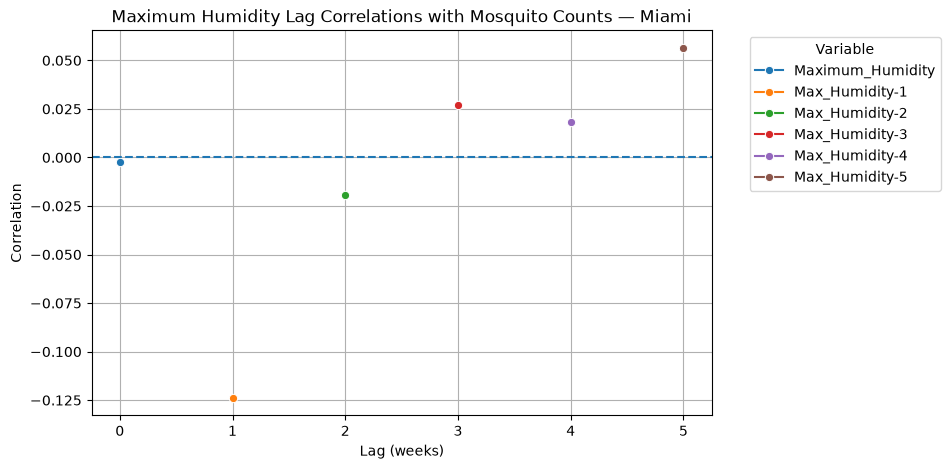

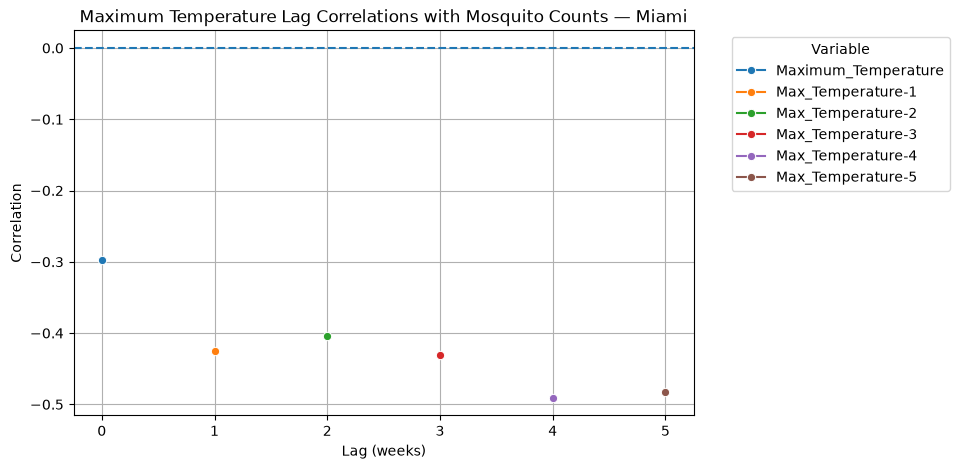

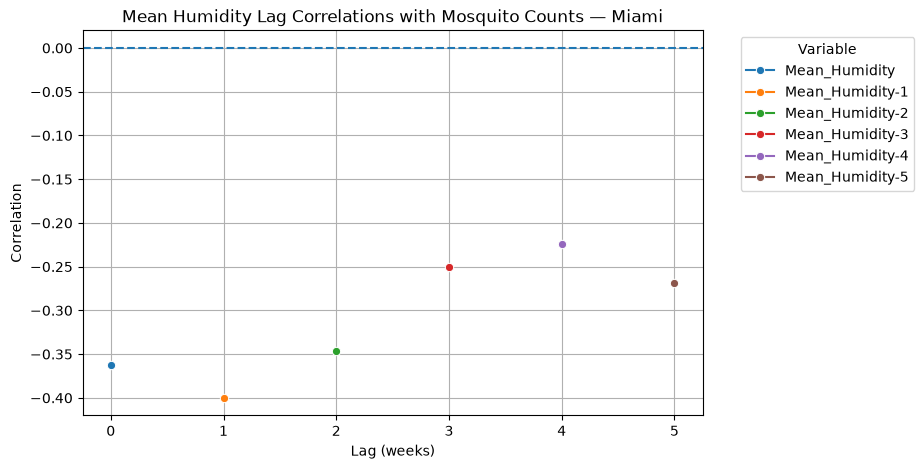

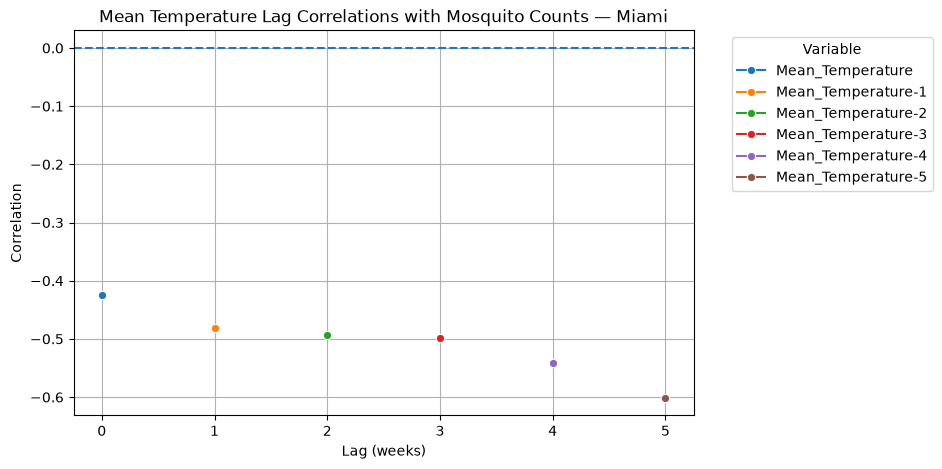

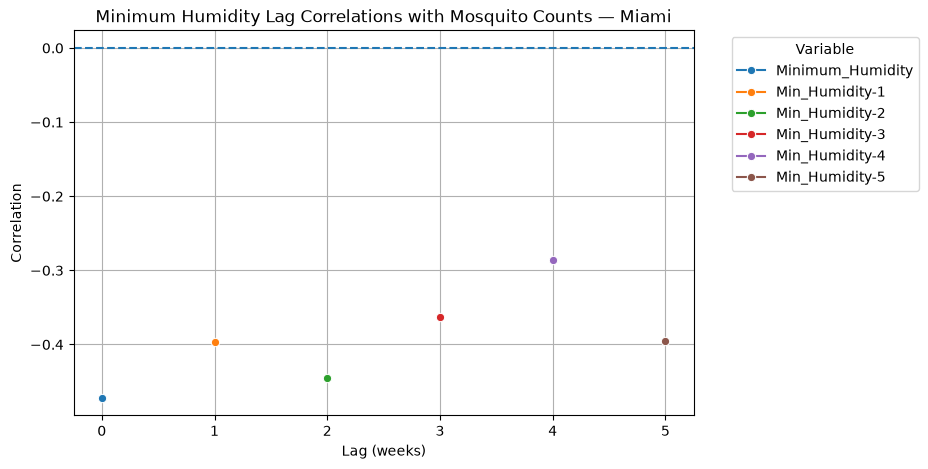

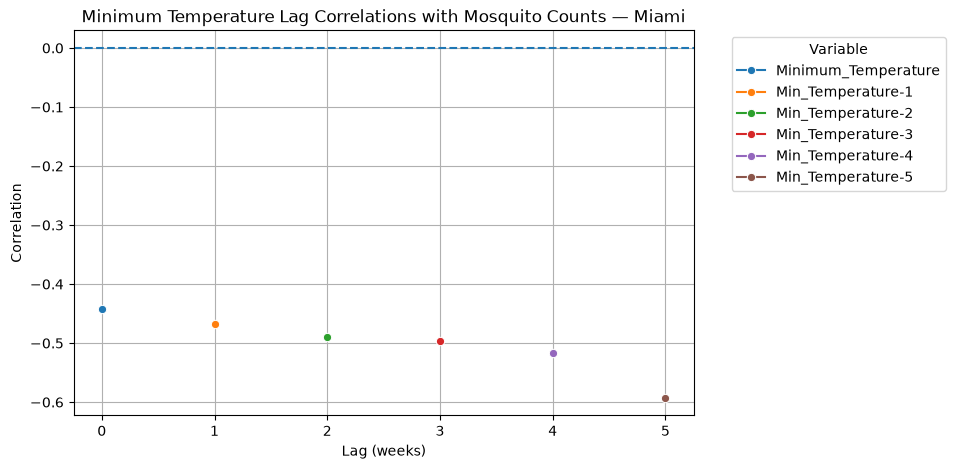

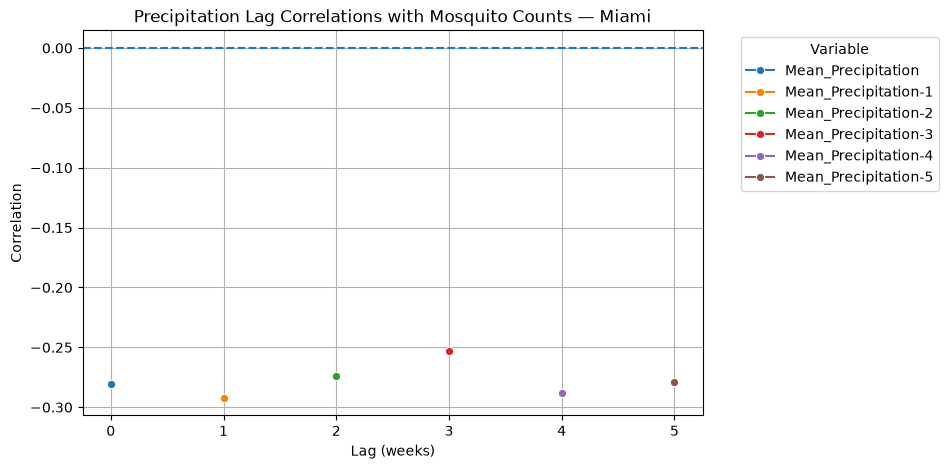

In [95]:
plot_lag_correlations_by_city(
    combined_lag_corr,
    city_name="Miami"
)

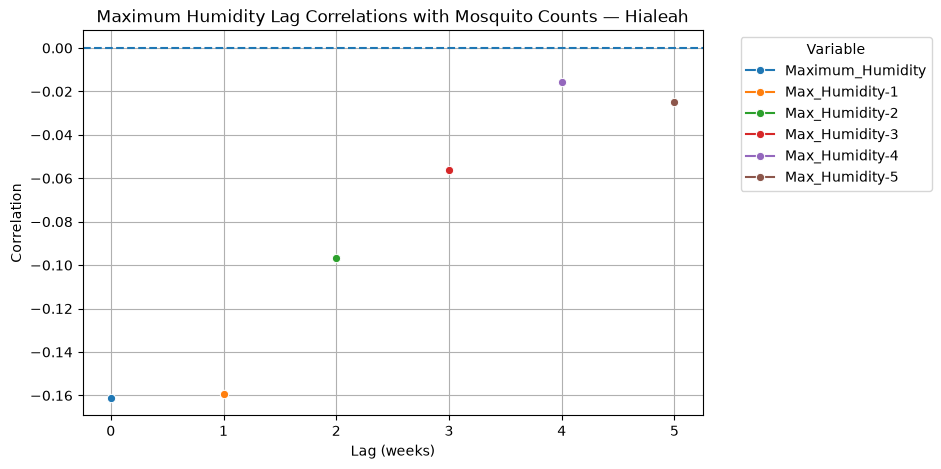

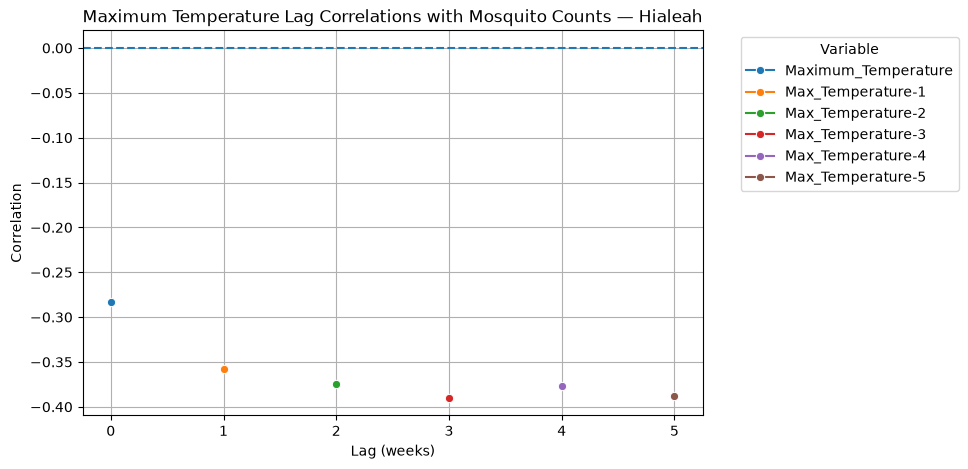

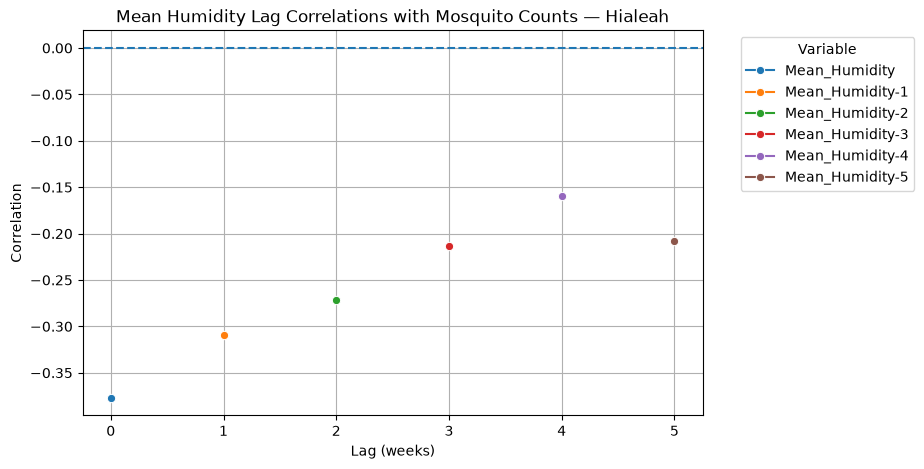

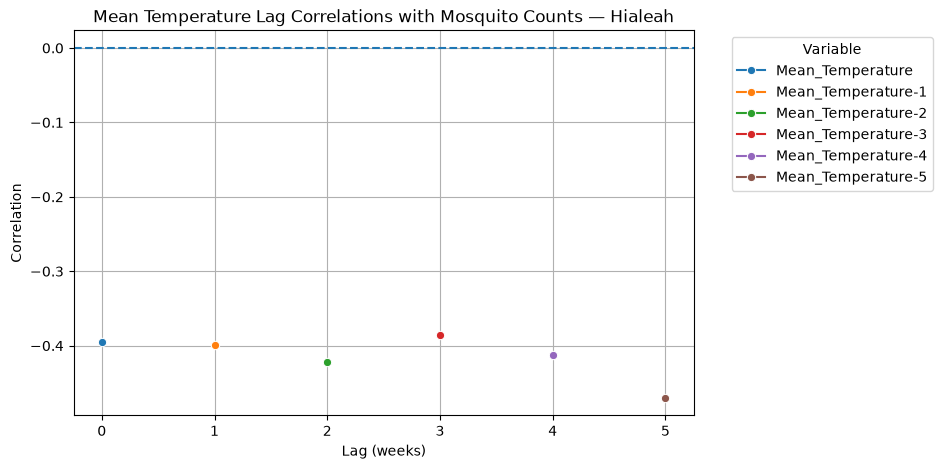

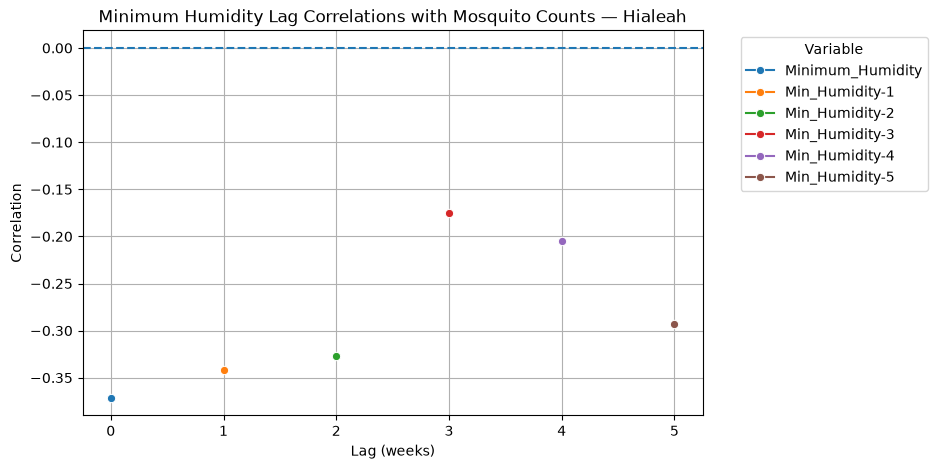

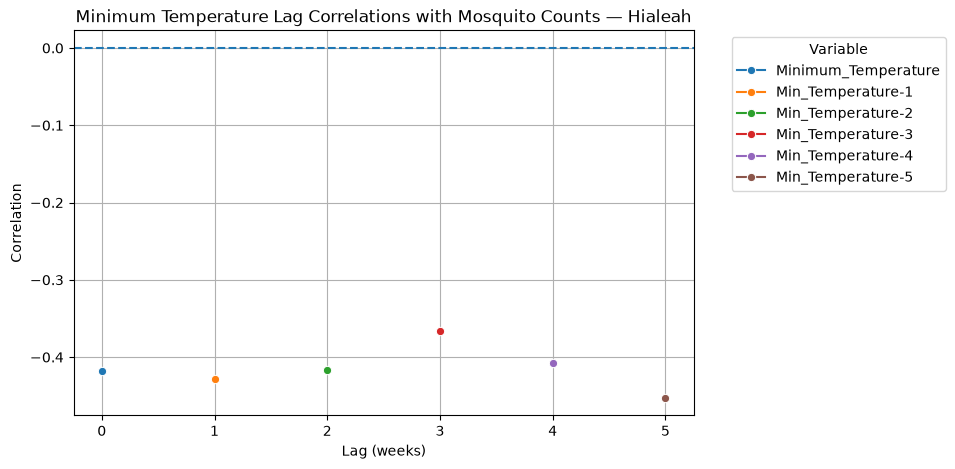

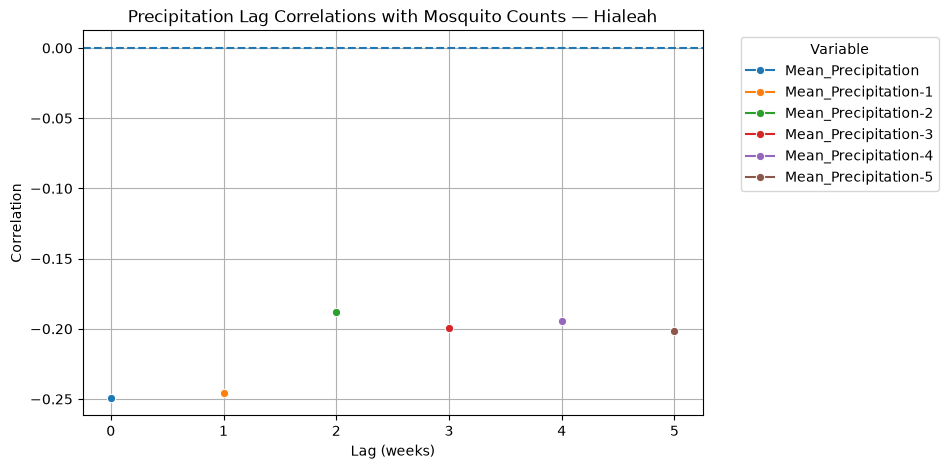

In [96]:
plot_lag_correlations_by_city(
    combined_lag_corr,
    city_name="Hialeah"
)

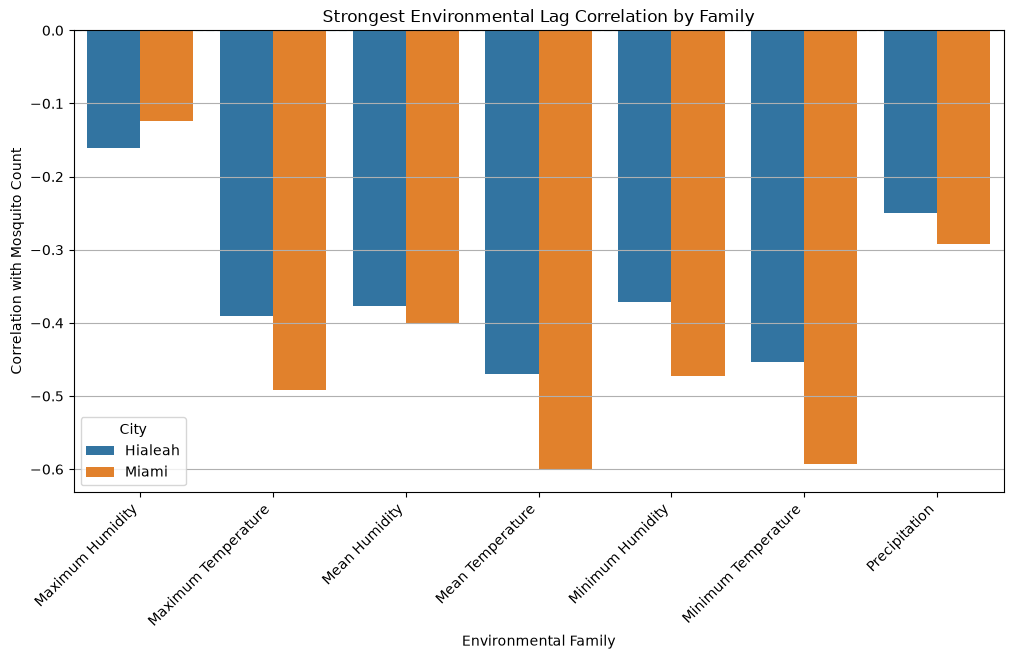

In [97]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=best_lag_by_family,
    x="Environmental Family",
    y="Correlation",
    hue="City"
)

plt.axhline(0, linestyle="--")
plt.title("Strongest Environmental Lag Correlation by Family")
plt.xlabel("Environmental Family")
plt.ylabel("Correlation with Mosquito Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="City")
plt.show()

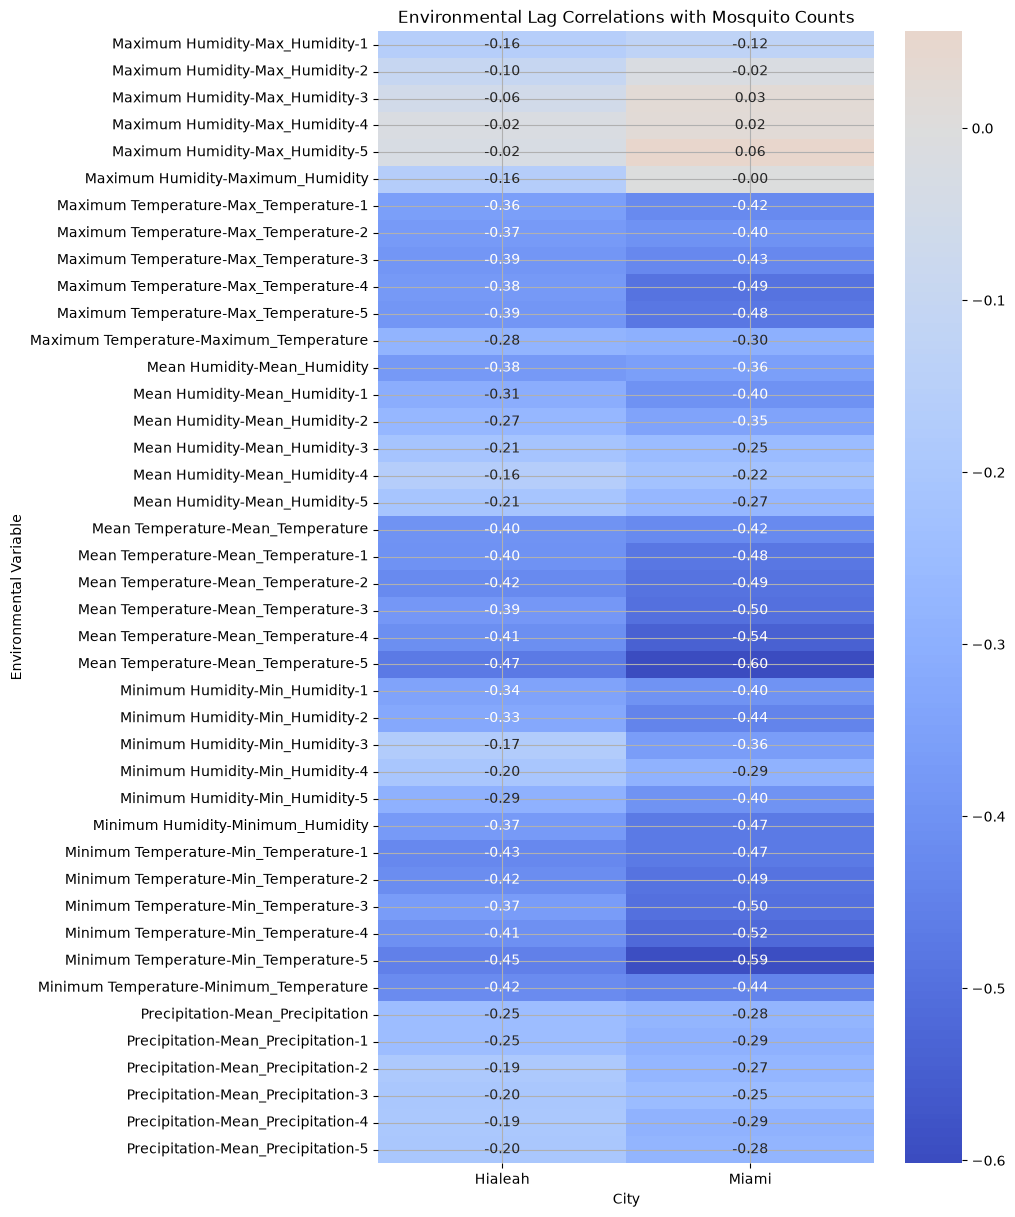

In [98]:
heatmap_df = combined_lag_corr.pivot_table(
    index=["Environmental Family", "Variable"],
    columns="City",
    values="Correlation"
)

plt.figure(figsize=(8, max(6, len(heatmap_df) * 0.35)))

sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)

plt.title("Environmental Lag Correlations with Mosquito Counts")
plt.xlabel("City")
plt.ylabel("Environmental Variable")
plt.show()

In [99]:
top_environmental_drivers = (
    combined_lag_corr
    .sort_values(["City", "Abs Correlation"], ascending=[True, False])
    .groupby("City")
    .head(10)
    .reset_index(drop=True)
)

top_environmental_drivers

,City,Environmental Family,Variable,Lag,Correlation,Abs Correlation
0,Hialeah,Mean Temperature,Mean_Temperature-5,5,-0.470313,0.470313
1,Hialeah,Minimum Temperature,Min_Temperature-5,5,-0.452913,0.452913
2,Hialeah,Minimum Temperature,Min_Temperature-1,1,-0.427961,0.427961
3,Hialeah,Mean Temperature,Mean_Temperature-2,2,-0.422275,0.422275
4,Hialeah,Minimum Temperature,Minimum_Temperature,0,-0.418389,0.418389
5,Hialeah,Minimum Temperature,Min_Temperature-2,2,-0.416109,0.416109
6,Hialeah,Mean Temperature,Mean_Temperature-4,4,-0.412678,0.412678
7,Hialeah,Minimum Temperature,Min_Temperature-4,4,-0.407749,0.407749
8,Hialeah,Mean Temperature,Mean_Temperature-1,1,-0.399222,0.399222
9,Hialeah,Mean Temperature,Mean_Temperature,0,-0.395382,0.395382


In [100]:
top_environmental_drivers.style.format({
    "Correlation": "{:.3f}",
    "Abs Correlation": "{:.3f}"
})

,City,Environmental Family,Variable,Lag,Correlation,Abs Correlation
0,Hialeah,Mean Temperature,Mean_Temperature-5,5,-0.470,0.470
1,Hialeah,Minimum Temperature,Min_Temperature-5,5,-0.453,0.453
2,Hialeah,Minimum Temperature,Min_Temperature-1,1,-0.428,0.428
3,Hialeah,Mean Temperature,Mean_Temperature-2,2,-0.422,0.422
4,Hialeah,Minimum Temperature,Minimum_Temperature,0,-0.418,0.418
5,Hialeah,Minimum Temperature,Min_Temperature-2,2,-0.416,0.416
6,Hialeah,Mean Temperature,Mean_Temperature-4,4,-0.413,0.413
7,Hialeah,Minimum Temperature,Min_Temperature-4,4,-0.408,0.408
8,Hialeah,Mean Temperature,Mean_Temperature-1,1,-0.399,0.399
9,Hialeah,Mean Temperature,Mean_Temperature,0,-0.395,0.395


In [101]:
def plot_top_environmental_drivers(top_df, city_name):
    city_df = top_df[top_df["City"] == city_name].copy()

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=city_df,
        x="Correlation",
        y="Variable"
    )

    plt.axvline(0, linestyle="--")
    plt.title(f"Top Environmental Drivers by Correlation — {city_name}")
    plt.xlabel("Correlation with Mosquito Count")
    plt.ylabel("Variable")
    plt.show()

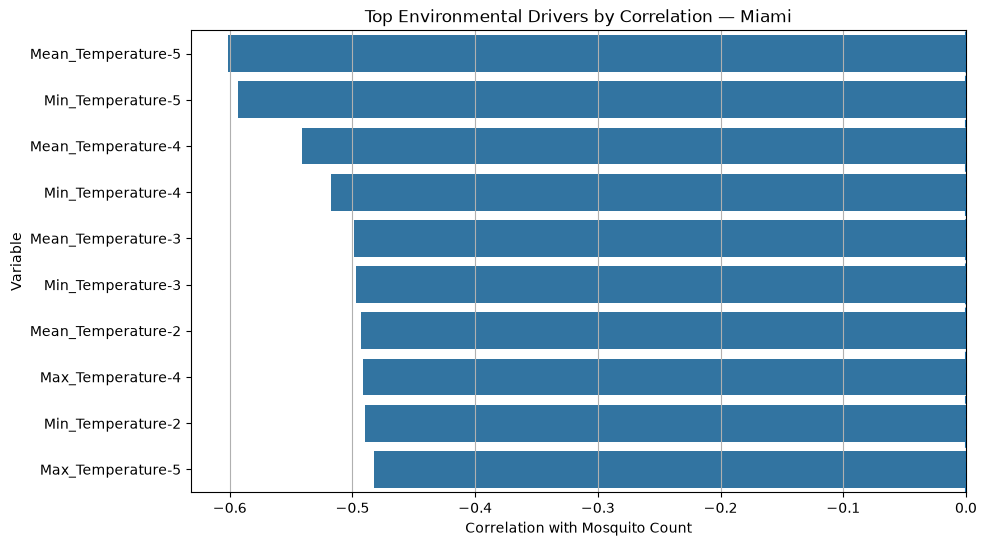

In [102]:
plot_top_environmental_drivers(
    top_environmental_drivers,
    city_name="Miami"
)

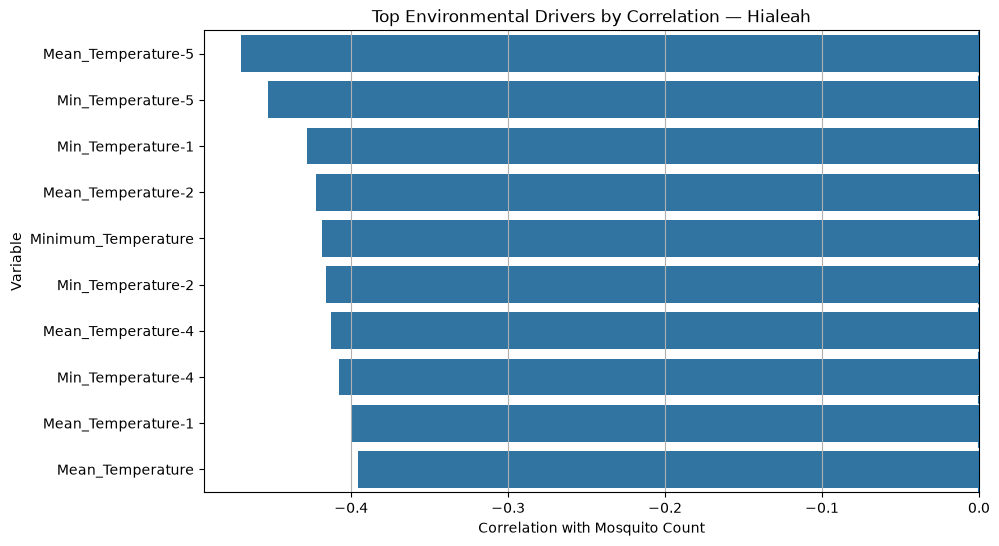

In [103]:
plot_top_environmental_drivers(
    top_environmental_drivers,
    city_name="Hialeah"
)

In [104]:
family_summary = (
    combined_lag_corr
    .groupby(["City", "Environmental Family"])
    .agg(
        Best_Abs_Correlation=("Abs Correlation", "max"),
        Mean_Abs_Correlation=("Abs Correlation", "mean")
    )
    .reset_index()
    .sort_values(["City", "Best_Abs_Correlation"], ascending=[True, False])
)

family_summary

,City,Environmental Family,Best_Abs_Correlation,Mean_Abs_Correlation
3,Hialeah,Mean Temperature,0.470313,0.414195
5,Hialeah,Minimum Temperature,0.452913,0.414842
1,Hialeah,Maximum Temperature,0.390183,0.361692
2,Hialeah,Mean Humidity,0.377161,0.256614
4,Hialeah,Minimum Humidity,0.371511,0.285505
6,Hialeah,Precipitation,0.249275,0.213220
0,Hialeah,Maximum Humidity,0.161186,0.085671
10,Miami,Mean Temperature,0.601552,0.506478
12,Miami,Minimum Temperature,0.592995,0.501263
8,Miami,Maximum Temperature,0.491071,0.421578


In [105]:
family_summary.style.format({
    "Best_Abs_Correlation": "{:.3f}",
    "Mean_Abs_Correlation": "{:.3f}"
})

,City,Environmental Family,Best_Abs_Correlation,Mean_Abs_Correlation
3,Hialeah,Mean Temperature,0.470,0.414
5,Hialeah,Minimum Temperature,0.453,0.415
1,Hialeah,Maximum Temperature,0.390,0.362
2,Hialeah,Mean Humidity,0.377,0.257
4,Hialeah,Minimum Humidity,0.372,0.286
6,Hialeah,Precipitation,0.249,0.213
0,Hialeah,Maximum Humidity,0.161,0.086
10,Miami,Mean Temperature,0.602,0.506
12,Miami,Minimum Temperature,0.593,0.501
8,Miami,Maximum Temperature,0.491,0.422


In [106]:
combined_lag_corr.to_csv(
    "multivariate_environmental_lag_correlations.csv",
    index=False
)

best_lag_by_family.to_csv(
    "multivariate_best_environmental_lags_by_family.csv",
    index=False
)

top_environmental_drivers.to_csv(
    "multivariate_top_environmental_drivers.csv",
    index=False
)

family_summary.to_csv(
    "multivariate_environmental_family_summary.csv",
    index=False
)

In [107]:
def get_top_environmental_features(best_lag_df, city_name, top_n=10):
    city_top = (
        best_lag_df[best_lag_df["City"] == city_name]
        .sort_values("Abs Correlation", ascending=False)
        .head(top_n)
    )
    return city_top["Variable"].tolist()


miami_top_env_features = get_top_environmental_features(
    combined_lag_corr,
    city_name="Miami",
    top_n=10
)

hialeah_top_env_features = get_top_environmental_features(
    combined_lag_corr,
    city_name="Hialeah",
    top_n=10
)

print("Miami top environmental features:")
print(miami_top_env_features)

print("\nHialeah top environmental features:")
print(hialeah_top_env_features)

Miami top environmental features:
['Mean_Temperature-5', 'Min_Temperature-5', 'Mean_Temperature-4', 'Min_Temperature-4', 'Mean_Temperature-3', 'Min_Temperature-3', 'Mean_Temperature-2', 'Max_Temperature-4', 'Min_Temperature-2', 'Max_Temperature-5']

Hialeah top environmental features:
['Mean_Temperature-5', 'Min_Temperature-5', 'Min_Temperature-1', 'Mean_Temperature-2', 'Minimum_Temperature', 'Min_Temperature-2', 'Mean_Temperature-4', 'Min_Temperature-4', 'Mean_Temperature-1', 'Mean_Temperature']


In [108]:

def compare_environment_outbreak_conditions(
    df,
    feature_cols,
    city_name,
    outbreak_col="outbreak_80"
):
    """
    Compares environmental feature values between normal and outbreak weeks.
    """
    results = []

    for feature in feature_cols:
        if feature not in df.columns:
            continue

        normal_values = df[df[outbreak_col] == 0][feature].dropna()
        outbreak_values = df[df[outbreak_col] == 1][feature].dropna()

        if len(normal_values) == 0 or len(outbreak_values) == 0:
            continue

        normal_mean = normal_values.mean()
        outbreak_mean = outbreak_values.mean()

        normal_std = normal_values.std()
        outbreak_std = outbreak_values.std()

        pooled_std = np.sqrt(
            ((len(normal_values) - 1) * normal_std ** 2 +
             (len(outbreak_values) - 1) * outbreak_std ** 2) /
            (len(normal_values) + len(outbreak_values) - 2)
        )

        cohens_d = (
            (outbreak_mean - normal_mean) / pooled_std
            if pooled_std != 0 else np.nan
        )

        results.append({
            "City": city_name,
            "Feature": feature,
            "Normal Mean": normal_mean,
            "Outbreak Mean": outbreak_mean,
            "Difference": outbreak_mean - normal_mean,
            "Normal Median": normal_values.median(),
            "Outbreak Median": outbreak_values.median(),
            "Normal Std": normal_std,
            "Outbreak Std": outbreak_std,
            "Cohen_d": cohens_d,
            "Abs Cohen_d": abs(cohens_d)
        })

    results_df = pd.DataFrame(results)

    if len(results_df) > 0:
        results_df = results_df.sort_values(
            "Abs Cohen_d",
            ascending=False
        ).reset_index(drop=True)

    return results_df

In [109]:
miami_env_outbreak_comparison = compare_environment_outbreak_conditions(
    df_miami_model,
    feature_cols=miami_top_env_features,
    city_name="Miami",
    outbreak_col="outbreak_80"
)

miami_env_outbreak_comparison

,City,Feature,Normal Mean,Outbreak Mean,Difference,Normal Median,Outbreak Median,Normal Std,Outbreak Std,Cohen_d,Abs Cohen_d
0,Miami,Min_Temperature-5,70.752078,60.088111,-10.663967,73.981534,59.988652,8.129641,8.252302,-1.307700,1.307700
1,Miami,Mean_Temperature-5,79.240762,72.616746,-6.624016,81.042649,72.426467,5.238594,4.720812,-1.289358,1.289358
2,Miami,Min_Temperature-4,70.824985,60.807104,-10.017881,74.075141,60.858865,8.211966,8.543485,-1.209815,1.209815
3,Miami,Mean_Temperature-4,79.167312,72.840751,-6.326560,80.844234,74.039869,5.281471,5.048016,-1.208557,1.208557
4,Miami,Min_Temperature-3,70.543714,61.743179,-8.800535,73.815820,63.056532,8.670477,8.124252,-1.027843,1.027843
5,Miami,Mean_Temperature-3,79.056755,73.540011,-5.516744,81.009123,74.055835,5.559113,4.828111,-1.018160,1.018160
6,Miami,Max_Temperature-4,87.454057,83.329766,-4.124292,88.295464,83.523913,4.153688,4.317234,-0.984908,0.984908
7,Miami,Max_Temperature-5,87.579681,83.636645,-3.943037,88.550667,83.554348,4.334412,3.552297,-0.941710,0.941710
8,Miami,Mean_Temperature-2,78.891536,74.084225,-4.807311,81.025727,74.994020,5.743520,4.420683,-0.874032,0.874032
9,Miami,Min_Temperature-2,70.229300,62.702818,-7.526482,74.052674,65.131304,9.051397,7.737706,-0.855286,0.855286


In [110]:
hialeah_env_outbreak_comparison = compare_environment_outbreak_conditions(
    df_hialeah_model,
    feature_cols=hialeah_top_env_features,
    city_name="Hialeah",
    outbreak_col="outbreak_80"
)

hialeah_env_outbreak_comparison

,City,Feature,Normal Mean,Outbreak Mean,Difference,Normal Median,Outbreak Median,Normal Std,Outbreak Std,Cohen_d,Abs Cohen_d
0,Hialeah,Mean_Temperature-5,78.851195,71.671101,-7.180094,80.402748,71.566720,5.035274,5.425171,-1.403477,1.403477
1,Hialeah,Min_Temperature-5,70.101188,58.778559,-11.322630,73.767500,57.257594,8.369584,8.449235,-1.350241,1.350241
2,Hialeah,Mean_Temperature-4,78.708456,72.351208,-6.357248,80.439263,72.759429,5.235553,5.820131,-1.186490,1.186490
3,Hialeah,Min_Temperature-1,70.183636,60.389438,-9.794198,73.855844,60.850000,8.463357,8.225496,-1.163739,1.163739
4,Hialeah,Mean_Temperature-2,78.750890,72.747824,-6.003066,80.439263,73.261792,5.221128,5.595088,-1.133013,1.133013
5,Hialeah,Min_Temperature-4,70.070550,60.326282,-9.744268,73.617792,60.850000,8.368024,9.552180,-1.130581,1.130581
6,Hialeah,Min_Temperature-2,70.053580,60.863533,-9.190047,73.814773,61.366667,8.610345,8.880010,-1.060575,1.060575
7,Hialeah,Mean_Temperature-1,78.613812,73.049746,-5.564066,80.398391,73.412217,5.384697,5.409395,-1.032359,1.032359
8,Hialeah,Minimum_Temperature,69.769866,60.980281,-8.789585,73.398485,59.891304,8.685235,8.626875,-1.013378,1.013378
9,Hialeah,Mean_Temperature,78.679476,73.390600,-5.288876,80.455157,73.412029,5.402067,4.945014,-0.995372,0.995372


In [111]:
combined_env_outbreak_comparison = pd.concat([
    miami_env_outbreak_comparison,
    hialeah_env_outbreak_comparison
]).reset_index(drop=True)

combined_env_outbreak_comparison

,City,Feature,Normal Mean,Outbreak Mean,Difference,Normal Median,Outbreak Median,Normal Std,Outbreak Std,Cohen_d,Abs Cohen_d
0,Miami,Min_Temperature-5,70.752078,60.088111,-10.663967,73.981534,59.988652,8.129641,8.252302,-1.307700,1.307700
1,Miami,Mean_Temperature-5,79.240762,72.616746,-6.624016,81.042649,72.426467,5.238594,4.720812,-1.289358,1.289358
2,Miami,Min_Temperature-4,70.824985,60.807104,-10.017881,74.075141,60.858865,8.211966,8.543485,-1.209815,1.209815
3,Miami,Mean_Temperature-4,79.167312,72.840751,-6.326560,80.844234,74.039869,5.281471,5.048016,-1.208557,1.208557
4,Miami,Min_Temperature-3,70.543714,61.743179,-8.800535,73.815820,63.056532,8.670477,8.124252,-1.027843,1.027843
5,Miami,Mean_Temperature-3,79.056755,73.540011,-5.516744,81.009123,74.055835,5.559113,4.828111,-1.018160,1.018160
6,Miami,Max_Temperature-4,87.454057,83.329766,-4.124292,88.295464,83.523913,4.153688,4.317234,-0.984908,0.984908
7,Miami,Max_Temperature-5,87.579681,83.636645,-3.943037,88.550667,83.554348,4.334412,3.552297,-0.941710,0.941710
8,Miami,Mean_Temperature-2,78.891536,74.084225,-4.807311,81.025727,74.994020,5.743520,4.420683,-0.874032,0.874032
9,Miami,Min_Temperature-2,70.229300,62.702818,-7.526482,74.052674,65.131304,9.051397,7.737706,-0.855286,0.855286


In [112]:
combined_env_outbreak_comparison.style.format({
    "Normal Mean": "{:.3f}",
    "Outbreak Mean": "{:.3f}",
    "Difference": "{:.3f}",
    "Normal Median": "{:.3f}",
    "Outbreak Median": "{:.3f}",
    "Normal Std": "{:.3f}",
    "Outbreak Std": "{:.3f}",
    "Cohen_d": "{:.3f}",
    "Abs Cohen_d": "{:.3f}"
})

,City,Feature,Normal Mean,Outbreak Mean,Difference,Normal Median,Outbreak Median,Normal Std,Outbreak Std,Cohen_d,Abs Cohen_d
0,Miami,Min_Temperature-5,70.752,60.088,-10.664,73.982,59.989,8.130,8.252,-1.308,1.308
1,Miami,Mean_Temperature-5,79.241,72.617,-6.624,81.043,72.426,5.239,4.721,-1.289,1.289
2,Miami,Min_Temperature-4,70.825,60.807,-10.018,74.075,60.859,8.212,8.543,-1.210,1.210
3,Miami,Mean_Temperature-4,79.167,72.841,-6.327,80.844,74.040,5.281,5.048,-1.209,1.209
4,Miami,Min_Temperature-3,70.544,61.743,-8.801,73.816,63.057,8.670,8.124,-1.028,1.028
5,Miami,Mean_Temperature-3,79.057,73.540,-5.517,81.009,74.056,5.559,4.828,-1.018,1.018
6,Miami,Max_Temperature-4,87.454,83.330,-4.124,88.295,83.524,4.154,4.317,-0.985,0.985
7,Miami,Max_Temperature-5,87.580,83.637,-3.943,88.551,83.554,4.334,3.552,-0.942,0.942
8,Miami,Mean_Temperature-2,78.892,74.084,-4.807,81.026,74.994,5.744,4.421,-0.874,0.874
9,Miami,Min_Temperature-2,70.229,62.703,-7.526,74.053,65.131,9.051,7.738,-0.855,0.855


In [113]:
def plot_environment_outbreak_differences(comparison_df, city_name, top_n=10):
    city_df = (
        comparison_df[comparison_df["City"] == city_name]
        .sort_values("Abs Cohen_d", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=city_df,
        x="Cohen_d",
        y="Feature"
    )

    plt.axvline(0, linestyle="--")
    plt.title(f"Environmental Differences: Outbreak vs Normal Weeks — {city_name}")
    plt.xlabel("Cohen's d: Outbreak Mean minus Normal Mean")
    plt.ylabel("Feature")
    plt.show()

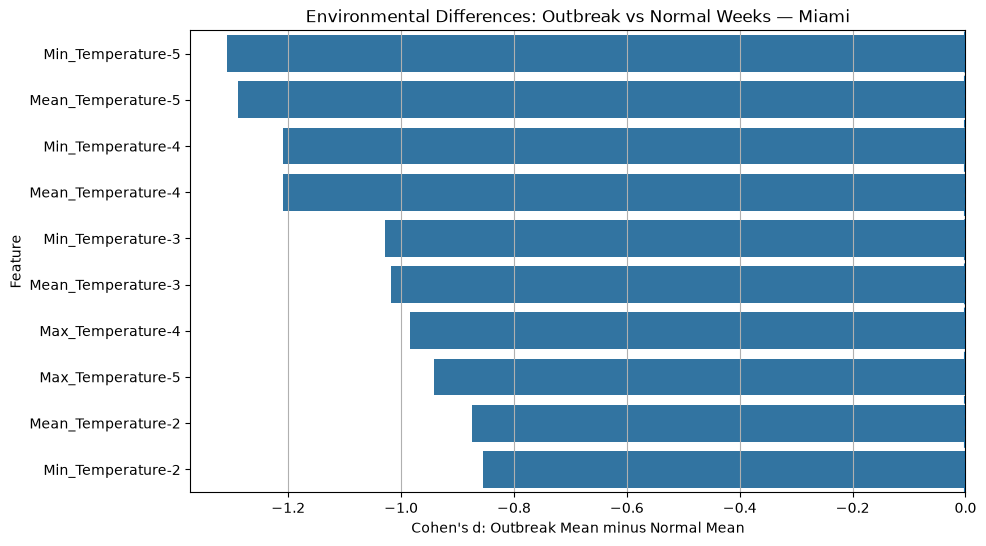

In [114]:
plot_environment_outbreak_differences(
    combined_env_outbreak_comparison,
    city_name="Miami",
    top_n=10
)

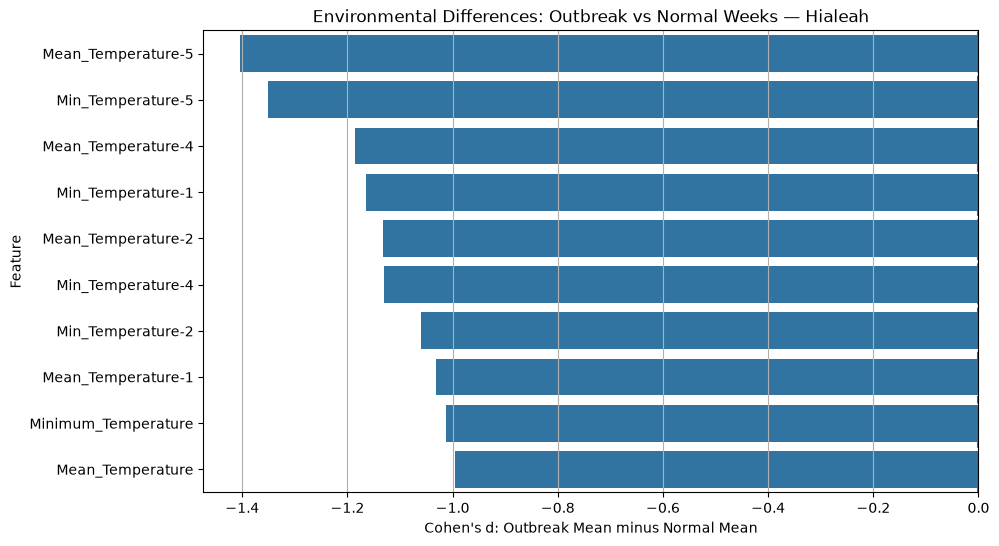

In [115]:
plot_environment_outbreak_differences(
    combined_env_outbreak_comparison,
    city_name="Hialeah",
    top_n=10
)

In [116]:
def plot_environment_boxplots(
    df,
    features,
    city_name,
    outbreak_col="outbreak_80",
    max_features=6
):
    plot_df = df.copy()

    plot_df["Outbreak Status"] = plot_df[outbreak_col].map({
        0: "Normal Week",
        1: "Outbreak Week"
    })

    for feature in features[:max_features]:
        if feature not in plot_df.columns:
            continue

        plt.figure(figsize=(8, 5))

        sns.boxplot(
            data=plot_df,
            x="Outbreak Status",
            y=feature
        )

        plt.title(f"{feature}: Normal vs Outbreak Weeks — {city_name}")
        plt.xlabel("")
        plt.ylabel(feature)
        plt.show()

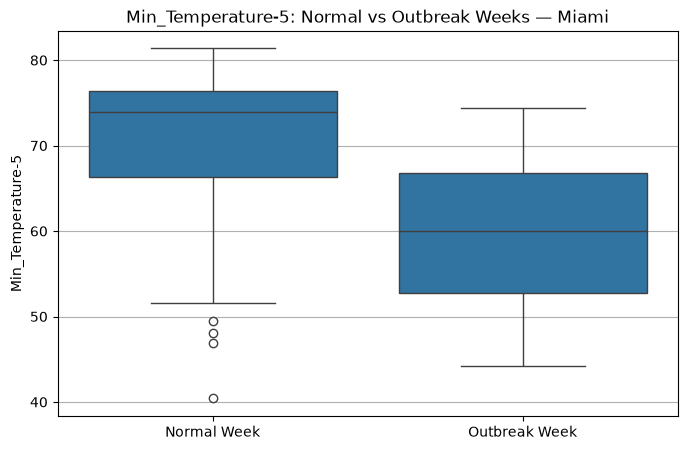

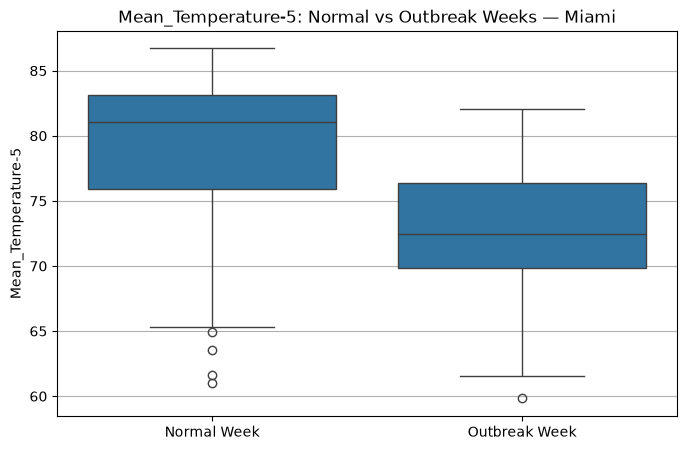

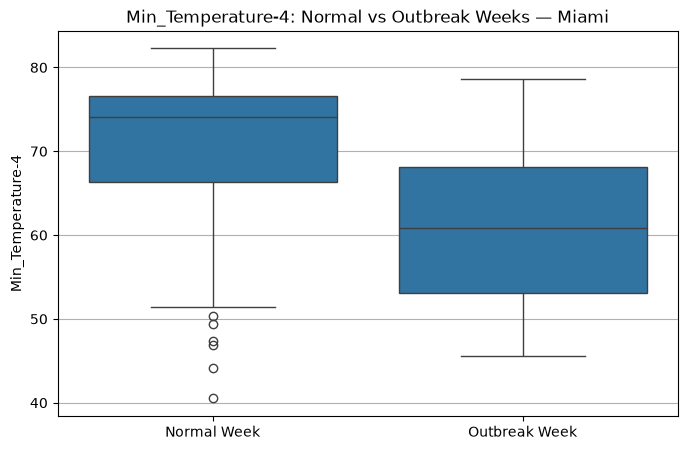

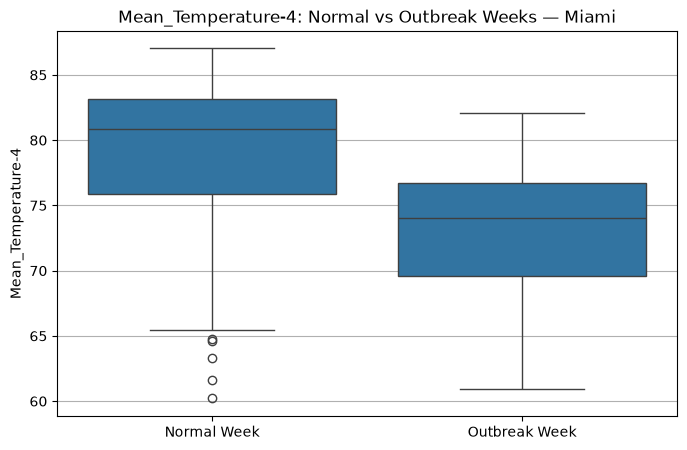

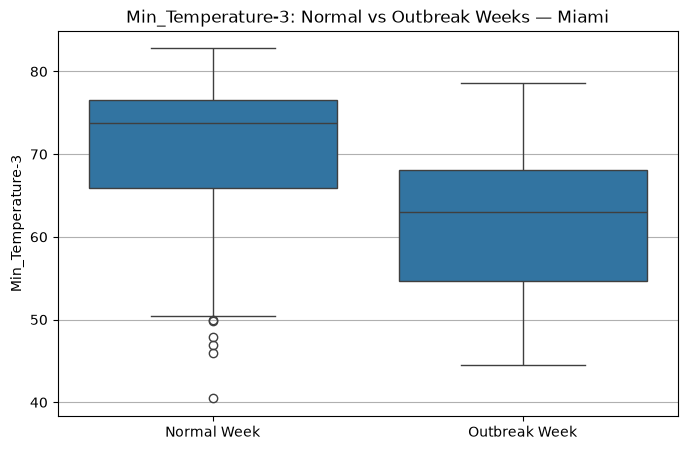

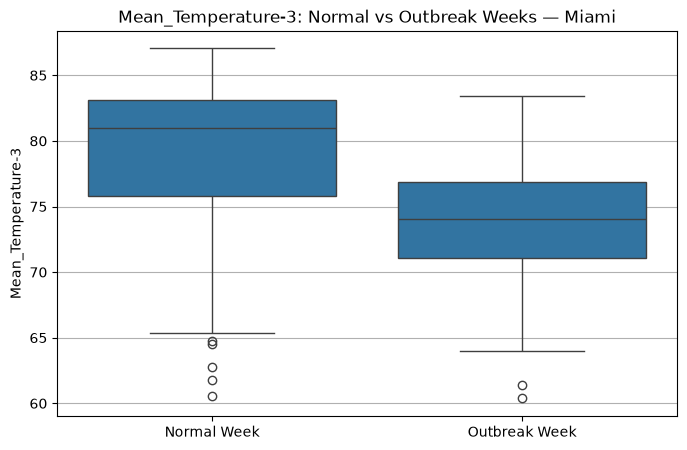

In [117]:
miami_boxplot_features = (
    miami_env_outbreak_comparison
    .sort_values("Abs Cohen_d", ascending=False)
    .head(6)["Feature"]
    .tolist()
)

plot_environment_boxplots(
    df_miami_model,
    features=miami_boxplot_features,
    city_name="Miami",
    outbreak_col="outbreak_80",
    max_features=6
)

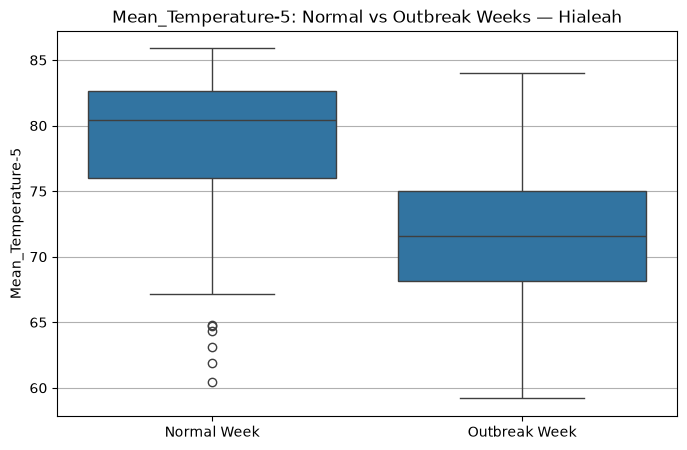

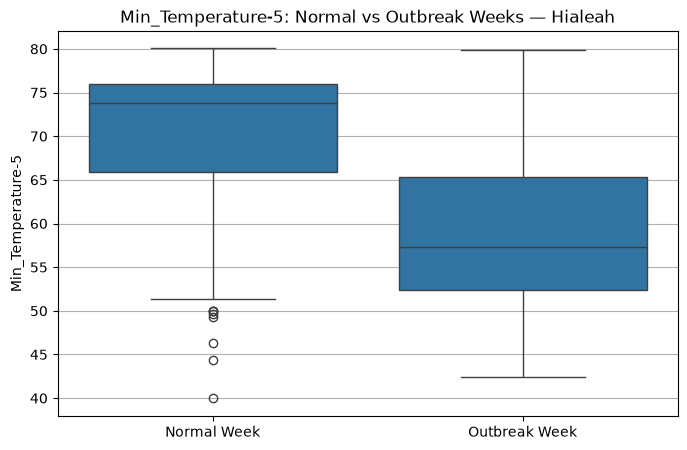

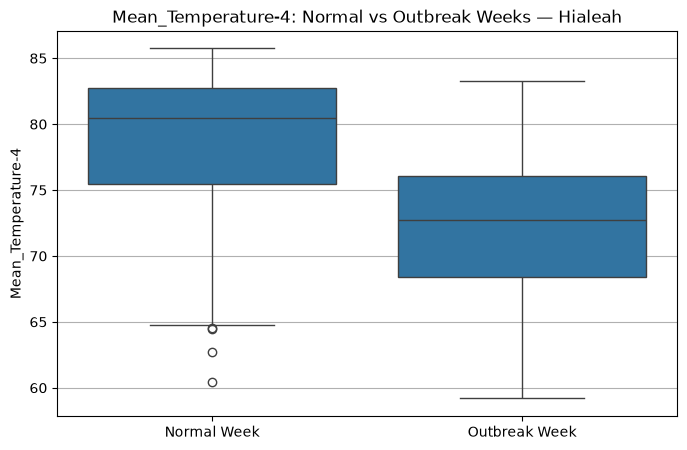

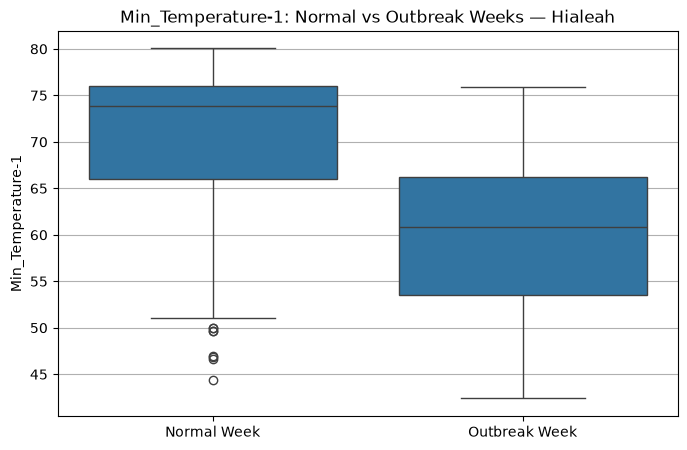

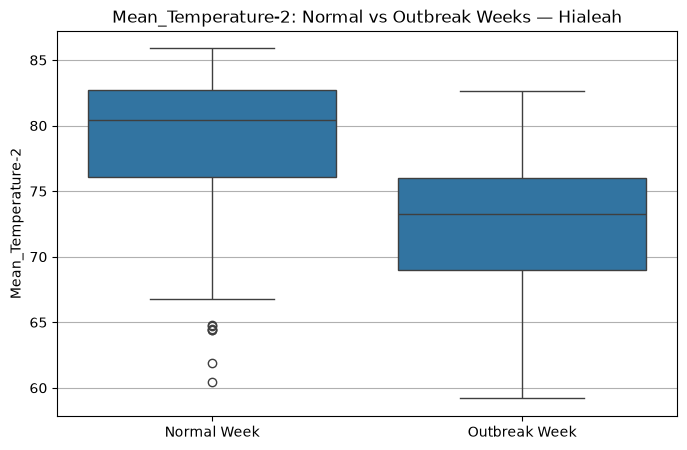

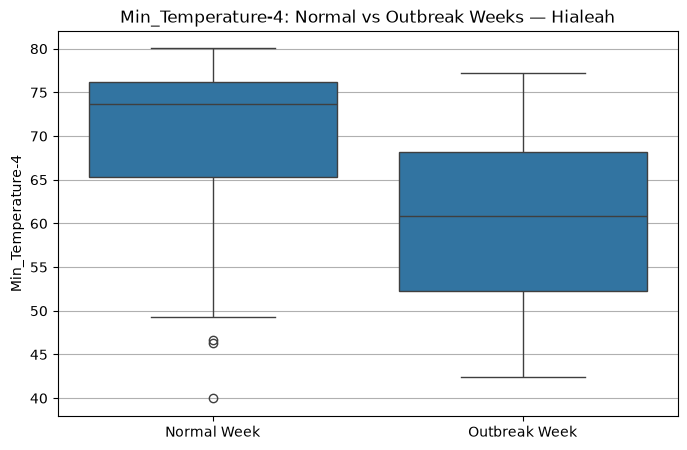

In [118]:
hialeah_boxplot_features = (
    hialeah_env_outbreak_comparison
    .sort_values("Abs Cohen_d", ascending=False)
    .head(6)["Feature"]
    .tolist()
)

plot_environment_boxplots(
    df_hialeah_model,
    features=hialeah_boxplot_features,
    city_name="Hialeah",
    outbreak_col="outbreak_80",
    max_features=6
)

In [119]:
effect_size_pivot = combined_env_outbreak_comparison.pivot_table(
    index="Feature",
    columns="City",
    values="Cohen_d"
)

effect_size_pivot

City,Hialeah,Miami
Feature,,
Max_Temperature-4,NaN,-0.984908
Max_Temperature-5,NaN,-0.941710
Mean_Temperature,-0.995372,NaN
Mean_Temperature-1,-1.032359,NaN
Mean_Temperature-2,-1.133013,-0.874032
Mean_Temperature-3,NaN,-1.018160
Mean_Temperature-4,-1.186490,-1.208557
Mean_Temperature-5,-1.403477,-1.289358
Min_Temperature-1,-1.163739,NaN


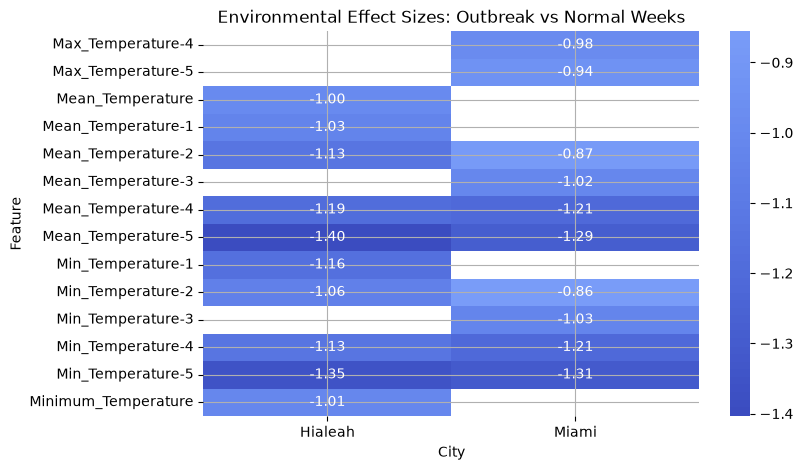

In [120]:
plt.figure(figsize=(8, max(5, len(effect_size_pivot) * 0.35)))

sns.heatmap(
    effect_size_pivot,
    annot=True,
    fmt=".2f",
    center=0,
    cmap="coolwarm"
)

plt.title("Environmental Effect Sizes: Outbreak vs Normal Weeks")
plt.xlabel("City")
plt.ylabel("Feature")
plt.show()

In [121]:
def assign_environment_family(feature):
    if "Precipitation" in feature:
        return "Precipitation"
    elif "Temperature" in feature:
        return "Temperature"
    elif "Humidity" in feature:
        return "Humidity"
    elif "NDVI" in feature:
        return "NDVI"
    elif "WATER_BODY" in feature:
        return "Water Body"
    elif feature in STATIC_VARS:
        return "Static/Context"
    else:
        return "Other"


combined_env_outbreak_comparison["Environmental Family"] = (
    combined_env_outbreak_comparison["Feature"]
    .apply(assign_environment_family)
)

family_effect_summary = (
    combined_env_outbreak_comparison
    .groupby(["City", "Environmental Family"])
    .agg(
        Mean_Abs_Cohen_d=("Abs Cohen_d", "mean"),
        Max_Abs_Cohen_d=("Abs Cohen_d", "max"),
        Mean_Cohen_d=("Cohen_d", "mean"),
        Number_of_Features=("Feature", "count")
    )
    .reset_index()
    .sort_values(["City", "Max_Abs_Cohen_d"], ascending=[True, False])
)

family_effect_summary

,City,Environmental Family,Mean_Abs_Cohen_d,Max_Abs_Cohen_d,Mean_Cohen_d,Number_of_Features
0,Hialeah,Temperature,1.146922,1.403477,-1.146922,10
1,Miami,Temperature,1.071737,1.307700,-1.071737,10


In [122]:
family_effect_summary.style.format({
    "Mean_Abs_Cohen_d": "{:.3f}",
    "Max_Abs_Cohen_d": "{:.3f}",
    "Mean_Cohen_d": "{:.3f}"
})

,City,Environmental Family,Mean_Abs_Cohen_d,Max_Abs_Cohen_d,Mean_Cohen_d,Number_of_Features
0,Hialeah,Temperature,1.147,1.403,-1.147,10
1,Miami,Temperature,1.072,1.308,-1.072,10


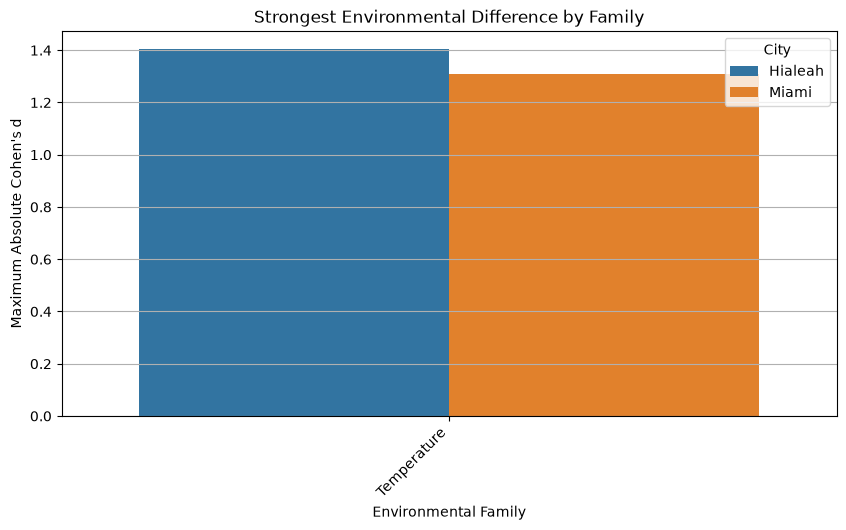

In [123]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=family_effect_summary,
    x="Environmental Family",
    y="Max_Abs_Cohen_d",
    hue="City"
)

plt.title("Strongest Environmental Difference by Family")
plt.xlabel("Environmental Family")
plt.ylabel("Maximum Absolute Cohen's d")
plt.xticks(rotation=45, ha="right")
plt.legend(title="City")
plt.show()

In [124]:
combined_env_outbreak_comparison.to_csv(
    "multivariate_environmental_outbreak_comparison.csv",
    index=False
)

family_effect_summary.to_csv(
    "multivariate_environmental_family_effect_summary.csv",
    index=False
)

In [125]:
def get_best_feature_per_family(lag_corr_df, city_name):
    
    city_df = lag_corr_df[
        lag_corr_df["City"] == city_name
    ].copy()

    best_family_features = (
        city_df
        .sort_values("Abs Correlation", ascending=False)
        .groupby("Environmental Family")
        .first()
        .reset_index()
    )

    best_family_features = best_family_features[
        [
            "Environmental Family",
            "Variable",
            "Lag",
            "Correlation",
            "Abs Correlation"
        ]
    ].sort_values("Abs Correlation", ascending=False)

    return best_family_features.reset_index(drop=True)

In [126]:
miami_best_family_features = get_best_feature_per_family(
    combined_lag_corr,
    city_name="Miami"
)

miami_best_family_features

,Environmental Family,Variable,Lag,Correlation,Abs Correlation
0,Mean Temperature,Mean_Temperature-5,5,-0.601552,0.601552
1,Minimum Temperature,Min_Temperature-5,5,-0.592995,0.592995
2,Maximum Temperature,Max_Temperature-4,4,-0.491071,0.491071
3,Minimum Humidity,Minimum_Humidity,0,-0.472180,0.472180
4,Mean Humidity,Mean_Humidity-1,1,-0.400157,0.400157
5,Precipitation,Mean_Precipitation-1,1,-0.292299,0.292299
6,Maximum Humidity,Max_Humidity-1,1,-0.123883,0.123883


In [127]:
hialeah_best_family_features = get_best_feature_per_family(
    combined_lag_corr,
    city_name="Hialeah"
)

hialeah_best_family_features

,Environmental Family,Variable,Lag,Correlation,Abs Correlation
0,Mean Temperature,Mean_Temperature-5,5,-0.470313,0.470313
1,Minimum Temperature,Min_Temperature-5,5,-0.452913,0.452913
2,Maximum Temperature,Max_Temperature-3,3,-0.390183,0.390183
3,Mean Humidity,Mean_Humidity,0,-0.377161,0.377161
4,Minimum Humidity,Minimum_Humidity,0,-0.371511,0.371511
5,Precipitation,Mean_Precipitation,0,-0.249275,0.249275
6,Maximum Humidity,Maximum_Humidity,0,-0.161186,0.161186


In [128]:
best_family_features_combined = pd.concat([
    miami_best_family_features.assign(City="Miami"),
    hialeah_best_family_features.assign(City="Hialeah")
]).reset_index(drop=True)

best_family_features_combined = best_family_features_combined[
    [
        "City",
        "Environmental Family",
        "Variable",
        "Lag",
        "Correlation",
        "Abs Correlation"
    ]
]

best_family_features_combined

,City,Environmental Family,Variable,Lag,Correlation,Abs Correlation
0,Miami,Mean Temperature,Mean_Temperature-5,5,-0.601552,0.601552
1,Miami,Minimum Temperature,Min_Temperature-5,5,-0.592995,0.592995
2,Miami,Maximum Temperature,Max_Temperature-4,4,-0.491071,0.491071
3,Miami,Minimum Humidity,Minimum_Humidity,0,-0.472180,0.472180
4,Miami,Mean Humidity,Mean_Humidity-1,1,-0.400157,0.400157
5,Miami,Precipitation,Mean_Precipitation-1,1,-0.292299,0.292299
6,Miami,Maximum Humidity,Max_Humidity-1,1,-0.123883,0.123883
7,Hialeah,Mean Temperature,Mean_Temperature-5,5,-0.470313,0.470313
8,Hialeah,Minimum Temperature,Min_Temperature-5,5,-0.452913,0.452913
9,Hialeah,Maximum Temperature,Max_Temperature-3,3,-0.390183,0.390183


In [129]:
best_family_features_combined.style.format({
    "Correlation": "{:.3f}",
    "Abs Correlation": "{:.3f}"
})

,City,Environmental Family,Variable,Lag,Correlation,Abs Correlation
0,Miami,Mean Temperature,Mean_Temperature-5,5,-0.602,0.602
1,Miami,Minimum Temperature,Min_Temperature-5,5,-0.593,0.593
2,Miami,Maximum Temperature,Max_Temperature-4,4,-0.491,0.491
3,Miami,Minimum Humidity,Minimum_Humidity,0,-0.472,0.472
4,Miami,Mean Humidity,Mean_Humidity-1,1,-0.400,0.400
5,Miami,Precipitation,Mean_Precipitation-1,1,-0.292,0.292
6,Miami,Maximum Humidity,Max_Humidity-1,1,-0.124,0.124
7,Hialeah,Mean Temperature,Mean_Temperature-5,5,-0.470,0.470
8,Hialeah,Minimum Temperature,Min_Temperature-5,5,-0.453,0.453
9,Hialeah,Maximum Temperature,Max_Temperature-3,3,-0.390,0.390


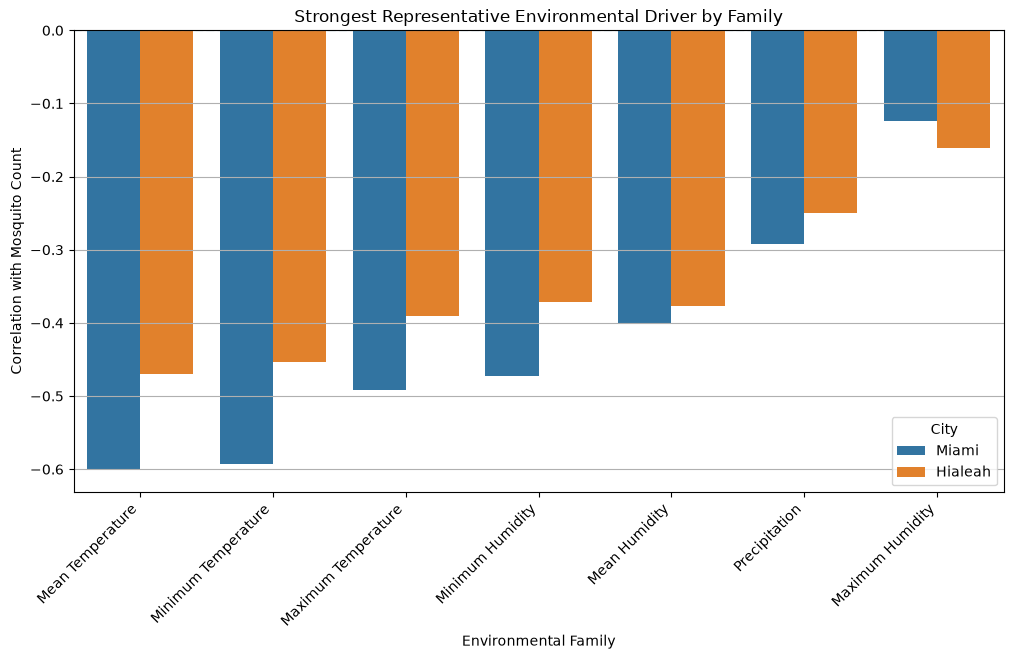

In [130]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=best_family_features_combined,
    x="Environmental Family",
    y="Correlation",
    hue="City"
)

plt.axhline(0, linestyle="--")

plt.title("Strongest Representative Environmental Driver by Family")
plt.xlabel("Environmental Family")
plt.ylabel("Correlation with Mosquito Count")
plt.xticks(rotation=45, ha="right")
plt.legend(title="City")
plt.show()

In [131]:
miami_representative_env_features = (
    miami_best_family_features["Variable"]
    .dropna()
    .unique()
    .tolist()
)

hialeah_representative_env_features = (
    hialeah_best_family_features["Variable"]
    .dropna()
    .unique()
    .tolist()
)

print("Miami representative environmental features:")
print(miami_representative_env_features)

print("\nHialeah representative environmental features:")
print(hialeah_representative_env_features)

Miami representative environmental features:
['Mean_Temperature-5', 'Min_Temperature-5', 'Max_Temperature-4', 'Minimum_Humidity', 'Mean_Humidity-1', 'Mean_Precipitation-1', 'Max_Humidity-1']

Hialeah representative environmental features:
['Mean_Temperature-5', 'Min_Temperature-5', 'Max_Temperature-3', 'Mean_Humidity', 'Minimum_Humidity', 'Mean_Precipitation', 'Maximum_Humidity']


In [132]:
context_features = (
    ENVIRONMENTAL_CONTEXT_VARS
    + STATIC_VARS
)

context_features = [
    col for col in context_features
    if col in df_city_time.columns
]

print("Context features added:")
print(context_features)

miami_clean_env_features = list(dict.fromkeys(
    miami_representative_env_features + context_features
))

hialeah_clean_env_features = list(dict.fromkeys(
    hialeah_representative_env_features + context_features
))

print("\nFinal clean Miami environmental feature set:")
print(miami_clean_env_features)

print("\nFinal clean Hialeah environmental feature set:")
print(hialeah_clean_env_features)

Context features added:
['NDVI', 'NDVI_-1', 'WATER_BODY', 'WATER_BODY_-1', 'Manhole_within_1KM', 'ElevationinFeet', 'DistancetoCanal', 'POVERTY_RATE', 'POVERTY_NUMBER']

Final clean Miami environmental feature set:
['Mean_Temperature-5', 'Min_Temperature-5', 'Max_Temperature-4', 'Minimum_Humidity', 'Mean_Humidity-1', 'Mean_Precipitation-1', 'Max_Humidity-1', 'NDVI', 'NDVI_-1', 'WATER_BODY', 'WATER_BODY_-1', 'Manhole_within_1KM', 'ElevationinFeet', 'DistancetoCanal', 'POVERTY_RATE', 'POVERTY_NUMBER']

Final clean Hialeah environmental feature set:
['Mean_Temperature-5', 'Min_Temperature-5', 'Max_Temperature-3', 'Mean_Humidity', 'Minimum_Humidity', 'Mean_Precipitation', 'Maximum_Humidity', 'NDVI', 'NDVI_-1', 'WATER_BODY', 'WATER_BODY_-1', 'Manhole_within_1KM', 'ElevationinFeet', 'DistancetoCanal', 'POVERTY_RATE', 'POVERTY_NUMBER']


In [133]:
best_family_features_combined.to_csv(
    "multivariate_representative_environmental_features.csv",
    index=False
)

In [134]:
def evaluate_rule(y_true, y_pred, city_name, rule_name, rule_type):
    """
    Evaluates a binary outbreak decision rule.
    """

    return {
        "City": city_name,
        "Rule Type": rule_type,
        "Rule": rule_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Predicted Outbreak Weeks": int(np.sum(y_pred)),
        "Actual Outbreak Weeks": int(np.sum(y_true))
    }

In [135]:
def high_threshold(series, q=0.75):
    return series.quantile(q)

def low_threshold(series, q=0.25):
    return series.quantile(q)

In [136]:
def build_environmental_rules(df, clean_env_features):
    """
    Builds environmental-only rules using representative environmental
    features selected earlier.

    Since correlations may be positive or negative, we use the direction
    observed in the data:
      - if outbreak mean > normal mean, high values predict outbreak
      - if outbreak mean < normal mean, low values predict outbreak
    """

    rules = {}

    for feature in clean_env_features:
        if feature not in df.columns:
            continue

        normal_mean = df[df["outbreak_80"] == 0][feature].mean()
        outbreak_mean = df[df["outbreak_80"] == 1][feature].mean()

        if outbreak_mean >= normal_mean:
            threshold = high_threshold(df[feature], q=0.75)
            rule_name = f"{feature} High"
            rules[rule_name] = (df[feature] >= threshold).astype(int)
        else:
            threshold = low_threshold(df[feature], q=0.25)
            rule_name = f"{feature} Low"
            rules[rule_name] = (df[feature] <= threshold).astype(int)

    return rules

In [137]:
def build_mosquito_history_rules(df):

    rules = {}

    lag1_threshold = high_threshold(df["mosq_lag_1"], q=0.75)
    roll2_threshold = high_threshold(df["mosq_roll_mean_2"], q=0.75)
    roll4_threshold = high_threshold(df["mosq_roll_mean_4"], q=0.75)

    rules["Mosq Lag 1 High"] = (
        df["mosq_lag_1"] >= lag1_threshold
    ).astype(int)

    rules["Mosq Rolling Mean 2 High"] = (
        df["mosq_roll_mean_2"] >= roll2_threshold
    ).astype(int)

    rules["Mosq Rolling Mean 4 High"] = (
        df["mosq_roll_mean_4"] >= roll4_threshold
    ).astype(int)

    rules["Mosq Rolling Mean 2 AND Rolling Mean 4 High"] = (
        (df["mosq_roll_mean_2"] >= roll2_threshold) &
        (df["mosq_roll_mean_4"] >= roll4_threshold)
    ).astype(int)

    rules["Mosq Lag 1 AND Rolling Mean 4 High"] = (
        (df["mosq_lag_1"] >= lag1_threshold) &
        (df["mosq_roll_mean_4"] >= roll4_threshold)
    ).astype(int)

    return rules

In [138]:
def build_hybrid_rules(df, clean_env_features):
    """
    Builds hybrid rules combining mosquito-history information
    with environmental warning signals.

    We use the strongest mosquito rule:
      Mosq Rolling Mean 2 AND Rolling Mean 4 High

    Then combine it with each environmental rule.
    """

    hybrid_rules = {}

    mosquito_rules = build_mosquito_history_rules(df)
    environmental_rules = build_environmental_rules(df, clean_env_features)

    base_mosq_rule_name = "Mosq Rolling Mean 2 AND Rolling Mean 4 High"
    base_mosq_rule = mosquito_rules[base_mosq_rule_name]

    for env_rule_name, env_rule in environmental_rules.items():

        hybrid_rules[f"{base_mosq_rule_name} AND {env_rule_name}"] = (
            (base_mosq_rule == 1) &
            (env_rule == 1)
        ).astype(int)

        hybrid_rules[f"{base_mosq_rule_name} OR {env_rule_name}"] = (
            (base_mosq_rule == 1) |
            (env_rule == 1)
        ).astype(int)

    return hybrid_rules

In [139]:
def evaluate_all_decision_rules(df, city_name, clean_env_features):
    """
    Evaluates environmental-only, mosquito-history-only, and hybrid rules.
    """

    y_true = df["outbreak_80"].astype(int).values

    results = []
    predictions = {}

    # Environmental-only rules
    environmental_rules = build_environmental_rules(df, clean_env_features)

    for rule_name, y_pred in environmental_rules.items():
        results.append(
            evaluate_rule(
                y_true=y_true,
                y_pred=y_pred.values,
                city_name=city_name,
                rule_name=rule_name,
                rule_type="Environmental Only"
            )
        )

        predictions[rule_name] = y_pred.values

    # Mosquito-history-only rules
    mosquito_rules = build_mosquito_history_rules(df)

    for rule_name, y_pred in mosquito_rules.items():
        results.append(
            evaluate_rule(
                y_true=y_true,
                y_pred=y_pred.values,
                city_name=city_name,
                rule_name=rule_name,
                rule_type="Mosquito History Only"
            )
        )

        predictions[rule_name] = y_pred.values

    # Hybrid rules
    hybrid_rules = build_hybrid_rules(df, clean_env_features)

    for rule_name, y_pred in hybrid_rules.items():
        results.append(
            evaluate_rule(
                y_true=y_true,
                y_pred=y_pred.values,
                city_name=city_name,
                rule_name=rule_name,
                rule_type="Hybrid"
            )
        )

        predictions[rule_name] = y_pred.values

    results_df = (
        pd.DataFrame(results)
        .sort_values("F1", ascending=False)
        .reset_index(drop=True)
    )

    return results_df, predictions

In [140]:
miami_rule_results_multi, miami_rule_predictions_multi = evaluate_all_decision_rules(
    df_miami_model,
    city_name="Miami",
    clean_env_features=miami_clean_env_features
)

miami_rule_results_multi

,City,Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Outbreak Weeks
0,Miami,Mosquito History Only,Mosq Rolling Mean 2 High,0.850174,0.611111,0.745763,0.671756,72,59
1,Miami,Mosquito History Only,Mosq Rolling Mean 4 High,0.850174,0.611111,0.745763,0.671756,72,59
2,Miami,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.857143,0.655172,0.644068,0.649573,58,59
3,Miami,Mosquito History Only,Mosq Lag 1 AND Rolling Mean 4 High,0.860627,0.672727,0.627119,0.649123,55,59
4,Miami,Mosquito History Only,Mosq Lag 1 High,0.836237,0.583333,0.711864,0.641221,72,59
5,Miami,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.787456,0.490741,0.898305,0.634731,108,59
6,Miami,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.790941,0.494949,0.830508,0.620253,99,59
7,Miami,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.783972,0.485437,0.847458,0.617284,103,59
8,Miami,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.773519,0.471154,0.830508,0.601227,104,59
9,Miami,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.773519,0.469388,0.779661,0.585987,98,59


In [141]:
hialeah_rule_results_multi, hialeah_rule_predictions_multi = evaluate_all_decision_rules(
    df_hialeah_model,
    city_name="Hialeah",
    clean_env_features=hialeah_clean_env_features
)

hialeah_rule_results_multi

,City,Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Outbreak Weeks
0,Hialeah,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.860902,0.660377,0.648148,0.654206,53,54
1,Hialeah,Mosquito History Only,Mosq Rolling Mean 4 High,0.834586,0.573529,0.722222,0.639344,68,54
2,Hialeah,Mosquito History Only,Mosq Rolling Mean 2 High,0.830827,0.567164,0.703704,0.628099,67,54
3,Hialeah,Mosquito History Only,Mosq Lag 1 AND Rolling Mean 4 High,0.849624,0.640000,0.592593,0.615385,50,54
4,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.793233,0.494382,0.814815,0.615385,89,54
5,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.785714,0.483146,0.796296,0.601399,89,54
6,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.770677,0.464646,0.851852,0.601307,99,54
7,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.774436,0.468750,0.833333,0.600000,96,54
8,Hialeah,Mosquito History Only,Mosq Lag 1 High,0.815789,0.537313,0.666667,0.595041,67,54
9,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.774436,0.468085,0.814815,0.594595,94,54


In [142]:
combined_rule_results_multi = pd.concat([
    miami_rule_results_multi,
    hialeah_rule_results_multi
]).reset_index(drop=True)

combined_rule_results_multi = combined_rule_results_multi.sort_values(
    ["City", "F1"],
    ascending=[True, False]
).reset_index(drop=True)

combined_rule_results_multi

,City,Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Outbreak Weeks
0,Hialeah,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.860902,0.660377,0.648148,0.654206,53,54
1,Hialeah,Mosquito History Only,Mosq Rolling Mean 4 High,0.834586,0.573529,0.722222,0.639344,68,54
2,Hialeah,Mosquito History Only,Mosq Rolling Mean 2 High,0.830827,0.567164,0.703704,0.628099,67,54
3,Hialeah,Mosquito History Only,Mosq Lag 1 AND Rolling Mean 4 High,0.849624,0.640000,0.592593,0.615385,50,54
4,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.793233,0.494382,0.814815,0.615385,89,54
...,...,...,...,...,...,...,...,...,...
101,Miami,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High AN...,0.801394,0.555556,0.169492,0.259740,18,59
102,Miami,Environmental Only,NDVI Low,0.662021,0.236111,0.288136,0.259542,72,59
103,Miami,Environmental Only,WATER_BODY Low,0.662021,0.236111,0.288136,0.259542,72,59
104,Miami,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High AN...,0.801394,0.562500,0.152542,0.240000,16,59


In [143]:
combined_rule_results_multi.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}"
})

,City,Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Outbreak Weeks
0,Hialeah,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.861,0.660,0.648,0.654,53,54
1,Hialeah,Mosquito History Only,Mosq Rolling Mean 4 High,0.835,0.574,0.722,0.639,68,54
2,Hialeah,Mosquito History Only,Mosq Rolling Mean 2 High,0.831,0.567,0.704,0.628,67,54
3,Hialeah,Mosquito History Only,Mosq Lag 1 AND Rolling Mean 4 High,0.850,0.640,0.593,0.615,50,54
4,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR Mean_Temperature-5 Low,0.793,0.494,0.815,0.615,89,54
5,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR Min_Temperature-5 Low,0.786,0.483,0.796,0.601,89,54
6,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR Minimum_Humidity Low,0.771,0.465,0.852,0.601,99,54
7,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR Max_Temperature-3 Low,0.774,0.469,0.833,0.600,96,54
8,Hialeah,Mosquito History Only,Mosq Lag 1 High,0.816,0.537,0.667,0.595,67,54
9,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR Mean_Humidity Low,0.774,0.468,0.815,0.595,94,54


In [144]:
best_rule_by_type = (
    combined_rule_results_multi
    .sort_values(["City", "Rule Type", "F1"], ascending=[True, True, False])
    .groupby(["City", "Rule Type"])
    .head(1)
    .reset_index(drop=True)
)

best_rule_by_type

,City,Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Outbreak Weeks
0,Hialeah,Environmental Only,Mean_Temperature-5 Low,0.793233,0.492537,0.611111,0.545455,67,54
1,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.793233,0.494382,0.814815,0.615385,89,54
2,Hialeah,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.860902,0.660377,0.648148,0.654206,53,54
3,Miami,Environmental Only,Mean_Temperature-5 Low,0.773519,0.458333,0.559322,0.503817,72,59
4,Miami,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.787456,0.490741,0.898305,0.634731,108,59
5,Miami,Mosquito History Only,Mosq Rolling Mean 2 High,0.850174,0.611111,0.745763,0.671756,72,59


In [145]:
best_overall_rule_by_city = (
    combined_rule_results_multi
    .sort_values(["City", "F1"], ascending=[True, False])
    .groupby("City")
    .head(1)
    .reset_index(drop=True)
)

best_overall_rule_by_city

,City,Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Outbreak Weeks
0,Hialeah,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.860902,0.660377,0.648148,0.654206,53,54
1,Miami,Mosquito History Only,Mosq Rolling Mean 2 High,0.850174,0.611111,0.745763,0.671756,72,59


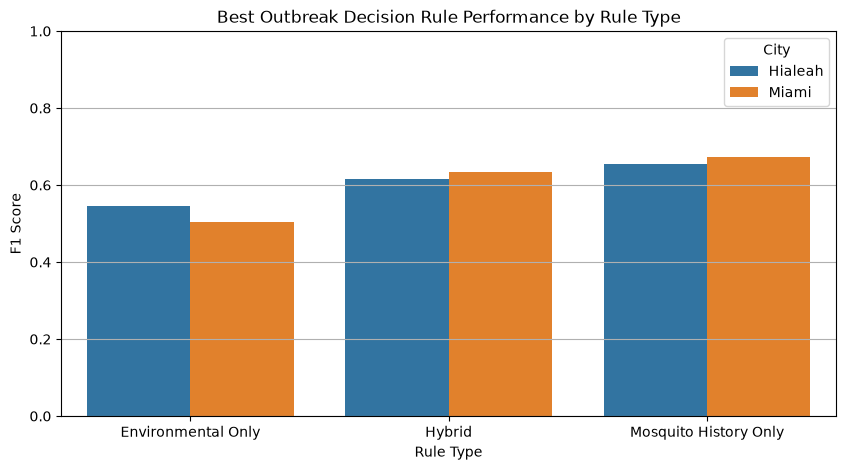

In [146]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=best_rule_by_type,
    x="Rule Type",
    y="F1",
    hue="City"
)

plt.title("Best Outbreak Decision Rule Performance by Rule Type")
plt.xlabel("Rule Type")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.legend(title="City")
plt.show()

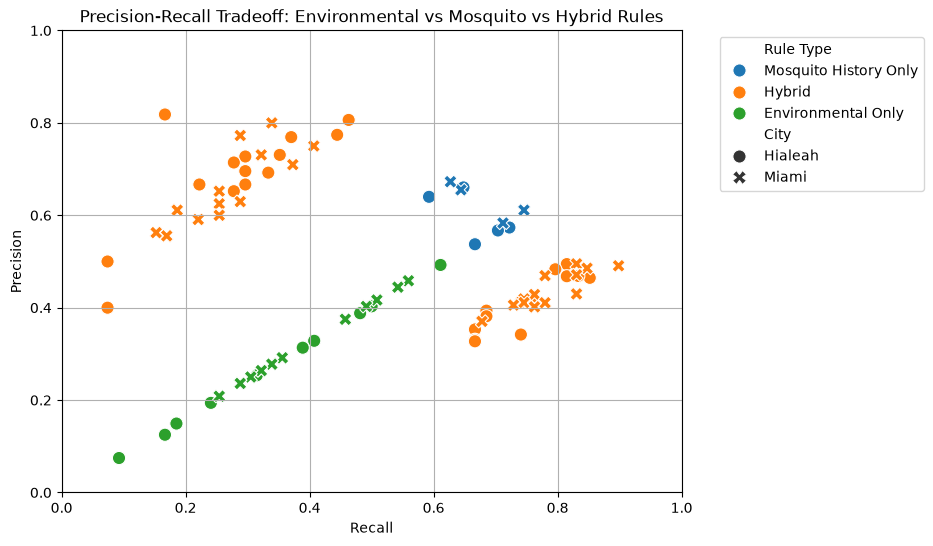

In [147]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    data=combined_rule_results_multi,
    x="Recall",
    y="Precision",
    hue="Rule Type",
    style="City",
    s=90
)

plt.title("Precision-Recall Tradeoff: Environmental vs Mosquito vs Hybrid Rules")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [148]:
def plot_best_rule_confusion_matrix(df, predictions, best_rule_name, city_name):
    y_true = df["outbreak_80"].astype(int).values
    y_pred = predictions[best_rule_name]

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pred Normal", "Pred Outbreak"],
        yticklabels=["Actual Normal", "Actual Outbreak"]
    )

    plt.title(f"Best Rule Confusion Matrix — {city_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

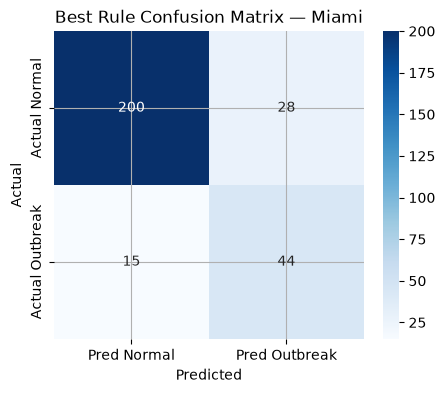

Best Miami rule: Mosq Rolling Mean 2 High


In [149]:
best_miami_multi_rule = best_overall_rule_by_city[
    best_overall_rule_by_city["City"] == "Miami"
]["Rule"].iloc[0]

plot_best_rule_confusion_matrix(
    df_miami_model,
    miami_rule_predictions_multi,
    best_rule_name=best_miami_multi_rule,
    city_name="Miami"
)

print("Best Miami rule:", best_miami_multi_rule)

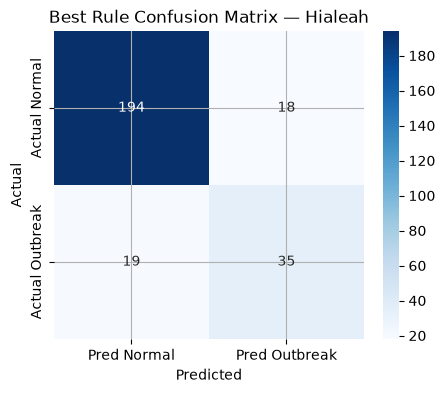

Best Hialeah rule: Mosq Rolling Mean 2 AND Rolling Mean 4 High


In [150]:
best_hialeah_multi_rule = best_overall_rule_by_city[
    best_overall_rule_by_city["City"] == "Hialeah"
]["Rule"].iloc[0]

plot_best_rule_confusion_matrix(
    df_hialeah_model,
    hialeah_rule_predictions_multi,
    best_rule_name=best_hialeah_multi_rule,
    city_name="Hialeah"
)

print("Best Hialeah rule:", best_hialeah_multi_rule)

In [151]:
environmental_only_results = combined_rule_results_multi[
    combined_rule_results_multi["Rule Type"] == "Environmental Only"
].copy()

environmental_only_results = environmental_only_results.sort_values(
    ["City", "F1"],
    ascending=[True, False]
).reset_index(drop=True)

environmental_only_results

,City,Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Outbreak Weeks
0,Hialeah,Environmental Only,Mean_Temperature-5 Low,0.793233,0.492537,0.611111,0.545455,67,54
1,Hialeah,Environmental Only,Min_Temperature-5 Low,0.793233,0.492537,0.611111,0.545455,67,54
2,Hialeah,Environmental Only,Mean_Humidity Low,0.748120,0.402985,0.500000,0.446281,67,54
3,Hialeah,Environmental Only,Max_Temperature-3 Low,0.740602,0.388060,0.481481,0.429752,67,54
4,Hialeah,Environmental Only,Minimum_Humidity Low,0.740602,0.388060,0.481481,0.429752,67,54
5,Hialeah,Environmental Only,Maximum_Humidity Low,0.710526,0.328358,0.407407,0.363636,67,54
6,Hialeah,Environmental Only,POVERTY_NUMBER Low,0.710526,0.328358,0.407407,0.363636,67,54
7,Hialeah,Environmental Only,Mean_Precipitation Low,0.703008,0.313433,0.388889,0.347107,67,54
8,Hialeah,Environmental Only,POVERTY_RATE Low,0.703008,0.313433,0.388889,0.347107,67,54
9,Hialeah,Environmental Only,ElevationinFeet Low,0.672932,0.253731,0.314815,0.280992,67,54


In [152]:
hybrid_results = combined_rule_results_multi[
    combined_rule_results_multi["Rule Type"] == "Hybrid"
].copy()

hybrid_results = hybrid_results.sort_values(
    ["City", "F1"],
    ascending=[True, False]
).reset_index(drop=True)

hybrid_results.head(20)

,City,Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Outbreak Weeks
0,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.793233,0.494382,0.814815,0.615385,89,54
1,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.785714,0.483146,0.796296,0.601399,89,54
2,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.770677,0.464646,0.851852,0.601307,99,54
3,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.774436,0.468750,0.833333,0.600000,96,54
4,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.774436,0.468085,0.814815,0.594595,94,54
5,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High AN...,0.868421,0.806452,0.462963,0.588235,31,54
6,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High AN...,0.860902,0.774194,0.444444,0.564706,31,54
7,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.736842,0.418367,0.759259,0.539474,98,54
8,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.733083,0.412371,0.740741,0.529801,97,54
9,Hialeah,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High AN...,0.849624,0.769231,0.370370,0.500000,26,54


In [153]:
combined_rule_results_multi.to_csv(
    "multivariate_environmental_hybrid_decision_rules.csv",
    index=False
)

best_rule_by_type.to_csv(
    "multivariate_best_rule_by_type.csv",
    index=False
)

best_overall_rule_by_city.to_csv(
    "multivariate_best_overall_rule_by_city.csv",
    index=False
)

In [154]:
df_ablation = df_multi.copy()

df_ablation['mosq_lag_1'] = df_ablation.groupby(['City', 'TRAPID'])[TARGET_COL].shift(1)
df_ablation['mosq_lag_2'] = df_ablation.groupby(['City', 'TRAPID'])[TARGET_COL].shift(2)
df_ablation['mosq_lag_3'] = df_ablation.groupby(['City', 'TRAPID'])[TARGET_COL].shift(3)
df_ablation['mosq_lag_4'] = df_ablation.groupby(['City', 'TRAPID'])[TARGET_COL].shift(4)

df_ablation['mosq_roll_mean_2'] = df_ablation.groupby(['City', 'TRAPID'])['mosq_lag_1'].rolling(window=2, min_periods=1).mean().reset_index(level=[0,1], drop=True)
df_ablation['mosq_roll_mean_4'] = df_ablation.groupby(['City', 'TRAPID'])['mosq_lag_1'].rolling(window=4, min_periods=1).mean().reset_index(level=[0,1], drop=True)

mosq_features = ['mosq_lag_1', 'mosq_lag_2', 'mosq_lag_3', 'mosq_lag_4', 'mosq_roll_mean_2', 'mosq_roll_mean_4']
env_features = [col for col in df_ablation.columns if col not in mosq_features + ['City', 'TRAPID', 'YEAR', 'MONTH', 'WEEK', TARGET_COL, 'time_period', 'date', 'approx_day']]
hybrid_features = mosq_features + env_features

df_ablation = df_ablation.dropna(subset=hybrid_features + [TARGET_COL])

print(df_ablation.shape)
display(df_ablation.head(3))

(15128, 66)


,TRAPID,City,YEAR,MONTH,WEEK,Cx_quinquefasciatus_fem,Manhole_within_1KM,ElevationinFeet,DistancetoCanal,POVERTY_RATE,...,Min_Temperature-5,time_period,approx_day,date,mosq_lag_1,mosq_lag_2,mosq_lag_3,mosq_lag_4,mosq_roll_mean_2,mosq_roll_mean_4
16,CW51,Hialeah,2016,10,2,114.0,0.0,6.830,543.705674,9.0,...,78.38,2016-10-W2,8,2016-10-08,20.000000,15.0,46.00,17.0,17.500000,24.500000
18,MB58,Hialeah,2016,10,2,4.0,6.0,4.905,198.571191,18.1,...,78.38,2016-10-W2,8,2016-10-08,2.333333,2.0,1.75,4.0,2.166667,2.520833
22,CW51,Hialeah,2016,10,3,20.0,0.0,6.830,543.705674,9.0,...,76.64,2016-10-W3,15,2016-10-15,114.000000,20.0,15.00,46.0,67.000000,48.750000


In [155]:
def create_future_outbreak_labels(df, outbreak_col="outbreak_80", horizons=[1, 2, 4]):
   
    df = df.copy()

    for h in horizons:
        df[f"outbreak_{h}wk_ahead"] = df[outbreak_col].shift(-h)

    df = df.dropna(subset=[f"outbreak_{h}wk_ahead" for h in horizons])

    for h in horizons:
        df[f"outbreak_{h}wk_ahead"] = df[f"outbreak_{h}wk_ahead"].astype(int)

    return df.reset_index(drop=True)

In [156]:
lead_horizons = [1, 2, 4]

miami_lead_multi = create_future_outbreak_labels(
    df_miami_model,
    outbreak_col="outbreak_80",
    horizons=lead_horizons
)

hialeah_lead_multi = create_future_outbreak_labels(
    df_hialeah_model,
    outbreak_col="outbreak_80",
    horizons=lead_horizons
)

print("Miami lead-time dataframe:", miami_lead_multi.shape)
print("Hialeah lead-time dataframe:", hialeah_lead_multi.shape)

Miami lead-time dataframe: (283, 69)
Hialeah lead-time dataframe: (262, 69)


In [157]:
def evaluate_lead_rule(y_true, y_pred, city_name, horizon, rule_name, rule_type):
  
    return {
        "City": city_name,
        "Lead Time (weeks)": horizon,
        "Rule Type": rule_type,
        "Rule": rule_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Predicted Outbreak Weeks": int(np.sum(y_pred)),
        "Actual Future Outbreak Weeks": int(np.sum(y_true))
    }

In [158]:
def evaluate_lead_time_rule_sets(df, city_name, clean_env_features, horizons=[1, 2, 4]):

    results = []

    environmental_rules = build_environmental_rules(df, clean_env_features)
    mosquito_rules = build_mosquito_history_rules(df)
    hybrid_rules = build_hybrid_rules(df, clean_env_features)

    rule_sets = {
        "Environmental Only": environmental_rules,
        "Mosquito History Only": mosquito_rules,
        "Hybrid": hybrid_rules
    }

    for h in horizons:
        y_true = df[f"outbreak_{h}wk_ahead"].astype(int).values

        for rule_type, rules in rule_sets.items():
            for rule_name, y_pred_series in rules.items():
                y_pred = np.array(y_pred_series).astype(int)

                results.append(
                    evaluate_lead_rule(
                        y_true=y_true,
                        y_pred=y_pred,
                        city_name=city_name,
                        horizon=h,
                        rule_name=rule_name,
                        rule_type=rule_type
                    )
                )

    results_df = pd.DataFrame(results).sort_values(
        ["Lead Time (weeks)", "F1"],
        ascending=[True, False]
    ).reset_index(drop=True)

    return results_df

In [159]:
miami_lead_rule_results_multi = evaluate_lead_time_rule_sets(
    miami_lead_multi,
    city_name="Miami",
    clean_env_features=miami_clean_env_features,
    horizons=lead_horizons
)

miami_lead_rule_results_multi

,City,Lead Time (weeks),Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Miami,1,Mosquito History Only,Mosq Rolling Mean 2 High,0.837456,0.591549,0.711864,0.646154,71,59
1,Miami,1,Mosquito History Only,Mosq Rolling Mean 4 High,0.837456,0.591549,0.711864,0.646154,71,59
2,Miami,1,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.851590,0.649123,0.627119,0.637931,57,59
3,Miami,1,Mosquito History Only,Mosq Lag 1 AND Rolling Mean 4 High,0.851590,0.654545,0.610169,0.631579,55,59
4,Miami,1,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.795053,0.505155,0.830508,0.628205,97,59
...,...,...,...,...,...,...,...,...,...,...
154,Miami,4,Environmental Only,ElevationinFeet Low,0.653710,0.225352,0.271186,0.246154,71,59
155,Miami,4,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High AN...,0.780919,0.434783,0.169492,0.243902,23,59
156,Miami,4,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High AN...,0.787986,0.466667,0.118644,0.189189,15,59
157,Miami,4,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High AN...,0.780919,0.411765,0.118644,0.184211,17,59


In [160]:
hialeah_lead_rule_results_multi = evaluate_lead_time_rule_sets(
    hialeah_lead_multi,
    city_name="Hialeah",
    clean_env_features=hialeah_clean_env_features,
    horizons=lead_horizons
)

hialeah_lead_rule_results_multi

,City,Lead Time (weeks),Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Hialeah,1,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.847328,0.634615,0.611111,0.622642,52,54
1,Hialeah,1,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.782443,0.484211,0.851852,0.617450,95,54
2,Hialeah,1,Mosquito History Only,Mosq Rolling Mean 4 High,0.824427,0.560606,0.685185,0.616667,66,54
3,Hialeah,1,Mosquito History Only,Mosq Lag 1 High,0.816794,0.545455,0.666667,0.600000,66,54
4,Hialeah,1,Mosquito History Only,Mosq Lag 1 AND Rolling Mean 4 High,0.839695,0.620000,0.574074,0.596154,50,54
...,...,...,...,...,...,...,...,...,...,...
154,Hialeah,4,Environmental Only,WATER_BODY High,0.625954,0.166667,0.203704,0.183333,66,54
155,Hialeah,4,Environmental Only,NDVI_-1 High,0.610687,0.136364,0.166667,0.150000,66,54
156,Hialeah,4,Environmental Only,WATER_BODY_-1 High,0.610687,0.136364,0.166667,0.150000,66,54
157,Hialeah,4,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High AN...,0.786260,0.400000,0.074074,0.125000,10,54


In [161]:
combined_lead_rule_results_multi = pd.concat([
    miami_lead_rule_results_multi,
    hialeah_lead_rule_results_multi
]).reset_index(drop=True)

combined_lead_rule_results_multi = combined_lead_rule_results_multi.sort_values(
    ["City", "Lead Time (weeks)", "F1"],
    ascending=[True, True, False]
).reset_index(drop=True)

combined_lead_rule_results_multi

,City,Lead Time (weeks),Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Hialeah,1,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.847328,0.634615,0.611111,0.622642,52,54
1,Hialeah,1,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.782443,0.484211,0.851852,0.617450,95,54
2,Hialeah,1,Mosquito History Only,Mosq Rolling Mean 4 High,0.824427,0.560606,0.685185,0.616667,66,54
3,Hialeah,1,Mosquito History Only,Mosq Lag 1 High,0.816794,0.545455,0.666667,0.600000,66,54
4,Hialeah,1,Mosquito History Only,Mosq Lag 1 AND Rolling Mean 4 High,0.839695,0.620000,0.574074,0.596154,50,54
...,...,...,...,...,...,...,...,...,...,...
313,Miami,4,Environmental Only,ElevationinFeet Low,0.653710,0.225352,0.271186,0.246154,71,59
314,Miami,4,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High AN...,0.780919,0.434783,0.169492,0.243902,23,59
315,Miami,4,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High AN...,0.787986,0.466667,0.118644,0.189189,15,59
316,Miami,4,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High AN...,0.780919,0.411765,0.118644,0.184211,17,59


In [162]:
combined_lead_rule_results_multi.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}"
})

,City,Lead Time (weeks),Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Hialeah,1,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.847,0.635,0.611,0.623,52,54
1,Hialeah,1,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR Max_Temperature-3 Low,0.782,0.484,0.852,0.617,95,54
2,Hialeah,1,Mosquito History Only,Mosq Rolling Mean 4 High,0.824,0.561,0.685,0.617,66,54
3,Hialeah,1,Mosquito History Only,Mosq Lag 1 High,0.817,0.545,0.667,0.600,66,54
4,Hialeah,1,Mosquito History Only,Mosq Lag 1 AND Rolling Mean 4 High,0.840,0.620,0.574,0.596,50,54
5,Hialeah,1,Mosquito History Only,Mosq Rolling Mean 2 High,0.809,0.530,0.648,0.583,66,54
6,Hialeah,1,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR Min_Temperature-5 Low,0.767,0.461,0.759,0.573,89,54
7,Hialeah,1,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR Mean_Temperature-5 Low,0.763,0.455,0.741,0.563,88,54
8,Hialeah,1,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR Mean_Precipitation Low,0.748,0.438,0.778,0.560,96,54
9,Hialeah,1,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR Mean_Humidity Low,0.752,0.441,0.759,0.558,93,54


In [163]:
best_lead_rule_by_city_horizon = (
    combined_lead_rule_results_multi
    .sort_values(["City", "Lead Time (weeks)", "F1"], ascending=[True, True, False])
    .groupby(["City", "Lead Time (weeks)"])
    .head(1)
    .reset_index(drop=True)
)

best_lead_rule_by_city_horizon

,City,Lead Time (weeks),Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Hialeah,1,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.847328,0.634615,0.611111,0.622642,52,54
1,Hialeah,2,Mosquito History Only,Mosq Rolling Mean 4 High,0.839695,0.590909,0.722222,0.650000,66,54
2,Hialeah,4,Mosquito History Only,Mosq Lag 1 High,0.824427,0.560606,0.685185,0.616667,66,54
3,Miami,1,Mosquito History Only,Mosq Rolling Mean 2 High,0.837456,0.591549,0.711864,0.646154,71,59
4,Miami,2,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.795053,0.505155,0.830508,0.628205,97,59
5,Miami,4,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.749117,0.442308,0.779661,0.564417,104,59


In [164]:
best_lead_rule_by_type = (
    combined_lead_rule_results_multi
    .sort_values(
        ["City", "Lead Time (weeks)", "Rule Type", "F1"],
        ascending=[True, True, True, False]
    )
    .groupby(["City", "Lead Time (weeks)", "Rule Type"])
    .head(1)
    .reset_index(drop=True)
)

best_lead_rule_by_type

,City,Lead Time (weeks),Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Hialeah,1,Environmental Only,Mean_Temperature-5 Low,0.770992,0.454545,0.555556,0.500000,66,54
1,Hialeah,1,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.782443,0.484211,0.851852,0.617450,95,54
2,Hialeah,1,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.847328,0.634615,0.611111,0.622642,52,54
3,Hialeah,2,Environmental Only,Mean_Temperature-5 Low,0.778626,0.469697,0.574074,0.516667,66,54
4,Hialeah,2,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.774809,0.473118,0.814815,0.598639,93,54
5,Hialeah,2,Mosquito History Only,Mosq Rolling Mean 4 High,0.839695,0.590909,0.722222,0.650000,66,54
6,Hialeah,4,Environmental Only,Max_Temperature-3 Low,0.763359,0.439394,0.537037,0.483333,66,54
7,Hialeah,4,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.759542,0.452632,0.796296,0.577181,95,54
8,Hialeah,4,Mosquito History Only,Mosq Lag 1 High,0.824427,0.560606,0.685185,0.616667,66,54
9,Miami,1,Environmental Only,Mean_Temperature-5 Low,0.780919,0.478873,0.576271,0.523077,71,59


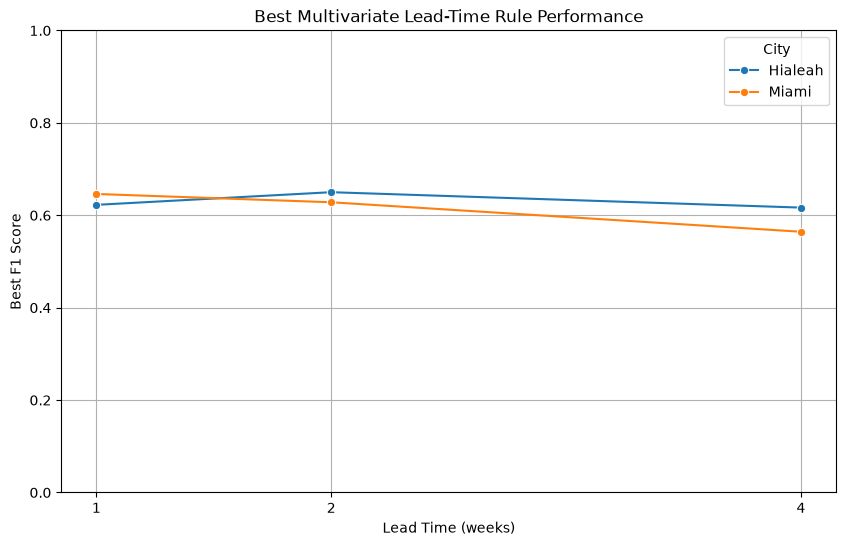

In [165]:
plt.figure(figsize=(10, 6))

sns.lineplot(
    data=best_lead_rule_by_city_horizon,
    x="Lead Time (weeks)",
    y="F1",
    hue="City",
    marker="o"
)

plt.title("Best Multivariate Lead-Time Rule Performance")
plt.xlabel("Lead Time (weeks)")
plt.ylabel("Best F1 Score")
plt.xticks(lead_horizons)
plt.ylim(0, 1)
plt.show()

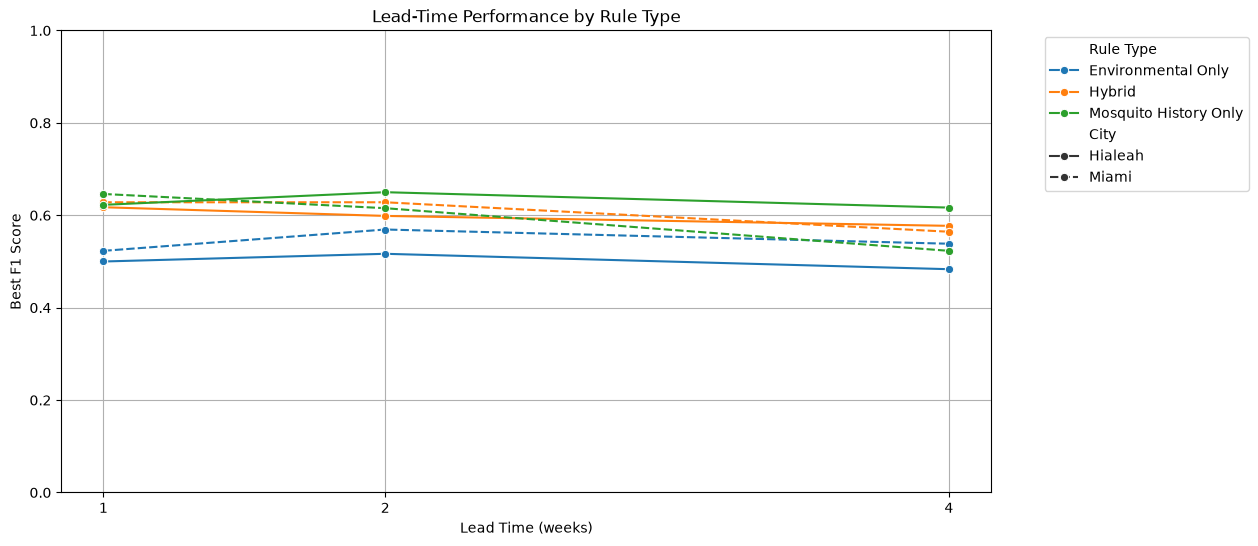

In [166]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=best_lead_rule_by_type,
    x="Lead Time (weeks)",
    y="F1",
    hue="Rule Type",
    style="City",
    marker="o"
)

plt.title("Lead-Time Performance by Rule Type")
plt.xlabel("Lead Time (weeks)")
plt.ylabel("Best F1 Score")
plt.xticks(lead_horizons)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

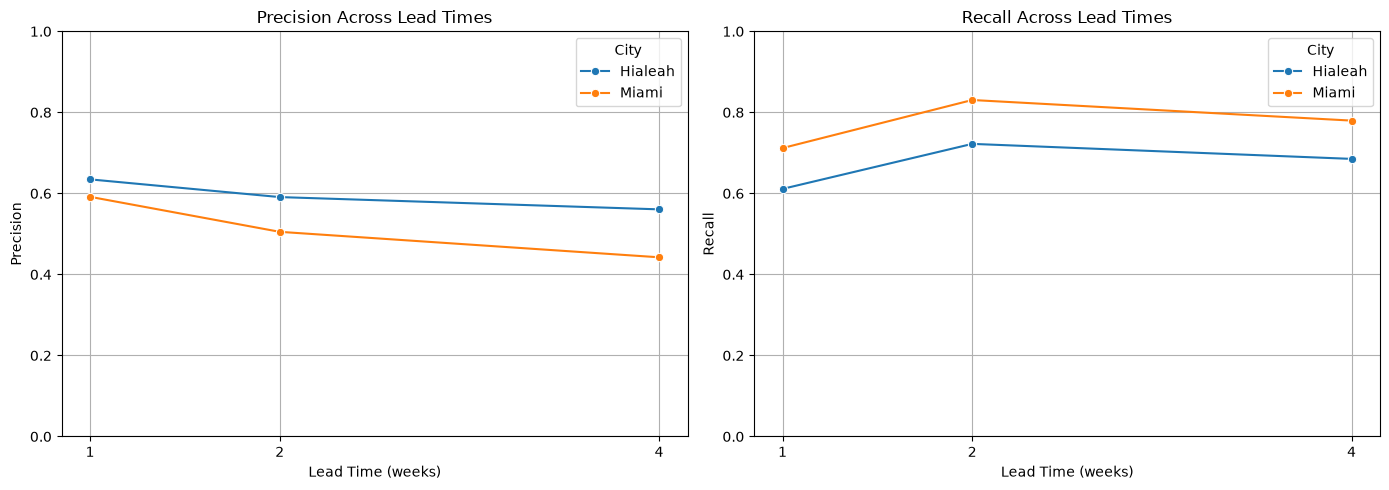

In [167]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.lineplot(
    data=best_lead_rule_by_city_horizon,
    x="Lead Time (weeks)",
    y="Precision",
    hue="City",
    marker="o",
    ax=axes[0]
)

axes[0].set_title("Precision Across Lead Times")
axes[0].set_ylim(0, 1)
axes[0].set_xticks(lead_horizons)

sns.lineplot(
    data=best_lead_rule_by_city_horizon,
    x="Lead Time (weeks)",
    y="Recall",
    hue="City",
    marker="o",
    ax=axes[1]
)

axes[1].set_title("Recall Across Lead Times")
axes[1].set_ylim(0, 1)
axes[1].set_xticks(lead_horizons)

plt.tight_layout()
plt.show()

In [168]:
environmental_lead_results = combined_lead_rule_results_multi[
    combined_lead_rule_results_multi["Rule Type"] == "Environmental Only"
].copy()

best_environmental_lead_results = (
    environmental_lead_results
    .sort_values(["City", "Lead Time (weeks)", "F1"], ascending=[True, True, False])
    .groupby(["City", "Lead Time (weeks)"])
    .head(1)
    .reset_index(drop=True)
)

best_environmental_lead_results

,City,Lead Time (weeks),Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Hialeah,1,Environmental Only,Mean_Temperature-5 Low,0.770992,0.454545,0.555556,0.500000,66,54
1,Hialeah,2,Environmental Only,Mean_Temperature-5 Low,0.778626,0.469697,0.574074,0.516667,66,54
2,Hialeah,4,Environmental Only,Max_Temperature-3 Low,0.763359,0.439394,0.537037,0.483333,66,54
3,Miami,1,Environmental Only,Mean_Temperature-5 Low,0.780919,0.478873,0.576271,0.523077,71,59
4,Miami,2,Environmental Only,Min_Temperature-5 Low,0.802120,0.521127,0.627119,0.569231,71,59
5,Miami,4,Environmental Only,Mean_Temperature-5 Low,0.787986,0.492958,0.593220,0.538462,71,59


In [169]:
hybrid_lead_results = combined_lead_rule_results_multi[
    combined_lead_rule_results_multi["Rule Type"] == "Hybrid"
].copy()

best_hybrid_lead_results = (
    hybrid_lead_results
    .sort_values(["City", "Lead Time (weeks)", "F1"], ascending=[True, True, False])
    .groupby(["City", "Lead Time (weeks)"])
    .head(1)
    .reset_index(drop=True)
)

best_hybrid_lead_results

,City,Lead Time (weeks),Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Hialeah,1,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.782443,0.484211,0.851852,0.617450,95,54
1,Hialeah,2,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.774809,0.473118,0.814815,0.598639,93,54
2,Hialeah,4,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.759542,0.452632,0.796296,0.577181,95,54
3,Miami,1,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.795053,0.505155,0.830508,0.628205,97,59
4,Miami,2,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.795053,0.505155,0.830508,0.628205,97,59
5,Miami,4,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.749117,0.442308,0.779661,0.564417,104,59


In [170]:
mosq_history_lead_results = combined_lead_rule_results_multi[
    combined_lead_rule_results_multi["Rule Type"] == "Mosquito History Only"
].copy()

best_mosq_history_lead_results = (
    mosq_history_lead_results
    .sort_values(["City", "Lead Time (weeks)", "F1"], ascending=[True, True, False])
    .groupby(["City", "Lead Time (weeks)"])
    .head(1)
    .reset_index(drop=True)
)

best_mosq_history_lead_results

,City,Lead Time (weeks),Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Hialeah,1,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.847328,0.634615,0.611111,0.622642,52,54
1,Hialeah,2,Mosquito History Only,Mosq Rolling Mean 4 High,0.839695,0.590909,0.722222,0.650000,66,54
2,Hialeah,4,Mosquito History Only,Mosq Lag 1 High,0.824427,0.560606,0.685185,0.616667,66,54
3,Miami,1,Mosquito History Only,Mosq Rolling Mean 2 High,0.837456,0.591549,0.711864,0.646154,71,59
4,Miami,2,Mosquito History Only,Mosq Lag 1 High,0.823322,0.563380,0.677966,0.615385,71,59
5,Miami,4,Mosquito History Only,Mosq Rolling Mean 2 High,0.780919,0.478873,0.576271,0.523077,71,59


In [171]:
rule_type_comparison = pd.concat([
    best_environmental_lead_results,
    best_mosq_history_lead_results,
    best_hybrid_lead_results
]).reset_index(drop=True)

rule_type_comparison = rule_type_comparison.sort_values(
    ["City", "Lead Time (weeks)", "Rule Type"]
).reset_index(drop=True)

rule_type_comparison

,City,Lead Time (weeks),Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Hialeah,1,Environmental Only,Mean_Temperature-5 Low,0.770992,0.454545,0.555556,0.500000,66,54
1,Hialeah,1,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.782443,0.484211,0.851852,0.617450,95,54
2,Hialeah,1,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.847328,0.634615,0.611111,0.622642,52,54
3,Hialeah,2,Environmental Only,Mean_Temperature-5 Low,0.778626,0.469697,0.574074,0.516667,66,54
4,Hialeah,2,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.774809,0.473118,0.814815,0.598639,93,54
5,Hialeah,2,Mosquito History Only,Mosq Rolling Mean 4 High,0.839695,0.590909,0.722222,0.650000,66,54
6,Hialeah,4,Environmental Only,Max_Temperature-3 Low,0.763359,0.439394,0.537037,0.483333,66,54
7,Hialeah,4,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.759542,0.452632,0.796296,0.577181,95,54
8,Hialeah,4,Mosquito History Only,Mosq Lag 1 High,0.824427,0.560606,0.685185,0.616667,66,54
9,Miami,1,Environmental Only,Mean_Temperature-5 Low,0.780919,0.478873,0.576271,0.523077,71,59


In [172]:
rule_type_comparison.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}"
})

,City,Lead Time (weeks),Rule Type,Rule,Accuracy,Precision,Recall,F1,Predicted Outbreak Weeks,Actual Future Outbreak Weeks
0,Hialeah,1,Environmental Only,Mean_Temperature-5 Low,0.771,0.455,0.556,0.500,66,54
1,Hialeah,1,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR Max_Temperature-3 Low,0.782,0.484,0.852,0.617,95,54
2,Hialeah,1,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.847,0.635,0.611,0.623,52,54
3,Hialeah,2,Environmental Only,Mean_Temperature-5 Low,0.779,0.470,0.574,0.517,66,54
4,Hialeah,2,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR Mean_Humidity Low,0.775,0.473,0.815,0.599,93,54
5,Hialeah,2,Mosquito History Only,Mosq Rolling Mean 4 High,0.840,0.591,0.722,0.650,66,54
6,Hialeah,4,Environmental Only,Max_Temperature-3 Low,0.763,0.439,0.537,0.483,66,54
7,Hialeah,4,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR Max_Temperature-3 Low,0.760,0.453,0.796,0.577,95,54
8,Hialeah,4,Mosquito History Only,Mosq Lag 1 High,0.824,0.561,0.685,0.617,66,54
9,Miami,1,Environmental Only,Mean_Temperature-5 Low,0.781,0.479,0.576,0.523,71,59


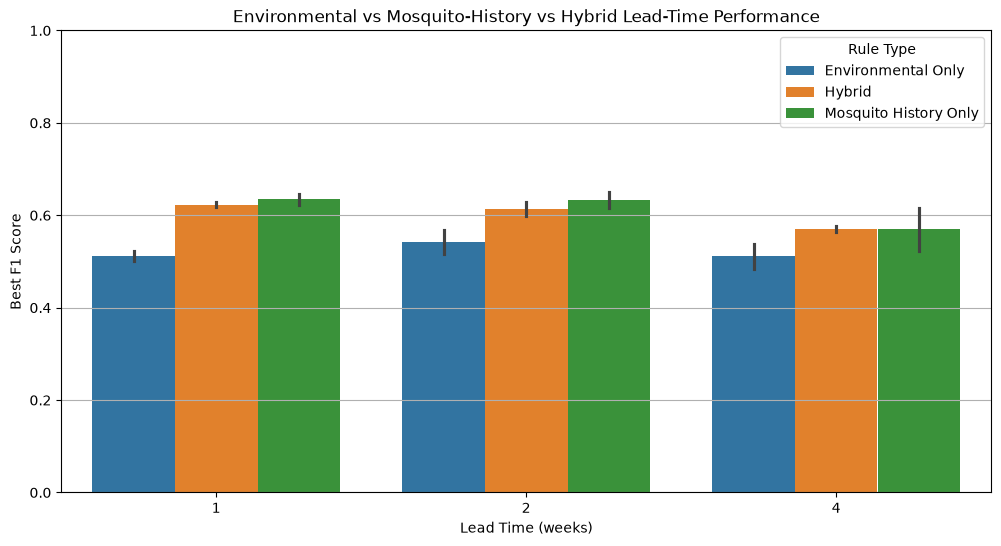

In [173]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=rule_type_comparison,
    x="Lead Time (weeks)",
    y="F1",
    hue="Rule Type"
)

plt.title("Environmental vs Mosquito-History vs Hybrid Lead-Time Performance")
plt.xlabel("Lead Time (weeks)")
plt.ylabel("Best F1 Score")
plt.ylim(0, 1)
plt.legend(title="Rule Type")
plt.show()

In [174]:
combined_lead_rule_results_multi.to_csv(
    "multivariate_lead_time_rule_results_all.csv",
    index=False
)

best_lead_rule_by_city_horizon.to_csv(
    "multivariate_best_lead_rule_by_city_horizon.csv",
    index=False
)

rule_type_comparison.to_csv(
    "multivariate_rule_type_lead_time_comparison.csv",
    index=False
)

In [175]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report

def get_feature_sets_for_city(city_name):
    if city_name == "Miami":
        clean_env_features = miami_clean_env_features
    elif city_name == "Hialeah":
        clean_env_features = hialeah_clean_env_features
    else:
        raise ValueError("city_name must be 'Miami' or 'Hialeah'")

    feature_sets = {
        "Environmental Only": clean_env_features,
        "Mosquito History Only": MOSQ_HISTORY_COLS,
        "Hybrid": list(dict.fromkeys(clean_env_features + MOSQ_HISTORY_COLS))
    }

    return feature_sets


def evaluate_lead_time_models(
    df,
    city_name,
    horizons=[1, 2, 4],
    train_frac=0.80
):
    """
    Fits Logistic Regression and Random Forest classifiers for
    future outbreak prediction at multiple lead times.
    """

    feature_sets = get_feature_sets_for_city(city_name)

    model_specs = {
        "Logistic Regression": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ))
        ]),

        "Random Forest": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=300,
                max_depth=4,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=RANDOM_STATE
            ))
        ])
    }

    results = []
    fitted_models = {}

    for h in horizons:
        target_col = f"outbreak_{h}wk_ahead"

        model_df = df.dropna(subset=[target_col]).copy()
        train_df, test_df = time_train_test_split(model_df, train_frac=train_frac)

        y_train = train_df[target_col].astype(int)
        y_test = test_df[target_col].astype(int)

        for feature_set_name, feature_cols in feature_sets.items():
            feature_cols = [col for col in feature_cols if col in model_df.columns]

            X_train = train_df[feature_cols]
            X_test = test_df[feature_cols]

            for model_name, model in model_specs.items():
                model.fit(X_train, y_train)

                y_pred = model.predict(X_test)

                metrics = compute_classification_metrics(y_test, y_pred)

                results.append({
                    "City": city_name,
                    "Lead Time (weeks)": h,
                    "Feature Set": feature_set_name,
                    "Model": model_name,
                    "Accuracy": metrics["Accuracy"],
                    "Precision": metrics["Precision"],
                    "Recall": metrics["Recall"],
                    "F1": metrics["F1"],
                    "Test Outbreak Weeks": int(y_test.sum()),
                    "Predicted Outbreak Weeks": int(y_pred.sum()),
                    "Number of Features": len(feature_cols)
                })

                fitted_models[(city_name, h, feature_set_name, model_name)] = {
                    "model": model,
                    "features": feature_cols,
                    "X_test": X_test,
                    "y_test": y_test,
                    "y_pred": y_pred
                }

    results_df = pd.DataFrame(results).sort_values(
        ["City", "Lead Time (weeks)", "F1"],
        ascending=[True, True, False]
    ).reset_index(drop=True)

    return results_df, fitted_models

In [176]:
miami_lead_model_results, miami_lead_models = evaluate_lead_time_models(
    miami_lead_multi,
    city_name="Miami",
    horizons=lead_horizons
)

hialeah_lead_model_results, hialeah_lead_models = evaluate_lead_time_models(
    hialeah_lead_multi,
    city_name="Hialeah",
    horizons=lead_horizons
)

combined_lead_model_results = pd.concat([
    miami_lead_model_results,
    hialeah_lead_model_results
]).reset_index(drop=True)

combined_lead_model_results

,City,Lead Time (weeks),Feature Set,Model,Accuracy,Precision,Recall,F1,Test Outbreak Weeks,Predicted Outbreak Weeks,Number of Features
0,Miami,1,Hybrid,Random Forest,0.894737,0.739130,1.000000,0.850000,17,23,23
1,Miami,1,Hybrid,Logistic Regression,0.842105,0.681818,0.882353,0.769231,17,22,23
2,Miami,1,Mosquito History Only,Random Forest,0.807018,0.615385,0.941176,0.744186,17,26,7
3,Miami,1,Mosquito History Only,Logistic Regression,0.789474,0.600000,0.882353,0.714286,17,25,7
4,Miami,1,Environmental Only,Logistic Regression,0.824561,0.733333,0.647059,0.687500,17,15,16
5,Miami,1,Environmental Only,Random Forest,0.789474,0.631579,0.705882,0.666667,17,19,16
6,Miami,2,Hybrid,Random Forest,0.894737,0.789474,0.882353,0.833333,17,19,23
7,Miami,2,Environmental Only,Random Forest,0.859649,0.736842,0.823529,0.777778,17,19,16
8,Miami,2,Hybrid,Logistic Regression,0.859649,0.736842,0.823529,0.777778,17,19,23
9,Miami,2,Mosquito History Only,Random Forest,0.789474,0.600000,0.882353,0.714286,17,25,7


In [177]:
combined_lead_model_results.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}"
})

,City,Lead Time (weeks),Feature Set,Model,Accuracy,Precision,Recall,F1,Test Outbreak Weeks,Predicted Outbreak Weeks,Number of Features
0,Miami,1,Hybrid,Random Forest,0.895,0.739,1.000,0.850,17,23,23
1,Miami,1,Hybrid,Logistic Regression,0.842,0.682,0.882,0.769,17,22,23
2,Miami,1,Mosquito History Only,Random Forest,0.807,0.615,0.941,0.744,17,26,7
3,Miami,1,Mosquito History Only,Logistic Regression,0.789,0.600,0.882,0.714,17,25,7
4,Miami,1,Environmental Only,Logistic Regression,0.825,0.733,0.647,0.688,17,15,16
5,Miami,1,Environmental Only,Random Forest,0.789,0.632,0.706,0.667,17,19,16
6,Miami,2,Hybrid,Random Forest,0.895,0.789,0.882,0.833,17,19,23
7,Miami,2,Environmental Only,Random Forest,0.860,0.737,0.824,0.778,17,19,16
8,Miami,2,Hybrid,Logistic Regression,0.860,0.737,0.824,0.778,17,19,23
9,Miami,2,Mosquito History Only,Random Forest,0.789,0.600,0.882,0.714,17,25,7


In [178]:
best_lead_model_by_city_horizon = (
    combined_lead_model_results
    .sort_values(["City", "Lead Time (weeks)", "F1"], ascending=[True, True, False])
    .groupby(["City", "Lead Time (weeks)"])
    .head(1)
    .reset_index(drop=True)
)

best_lead_model_by_city_horizon

,City,Lead Time (weeks),Feature Set,Model,Accuracy,Precision,Recall,F1,Test Outbreak Weeks,Predicted Outbreak Weeks,Number of Features
0,Hialeah,1,Hybrid,Random Forest,0.886792,0.863636,0.863636,0.863636,22,22,23
1,Hialeah,2,Hybrid,Random Forest,0.867925,0.777778,0.954545,0.857143,22,27,23
2,Hialeah,4,Mosquito History Only,Random Forest,0.811321,0.700000,0.954545,0.807692,22,30,7
3,Miami,1,Hybrid,Random Forest,0.894737,0.739130,1.000000,0.850000,17,23,23
4,Miami,2,Hybrid,Random Forest,0.894737,0.789474,0.882353,0.833333,17,19,23
5,Miami,4,Environmental Only,Logistic Regression,0.842105,0.722222,0.764706,0.742857,17,18,16


In [179]:
best_rule_summary = best_lead_rule_by_city_horizon.copy()
best_rule_summary["Approach"] = "Best Rule-Based"
best_rule_summary["Feature Set"] = best_rule_summary["Rule Type"]
best_rule_summary["Model/Rule"] = best_rule_summary["Rule"]

best_rule_summary = best_rule_summary[
    [
        "City",
        "Lead Time (weeks)",
        "Approach",
        "Feature Set",
        "Model/Rule",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
]

best_model_summary = best_lead_model_by_city_horizon.copy()
best_model_summary["Approach"] = "Best Model-Based"
best_model_summary["Model/Rule"] = (
    best_model_summary["Model"] + " (" + best_model_summary["Feature Set"] + ")"
)

best_model_summary = best_model_summary[
    [
        "City",
        "Lead Time (weeks)",
        "Approach",
        "Feature Set",
        "Model/Rule",
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ]
]

rule_vs_model_lead_comparison = pd.concat([
    best_rule_summary,
    best_model_summary
]).reset_index(drop=True)

rule_vs_model_lead_comparison = rule_vs_model_lead_comparison.sort_values(
    ["City", "Lead Time (weeks)", "Approach"]
).reset_index(drop=True)

rule_vs_model_lead_comparison

,City,Lead Time (weeks),Approach,Feature Set,Model/Rule,Accuracy,Precision,Recall,F1
0,Hialeah,1,Best Model-Based,Hybrid,Random Forest (Hybrid),0.886792,0.863636,0.863636,0.863636
1,Hialeah,1,Best Rule-Based,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.847328,0.634615,0.611111,0.622642
2,Hialeah,2,Best Model-Based,Hybrid,Random Forest (Hybrid),0.867925,0.777778,0.954545,0.857143
3,Hialeah,2,Best Rule-Based,Mosquito History Only,Mosq Rolling Mean 4 High,0.839695,0.590909,0.722222,0.650000
4,Hialeah,4,Best Model-Based,Mosquito History Only,Random Forest (Mosquito History Only),0.811321,0.700000,0.954545,0.807692
5,Hialeah,4,Best Rule-Based,Mosquito History Only,Mosq Lag 1 High,0.824427,0.560606,0.685185,0.616667
6,Miami,1,Best Model-Based,Hybrid,Random Forest (Hybrid),0.894737,0.739130,1.000000,0.850000
7,Miami,1,Best Rule-Based,Mosquito History Only,Mosq Rolling Mean 2 High,0.837456,0.591549,0.711864,0.646154
8,Miami,2,Best Model-Based,Hybrid,Random Forest (Hybrid),0.894737,0.789474,0.882353,0.833333
9,Miami,2,Best Rule-Based,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR...,0.795053,0.505155,0.830508,0.628205


In [180]:
rule_vs_model_lead_comparison.style.format({
    "Accuracy": "{:.3f}",
    "Precision": "{:.3f}",
    "Recall": "{:.3f}",
    "F1": "{:.3f}"
})

,City,Lead Time (weeks),Approach,Feature Set,Model/Rule,Accuracy,Precision,Recall,F1
0,Hialeah,1,Best Model-Based,Hybrid,Random Forest (Hybrid),0.887,0.864,0.864,0.864
1,Hialeah,1,Best Rule-Based,Mosquito History Only,Mosq Rolling Mean 2 AND Rolling Mean 4 High,0.847,0.635,0.611,0.623
2,Hialeah,2,Best Model-Based,Hybrid,Random Forest (Hybrid),0.868,0.778,0.955,0.857
3,Hialeah,2,Best Rule-Based,Mosquito History Only,Mosq Rolling Mean 4 High,0.840,0.591,0.722,0.650
4,Hialeah,4,Best Model-Based,Mosquito History Only,Random Forest (Mosquito History Only),0.811,0.700,0.955,0.808
5,Hialeah,4,Best Rule-Based,Mosquito History Only,Mosq Lag 1 High,0.824,0.561,0.685,0.617
6,Miami,1,Best Model-Based,Hybrid,Random Forest (Hybrid),0.895,0.739,1.000,0.850
7,Miami,1,Best Rule-Based,Mosquito History Only,Mosq Rolling Mean 2 High,0.837,0.592,0.712,0.646
8,Miami,2,Best Model-Based,Hybrid,Random Forest (Hybrid),0.895,0.789,0.882,0.833
9,Miami,2,Best Rule-Based,Hybrid,Mosq Rolling Mean 2 AND Rolling Mean 4 High OR Min_Temperature-5 Low,0.795,0.505,0.831,0.628


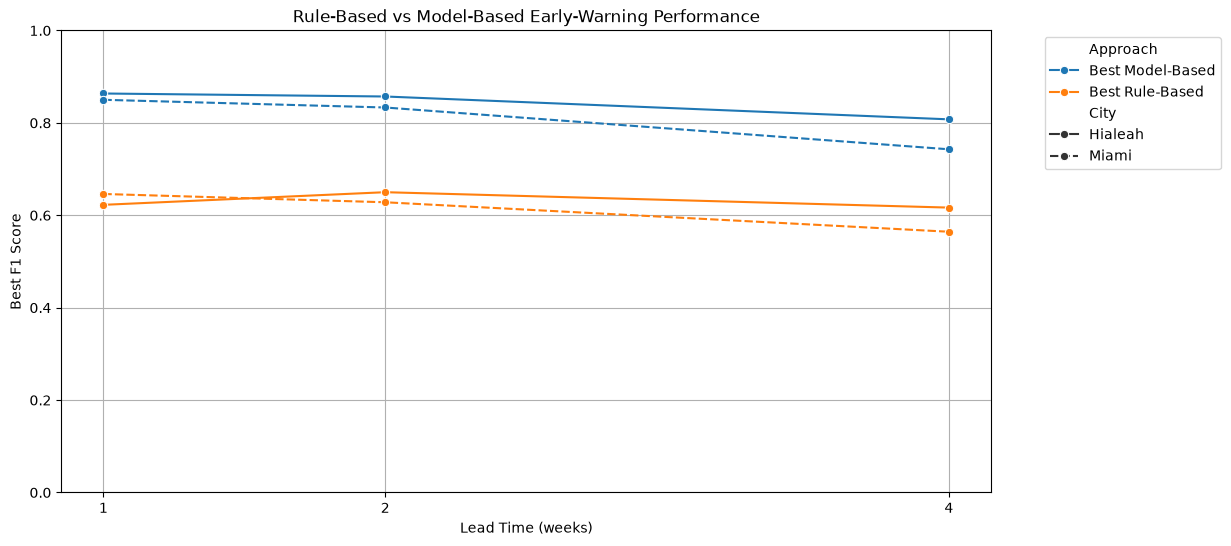

In [181]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=rule_vs_model_lead_comparison,
    x="Lead Time (weeks)",
    y="F1",
    hue="Approach",
    style="City",
    marker="o"
)

plt.title("Rule-Based vs Model-Based Early-Warning Performance")
plt.xlabel("Lead Time (weeks)")
plt.ylabel("Best F1 Score")
plt.xticks(lead_horizons)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [182]:
best_model_by_feature_set = (
    combined_lead_model_results
    .sort_values(
        ["City", "Lead Time (weeks)", "Feature Set", "F1"],
        ascending=[True, True, True, False]
    )
    .groupby(["City", "Lead Time (weeks)", "Feature Set"])
    .head(1)
    .reset_index(drop=True)
)

best_model_by_feature_set

,City,Lead Time (weeks),Feature Set,Model,Accuracy,Precision,Recall,F1,Test Outbreak Weeks,Predicted Outbreak Weeks,Number of Features
0,Hialeah,1,Environmental Only,Logistic Regression,0.584906,0.000000,0.000000,0.000000,22,0,16
1,Hialeah,1,Hybrid,Random Forest,0.886792,0.863636,0.863636,0.863636,22,22,23
2,Hialeah,1,Mosquito History Only,Random Forest,0.811321,0.700000,0.954545,0.807692,22,30,7
3,Hialeah,2,Environmental Only,Logistic Regression,0.584906,0.000000,0.000000,0.000000,22,0,16
4,Hialeah,2,Hybrid,Random Forest,0.867925,0.777778,0.954545,0.857143,22,27,23
5,Hialeah,2,Mosquito History Only,Logistic Regression,0.792453,0.677419,0.954545,0.792453,22,31,7
6,Hialeah,4,Environmental Only,Logistic Regression,0.584906,0.000000,0.000000,0.000000,22,0,16
7,Hialeah,4,Hybrid,Random Forest,0.811321,0.750000,0.818182,0.782609,22,24,23
8,Hialeah,4,Mosquito History Only,Random Forest,0.811321,0.700000,0.954545,0.807692,22,30,7
9,Miami,1,Environmental Only,Logistic Regression,0.824561,0.733333,0.647059,0.687500,17,15,16


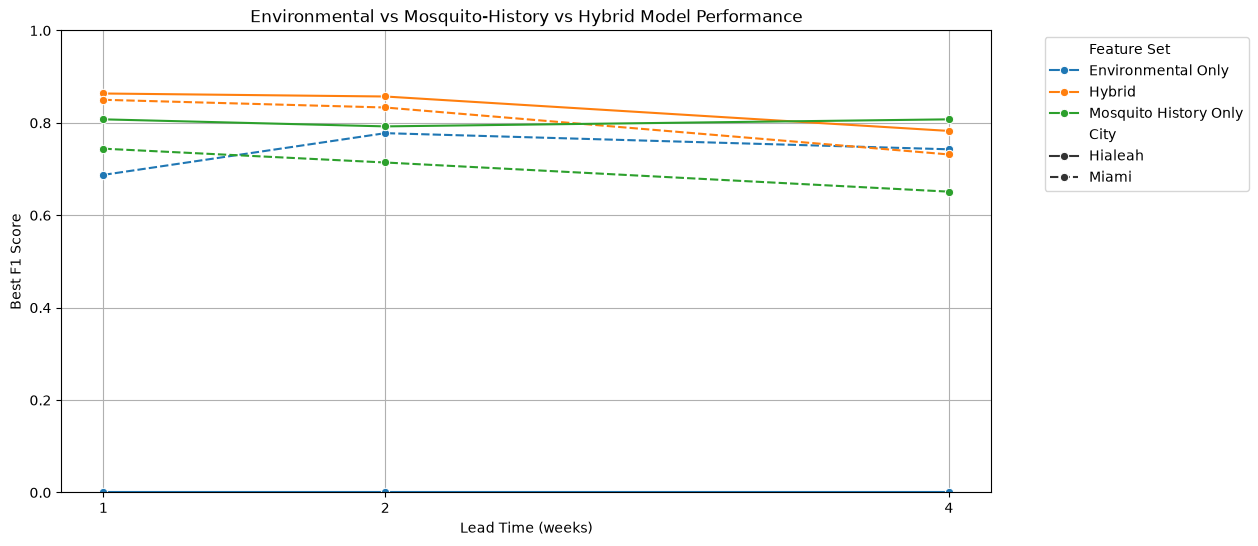

In [183]:
plt.figure(figsize=(12, 6))

sns.lineplot(
    data=best_model_by_feature_set,
    x="Lead Time (weeks)",
    y="F1",
    hue="Feature Set",
    style="City",
    marker="o"
)

plt.title("Environmental vs Mosquito-History vs Hybrid Model Performance")
plt.xlabel("Lead Time (weeks)")
plt.ylabel("Best F1 Score")
plt.xticks(lead_horizons)
plt.ylim(0, 1)
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.show()

In [184]:
combined_lead_model_results.to_csv(
    "multivariate_lead_time_model_results_all.csv",
    index=False
)

best_lead_model_by_city_horizon.to_csv(
    "multivariate_best_lead_model_by_city_horizon.csv",
    index=False
)

rule_vs_model_lead_comparison.to_csv(
    "multivariate_rule_vs_model_lead_time_comparison.csv",
    index=False
)

best_model_by_feature_set.to_csv(
    "multivariate_best_model_by_feature_set_lead_time.csv",
    index=False
)

In [185]:
def summarize_city_drivers(city_name):
    if city_name == "Miami":
        top_env = top_environmental_drivers[
            top_environmental_drivers["City"] == "Miami"
        ].copy()

        representative = best_family_features_combined[
            best_family_features_combined["City"] == "Miami"
        ].copy()

        best_rule = best_overall_rule_by_city[
            best_overall_rule_by_city["City"] == "Miami"
        ].copy()

        best_lead_rule = best_lead_rule_by_city_horizon[
            best_lead_rule_by_city_horizon["City"] == "Miami"
        ].copy()

        best_lead_model = best_lead_model_by_city_horizon[
            best_lead_model_by_city_horizon["City"] == "Miami"
        ].copy()

    elif city_name == "Hialeah":
        top_env = top_environmental_drivers[
            top_environmental_drivers["City"] == "Hialeah"
        ].copy()

        representative = best_family_features_combined[
            best_family_features_combined["City"] == "Hialeah"
        ].copy()

        best_rule = best_overall_rule_by_city[
            best_overall_rule_by_city["City"] == "Hialeah"
        ].copy()

        best_lead_rule = best_lead_rule_by_city_horizon[
            best_lead_rule_by_city_horizon["City"] == "Hialeah"
        ].copy()

        best_lead_model = best_lead_model_by_city_horizon[
            best_lead_model_by_city_horizon["City"] == "Hialeah"
        ].copy()

    strongest_env_variable = top_env.iloc[0]["Variable"]
    strongest_env_corr = top_env.iloc[0]["Correlation"]

    best_static_or_context = representative[
        representative["Environmental Family"].isin([
            "Precipitation",
            "Mean Humidity",
            "Maximum Humidity",
            "Minimum Humidity",
            "Mean Temperature",
            "Maximum Temperature",
            "Minimum Temperature"
        ])
    ]

    summary = {
        "City": city_name,
        "Strongest Environmental Variable": strongest_env_variable,
        "Strongest Environmental Correlation": strongest_env_corr,
        "Best Overall Rule": best_rule.iloc[0]["Rule"],
        "Best Overall Rule Type": best_rule.iloc[0]["Rule Type"],
        "Best Overall Rule F1": best_rule.iloc[0]["F1"],
        "Best 1-Week Rule F1": best_lead_rule[best_lead_rule["Lead Time (weeks)"] == 1]["F1"].iloc[0],
        "Best 2-Week Rule F1": best_lead_rule[best_lead_rule["Lead Time (weeks)"] == 2]["F1"].iloc[0],
        "Best 4-Week Rule F1": best_lead_rule[best_lead_rule["Lead Time (weeks)"] == 4]["F1"].iloc[0],
        "Best 1-Week Model F1": best_lead_model[best_lead_model["Lead Time (weeks)"] == 1]["F1"].iloc[0],
        "Best 2-Week Model F1": best_lead_model[best_lead_model["Lead Time (weeks)"] == 2]["F1"].iloc[0],
        "Best 4-Week Model F1": best_lead_model[best_lead_model["Lead Time (weeks)"] == 4]["F1"].iloc[0],
    }

    return summary

In [186]:
city_heterogeneity_summary = pd.DataFrame([
    summarize_city_drivers("Miami"),
    summarize_city_drivers("Hialeah")
])

city_heterogeneity_summary

,City,Strongest Environmental Variable,Strongest Environmental Correlation,Best Overall Rule,Best Overall Rule Type,Best Overall Rule F1,Best 1-Week Rule F1,Best 2-Week Rule F1,Best 4-Week Rule F1,Best 1-Week Model F1,Best 2-Week Model F1,Best 4-Week Model F1
0,Miami,Mean_Temperature-5,-0.601552,Mosq Rolling Mean 2 High,Mosquito History Only,0.671756,0.646154,0.628205,0.564417,0.850000,0.833333,0.742857
1,Hialeah,Mean_Temperature-5,-0.470313,Mosq Rolling Mean 2 AND Rolling Mean 4 High,Mosquito History Only,0.654206,0.622642,0.650000,0.616667,0.863636,0.857143,0.807692


In [187]:
city_heterogeneity_summary.style.format({
    "Strongest Environmental Correlation": "{:.3f}",
    "Best Overall Rule F1": "{:.3f}",
    "Best 1-Week Rule F1": "{:.3f}",
    "Best 2-Week Rule F1": "{:.3f}",
    "Best 4-Week Rule F1": "{:.3f}",
    "Best 1-Week Model F1": "{:.3f}",
    "Best 2-Week Model F1": "{:.3f}",
    "Best 4-Week Model F1": "{:.3f}"
})

,City,Strongest Environmental Variable,Strongest Environmental Correlation,Best Overall Rule,Best Overall Rule Type,Best Overall Rule F1,Best 1-Week Rule F1,Best 2-Week Rule F1,Best 4-Week Rule F1,Best 1-Week Model F1,Best 2-Week Model F1,Best 4-Week Model F1
0,Miami,Mean_Temperature-5,-0.602,Mosq Rolling Mean 2 High,Mosquito History Only,0.672,0.646,0.628,0.564,0.850,0.833,0.743
1,Hialeah,Mean_Temperature-5,-0.470,Mosq Rolling Mean 2 AND Rolling Mean 4 High,Mosquito History Only,0.654,0.623,0.650,0.617,0.864,0.857,0.808


In [188]:
representative_driver_comparison = best_family_features_combined.pivot_table(
    index="Environmental Family",
    columns="City",
    values="Variable",
    aggfunc="first"
)

representative_driver_comparison

City,Hialeah,Miami
Environmental Family,,
Maximum Humidity,Maximum_Humidity,Max_Humidity-1
Maximum Temperature,Max_Temperature-3,Max_Temperature-4
Mean Humidity,Mean_Humidity,Mean_Humidity-1
Mean Temperature,Mean_Temperature-5,Mean_Temperature-5
Minimum Humidity,Minimum_Humidity,Minimum_Humidity
Minimum Temperature,Min_Temperature-5,Min_Temperature-5
Precipitation,Mean_Precipitation,Mean_Precipitation-1


In [189]:
driver_strength_comparison = best_family_features_combined.pivot_table(
    index="Environmental Family",
    columns="City",
    values="Abs Correlation"
)

driver_strength_comparison

City,Hialeah,Miami
Environmental Family,,
Maximum Humidity,0.161186,0.123883
Maximum Temperature,0.390183,0.491071
Mean Humidity,0.377161,0.400157
Mean Temperature,0.470313,0.601552
Minimum Humidity,0.371511,0.472180
Minimum Temperature,0.452913,0.592995
Precipitation,0.249275,0.292299


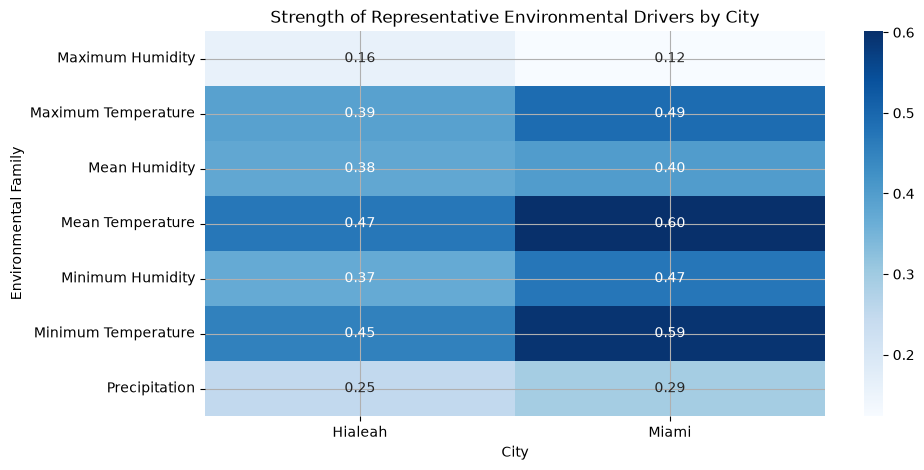

In [190]:
plt.figure(figsize=(10, 5))

sns.heatmap(
    driver_strength_comparison,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Strength of Representative Environmental Drivers by City")
plt.xlabel("City")
plt.ylabel("Environmental Family")
plt.show()

In [191]:
best_model_type_summary = best_lead_model_by_city_horizon[
    [
        "City",
        "Lead Time (weeks)",
        "Feature Set",
        "Model",
        "F1",
        "Precision",
        "Recall"
    ]
].copy()

best_model_type_summary

,City,Lead Time (weeks),Feature Set,Model,F1,Precision,Recall
0,Hialeah,1,Hybrid,Random Forest,0.863636,0.863636,0.863636
1,Hialeah,2,Hybrid,Random Forest,0.857143,0.777778,0.954545
2,Hialeah,4,Mosquito History Only,Random Forest,0.807692,0.700000,0.954545
3,Miami,1,Hybrid,Random Forest,0.850000,0.739130,1.000000
4,Miami,2,Hybrid,Random Forest,0.833333,0.789474,0.882353
5,Miami,4,Environmental Only,Logistic Regression,0.742857,0.722222,0.764706


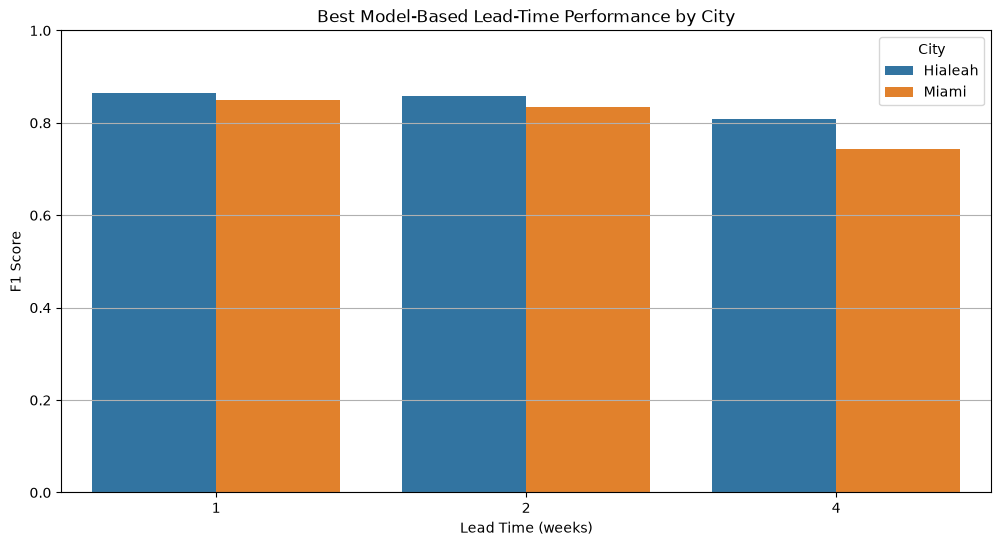

In [192]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=best_model_type_summary,
    x="Lead Time (weeks)",
    y="F1",
    hue="City"
)

plt.title("Best Model-Based Lead-Time Performance by City")
plt.xlabel("Lead Time (weeks)")
plt.ylabel("F1 Score")
plt.ylim(0, 1)
plt.legend(title="City")
plt.show()

In [193]:
def extract_random_forest_importance(fitted_models, city_name):

    rows = []

    for h in lead_horizons:
        key = (city_name, h, "Hybrid", "Random Forest")

        if key not in fitted_models:
            continue

        model_info = fitted_models[key]
        pipeline = model_info["model"]
        feature_cols = model_info["features"]

        rf_model = pipeline.named_steps["model"]

        importances = rf_model.feature_importances_

        for feature, importance in zip(feature_cols, importances):
            rows.append({
                "City": city_name,
                "Lead Time (weeks)": h,
                "Feature": feature,
                "Importance": importance
            })

    importance_df = pd.DataFrame(rows)

    if len(importance_df) > 0:
        importance_df = importance_df.sort_values(
            ["City", "Lead Time (weeks)", "Importance"],
            ascending=[True, True, False]
        ).reset_index(drop=True)

    return importance_df

In [194]:
miami_rf_importance = extract_random_forest_importance(
    miami_lead_models,
    city_name="Miami"
)

hialeah_rf_importance = extract_random_forest_importance(
    hialeah_lead_models,
    city_name="Hialeah"
)

combined_rf_importance = pd.concat([
    miami_rf_importance,
    hialeah_rf_importance
]).reset_index(drop=True)

combined_rf_importance.head(20)

,City,Lead Time (weeks),Feature,Importance
0,Miami,1,Mean_Temperature-5,0.129224
1,Miami,1,Max_Temperature-4,0.117766
2,Miami,1,mosq_roll_mean_2,0.087809
3,Miami,1,mosq_lag_1,0.078069
4,Miami,1,mosq_roll_mean_4,0.077586
5,Miami,1,Min_Temperature-5,0.072189
6,Miami,1,mosq_lag_4,0.066038
7,Miami,1,NDVI,0.050274
8,Miami,1,Mean_Precipitation-1,0.048217
9,Miami,1,WATER_BODY,0.045374


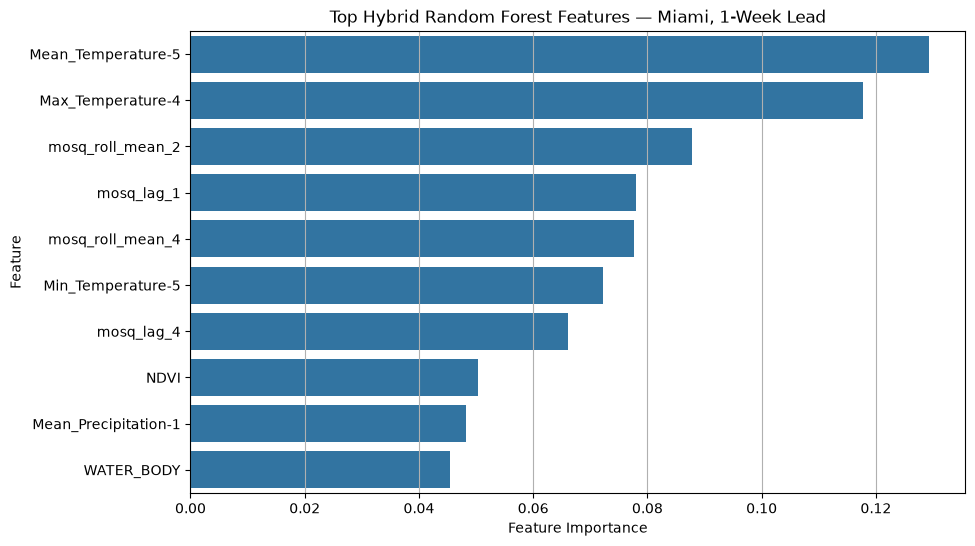

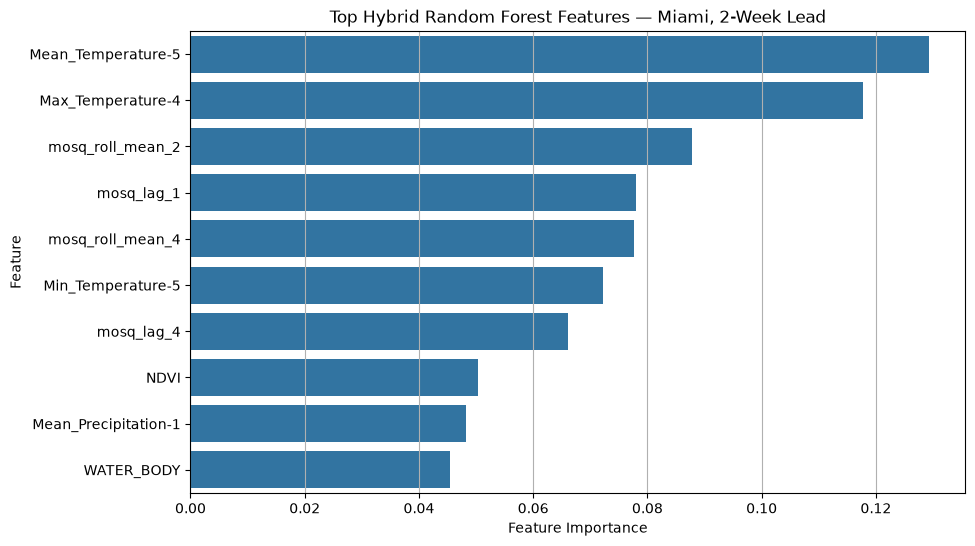

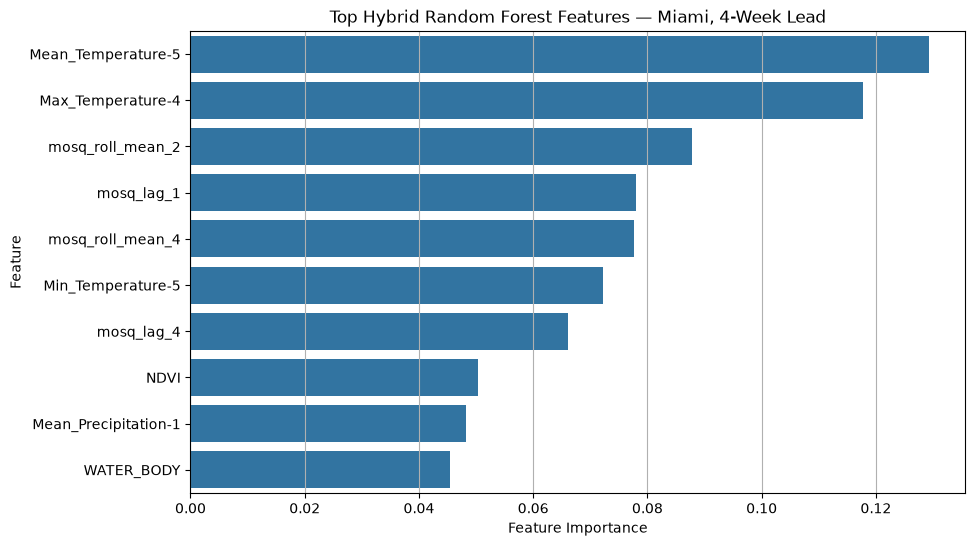

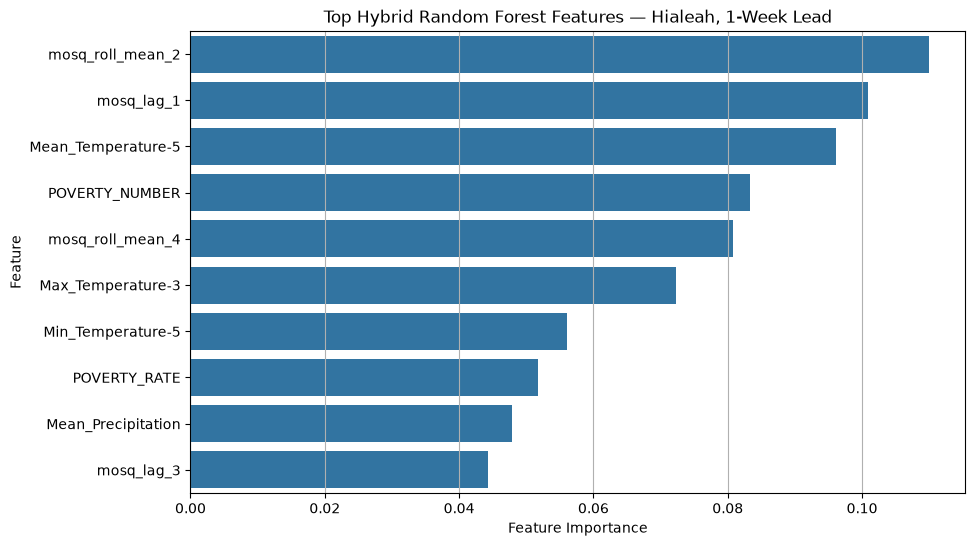

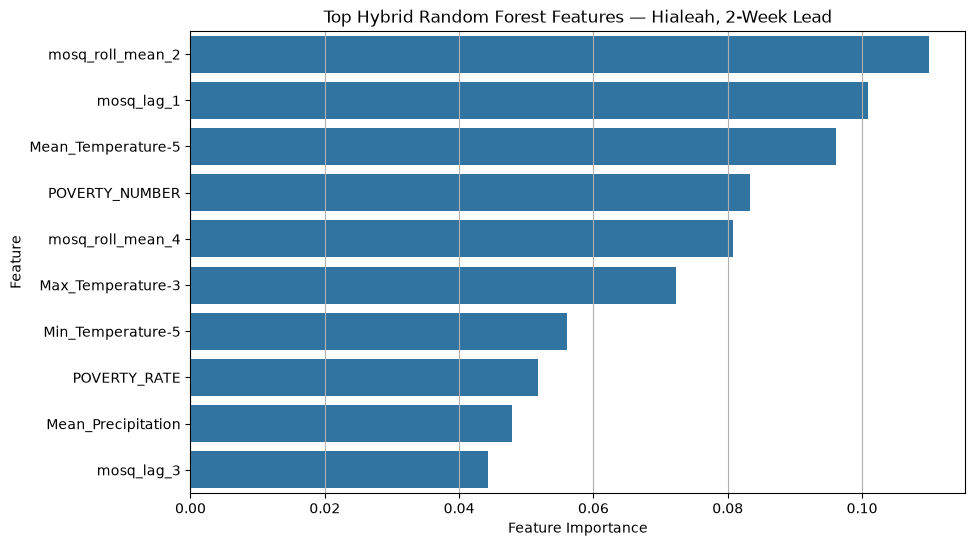

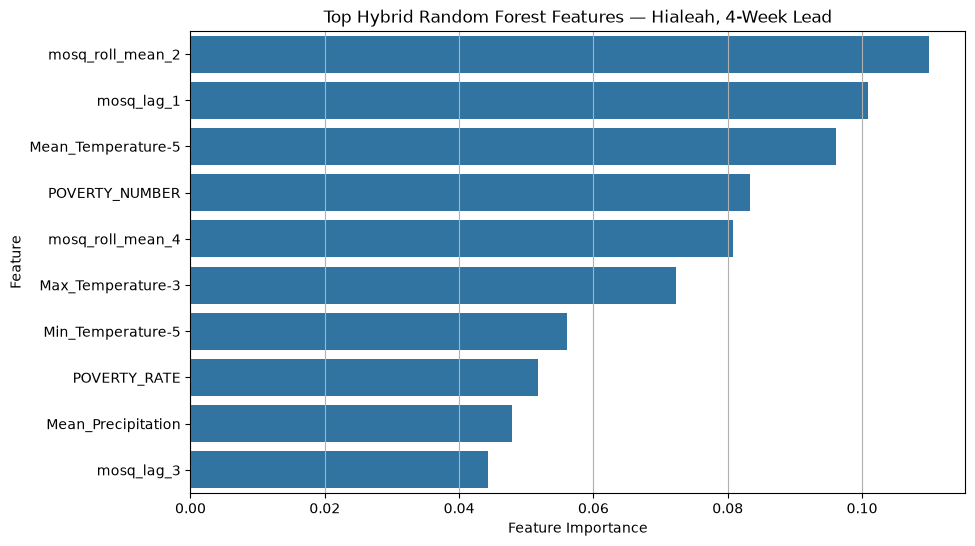

In [195]:
def plot_top_rf_importance(importance_df, city_name, horizon, top_n=10):
    plot_df = (
        importance_df[
            (importance_df["City"] == city_name) &
            (importance_df["Lead Time (weeks)"] == horizon)
        ]
        .sort_values("Importance", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=plot_df,
        x="Importance",
        y="Feature"
    )

    plt.title(f"Top Hybrid Random Forest Features — {city_name}, {horizon}-Week Lead")
    plt.xlabel("Feature Importance")
    plt.ylabel("Feature")
    plt.show()


for city in ["Miami", "Hialeah"]:
    for h in lead_horizons:
        plot_top_rf_importance(
            combined_rf_importance,
            city_name=city,
            horizon=h,
            top_n=10
        )

In [196]:
top_rf_features_by_city_horizon = (
    combined_rf_importance
    .sort_values(["City", "Lead Time (weeks)", "Importance"], ascending=[True, True, False])
    .groupby(["City", "Lead Time (weeks)"])
    .head(10)
    .reset_index(drop=True)
)

top_rf_features_by_city_horizon

,City,Lead Time (weeks),Feature,Importance
0,Hialeah,1,mosq_roll_mean_2,0.109904
1,Hialeah,1,mosq_lag_1,0.100812
2,Hialeah,1,Mean_Temperature-5,0.096156
3,Hialeah,1,POVERTY_NUMBER,0.083379
4,Hialeah,1,mosq_roll_mean_4,0.080850
5,Hialeah,1,Max_Temperature-3,0.072257
6,Hialeah,1,Min_Temperature-5,0.056023
7,Hialeah,1,POVERTY_RATE,0.051674
8,Hialeah,1,Mean_Precipitation,0.047875
9,Hialeah,1,mosq_lag_3,0.044269


In [197]:
city_heterogeneity_summary.to_csv(
    "multivariate_city_heterogeneity_summary.csv",
    index=False
)

representative_driver_comparison.to_csv(
    "multivariate_representative_driver_comparison.csv"
)

driver_strength_comparison.to_csv(
    "multivariate_driver_strength_comparison.csv"
)

best_model_type_summary.to_csv(
    "multivariate_best_model_type_by_city_lead_time.csv",
    index=False
)

combined_rf_importance.to_csv(
    "multivariate_random_forest_feature_importance_all.csv",
    index=False
)

top_rf_features_by_city_horizon.to_csv(
    "multivariate_top_random_forest_features_by_city_horizon.csv",
    index=False
)

In [198]:
print("Saved RQ6 and RQ7 output files:")
print("1. multivariate_lead_time_model_results_all.csv")
print("2. multivariate_best_lead_model_by_city_horizon.csv")
print("3. multivariate_rule_vs_model_lead_time_comparison.csv")
print("4. multivariate_best_model_by_feature_set_lead_time.csv")
print("5. multivariate_city_heterogeneity_summary.csv")
print("6. multivariate_representative_driver_comparison.csv")
print("7. multivariate_driver_strength_comparison.csv")
print("8. multivariate_best_model_type_by_city_lead_time.csv")
print("9. multivariate_random_forest_feature_importance_all.csv")
print("10. multivariate_top_random_forest_features_by_city_horizon.csv")

Saved RQ6 and RQ7 output files:
1. multivariate_lead_time_model_results_all.csv
2. multivariate_best_lead_model_by_city_horizon.csv
3. multivariate_rule_vs_model_lead_time_comparison.csv
4. multivariate_best_model_by_feature_set_lead_time.csv
5. multivariate_city_heterogeneity_summary.csv
6. multivariate_representative_driver_comparison.csv
7. multivariate_driver_strength_comparison.csv
8. multivariate_best_model_type_by_city_lead_time.csv
9. multivariate_random_forest_feature_importance_all.csv
10. multivariate_top_random_forest_features_by_city_horizon.csv


In [199]:
try:
    import shap
except ImportError:
    print("SHAP is not installed. Run this in a notebook cell first:")
    print("!pip install shap")

In [200]:
import sys

!{sys.executable} -m pip install shap

In [201]:
def run_shap_for_hybrid_rf(
    fitted_models,
    city_name,
    horizon,
    max_display=15
):
    

    key = (city_name, horizon, "Hybrid", "Random Forest")

    if key not in fitted_models:
        print(f"No Hybrid Random Forest model found for {city_name}, {horizon}-week lead.")
        return None

    model_info = fitted_models[key]

    pipeline = model_info["model"]
    feature_cols = model_info["features"]
    X_test = model_info["X_test"].copy()

    imputer = pipeline.named_steps["imputer"]
    rf_model = pipeline.named_steps["model"]

    X_test_imputed = pd.DataFrame(
        imputer.transform(X_test),
        columns=feature_cols,
        index=X_test.index
    )


    explainer = shap.TreeExplainer(rf_model)

    shap_values = explainer.shap_values(X_test_imputed)

  
    if isinstance(shap_values, list):
        shap_values_outbreak = shap_values[1]
    else:
        
        if len(shap_values.shape) == 3:
            shap_values_outbreak = shap_values[:, :, 1]
        else:
            shap_values_outbreak = shap_values

    print(f"SHAP Summary Plot: {city_name}, {horizon}-Week Lead, Hybrid Random Forest")

    shap.summary_plot(
        shap_values_outbreak,
        X_test_imputed,
        max_display=max_display,
        show=True
    )

    return {
        "city": city_name,
        "horizon": horizon,
        "features": feature_cols,
        "X_test_imputed": X_test_imputed,
        "shap_values": shap_values_outbreak,
        "explainer": explainer
    }

SHAP Summary Plot: Miami, 1-Week Lead, Hybrid Random Forest


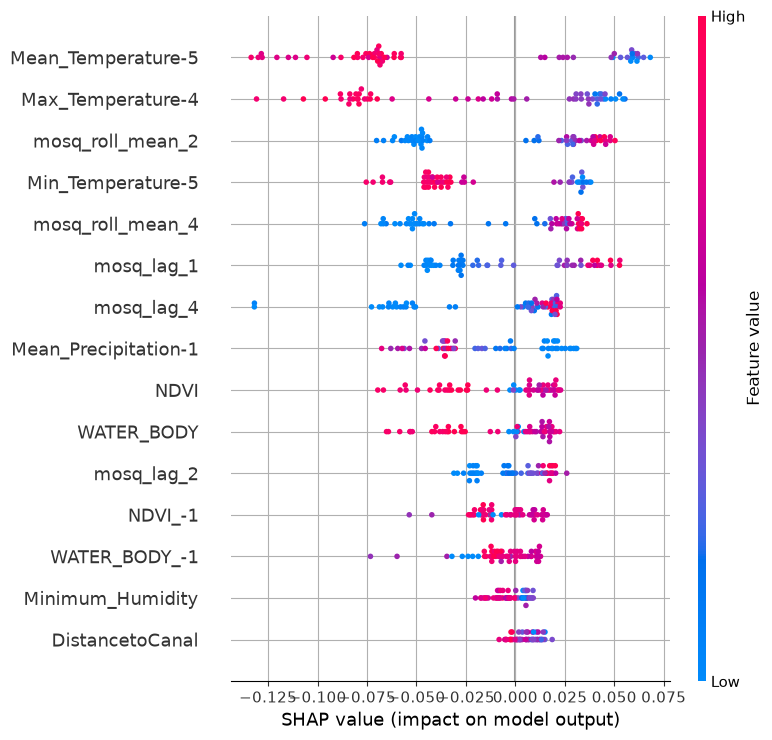

SHAP Summary Plot: Miami, 2-Week Lead, Hybrid Random Forest


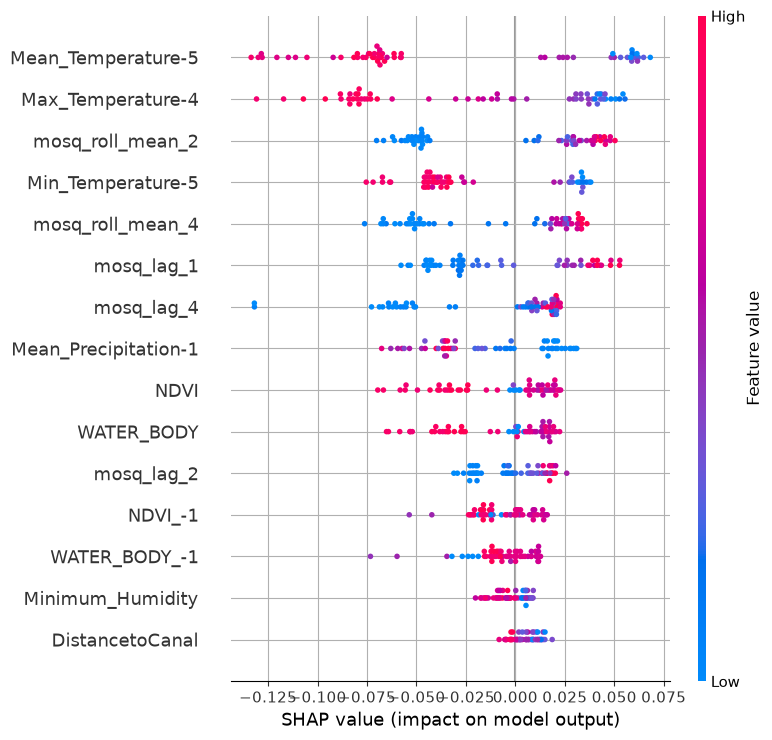

SHAP Summary Plot: Miami, 4-Week Lead, Hybrid Random Forest


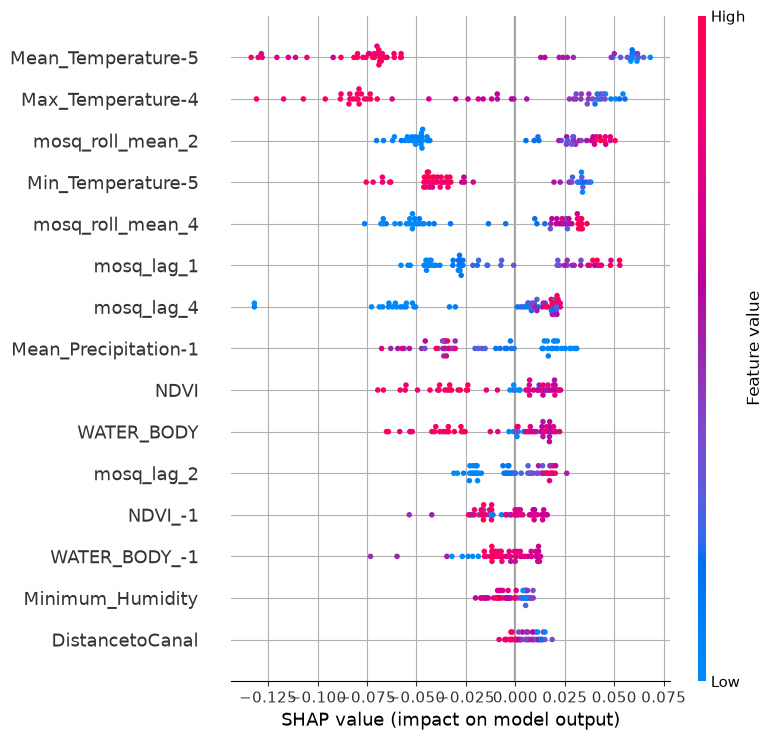

In [202]:
miami_shap_results = {}

for h in lead_horizons:
    miami_shap_results[h] = run_shap_for_hybrid_rf(
        fitted_models=miami_lead_models,
        city_name="Miami",
        horizon=h,
        max_display=15
    )

SHAP Summary Plot: Hialeah, 1-Week Lead, Hybrid Random Forest


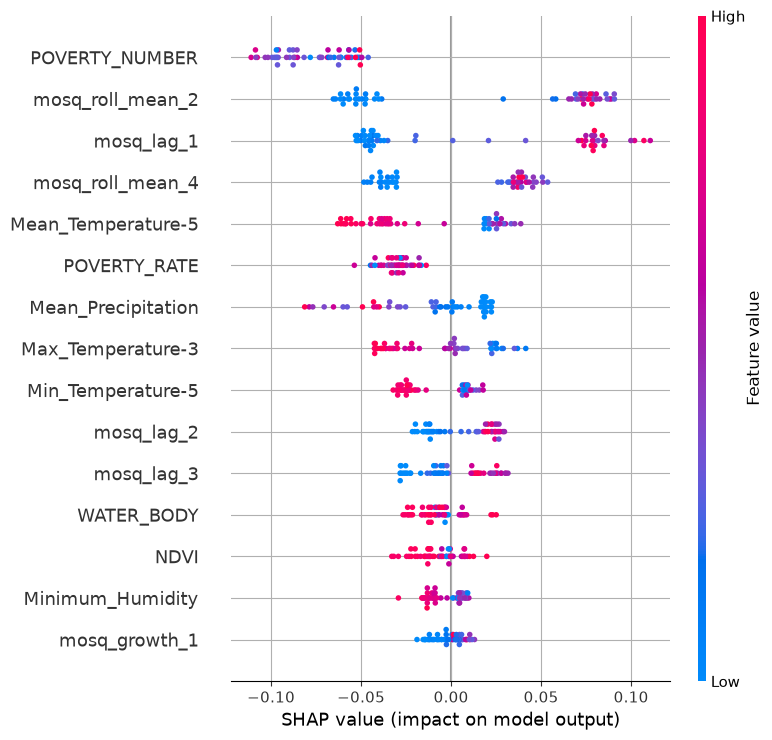

SHAP Summary Plot: Hialeah, 2-Week Lead, Hybrid Random Forest


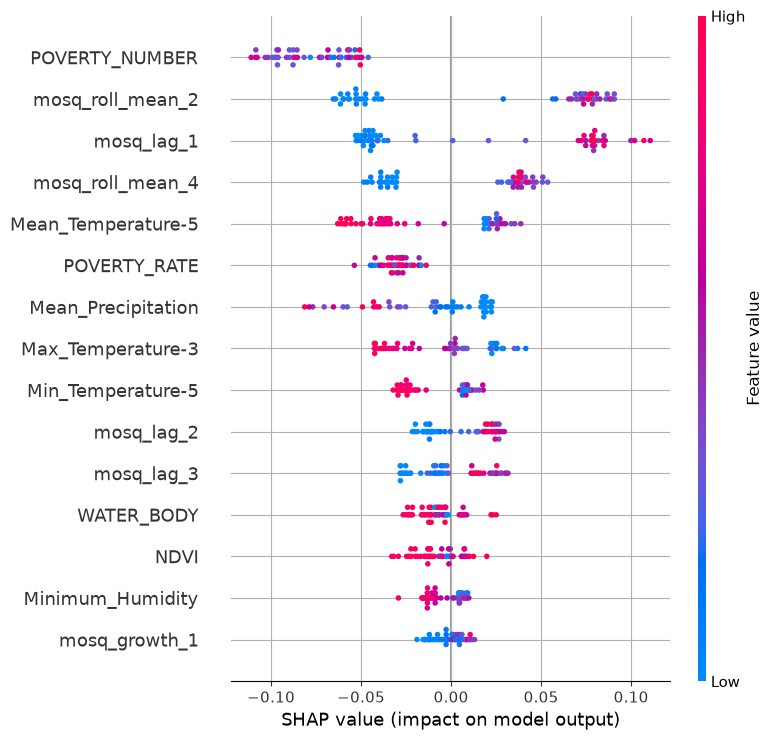

SHAP Summary Plot: Hialeah, 4-Week Lead, Hybrid Random Forest


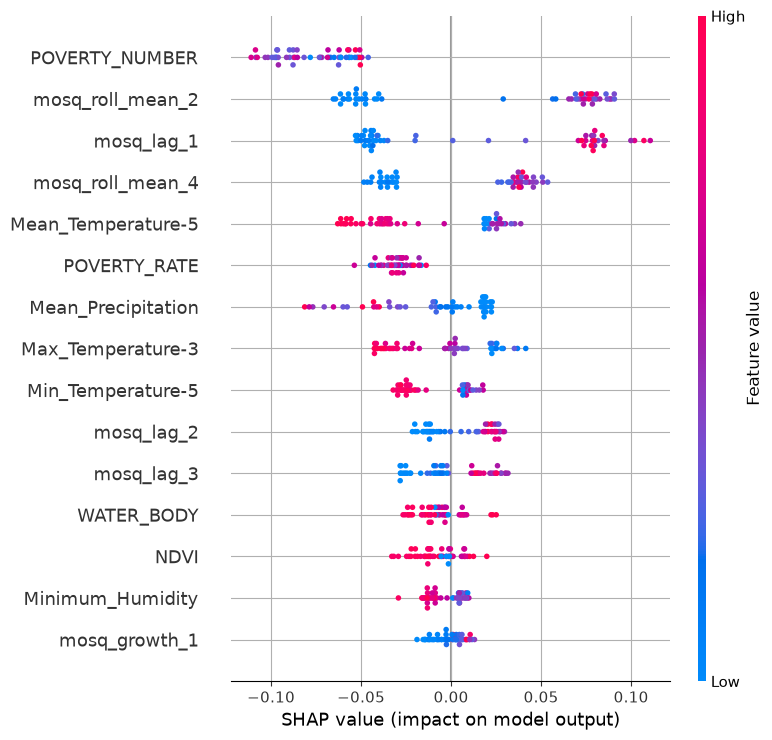

In [203]:
hialeah_shap_results = {}

for h in lead_horizons:
    hialeah_shap_results[h] = run_shap_for_hybrid_rf(
        fitted_models=hialeah_lead_models,
        city_name="Hialeah",
        horizon=h,
        max_display=15
    )

In [204]:
def shap_importance_table(shap_result):

    if shap_result is None:
        return pd.DataFrame()

    shap_values = shap_result["shap_values"]
    feature_cols = shap_result["features"]

    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    importance_df = pd.DataFrame({
        "City": shap_result["city"],
        "Lead Time (weeks)": shap_result["horizon"],
        "Feature": feature_cols,
        "Mean Absolute SHAP": mean_abs_shap
    })

    importance_df = importance_df.sort_values(
        "Mean Absolute SHAP",
        ascending=False
    ).reset_index(drop=True)

    return importance_df

In [205]:
all_shap_tables = []

for h, result in miami_shap_results.items():
    all_shap_tables.append(shap_importance_table(result))

for h, result in hialeah_shap_results.items():
    all_shap_tables.append(shap_importance_table(result))

combined_shap_importance = pd.concat(
    all_shap_tables,
    ignore_index=True
)

combined_shap_importance.head(30)

,City,Lead Time (weeks),Feature,Mean Absolute SHAP
0,Miami,1,Mean_Temperature-5,0.069223
1,Miami,1,Max_Temperature-4,0.053012
2,Miami,1,mosq_roll_mean_2,0.041162
3,Miami,1,Min_Temperature-5,0.039438
4,Miami,1,mosq_roll_mean_4,0.036978
5,Miami,1,mosq_lag_1,0.033607
6,Miami,1,mosq_lag_4,0.031100
7,Miami,1,Mean_Precipitation-1,0.028360
8,Miami,1,NDVI,0.022236
9,Miami,1,WATER_BODY,0.021646


In [206]:
top_shap_features_by_city_horizon = (
    combined_shap_importance
    .sort_values(
        ["City", "Lead Time (weeks)", "Mean Absolute SHAP"],
        ascending=[True, True, False]
    )
    .groupby(["City", "Lead Time (weeks)"])
    .head(10)
    .reset_index(drop=True)
)

top_shap_features_by_city_horizon

,City,Lead Time (weeks),Feature,Mean Absolute SHAP
0,Hialeah,1,POVERTY_NUMBER,0.076095
1,Hialeah,1,mosq_roll_mean_2,0.065122
2,Hialeah,1,mosq_lag_1,0.058924
3,Hialeah,1,mosq_roll_mean_4,0.038306
4,Hialeah,1,Mean_Temperature-5,0.035578
5,Hialeah,1,POVERTY_RATE,0.030302
6,Hialeah,1,Mean_Precipitation,0.025108
7,Hialeah,1,Max_Temperature-3,0.023500
8,Hialeah,1,Min_Temperature-5,0.018448
9,Hialeah,1,mosq_lag_2,0.017167


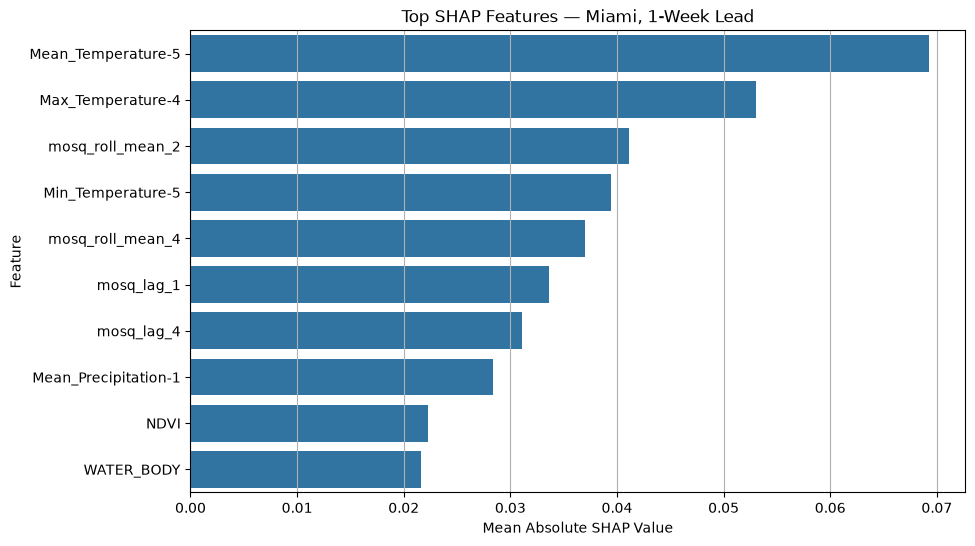

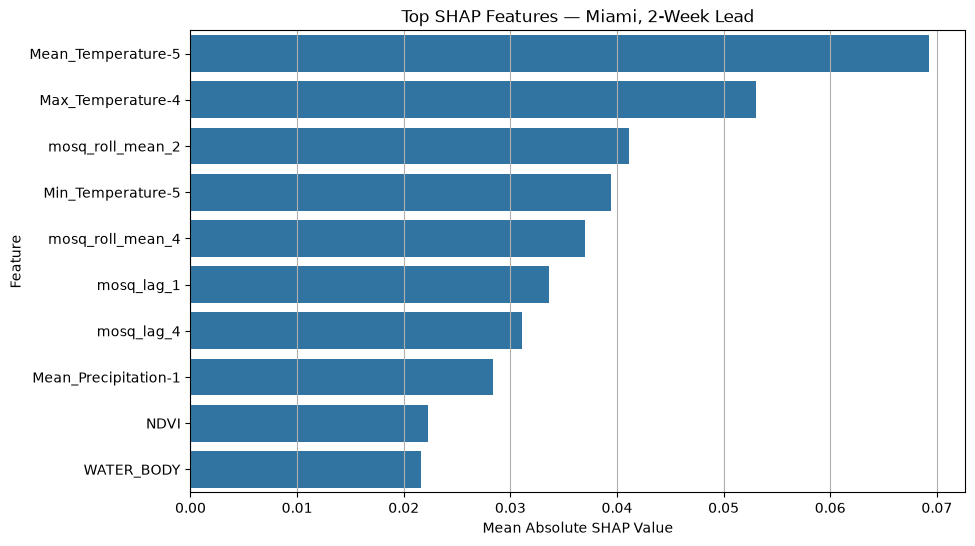

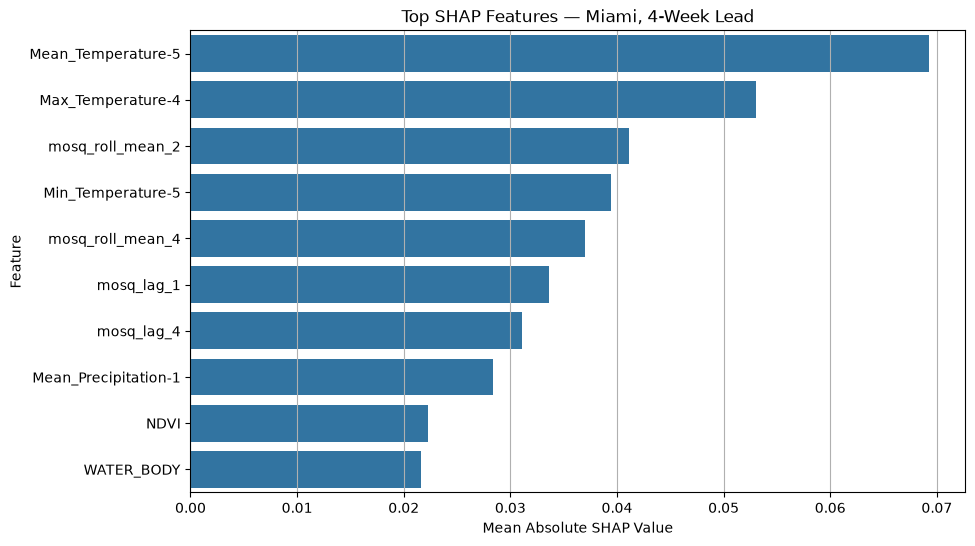

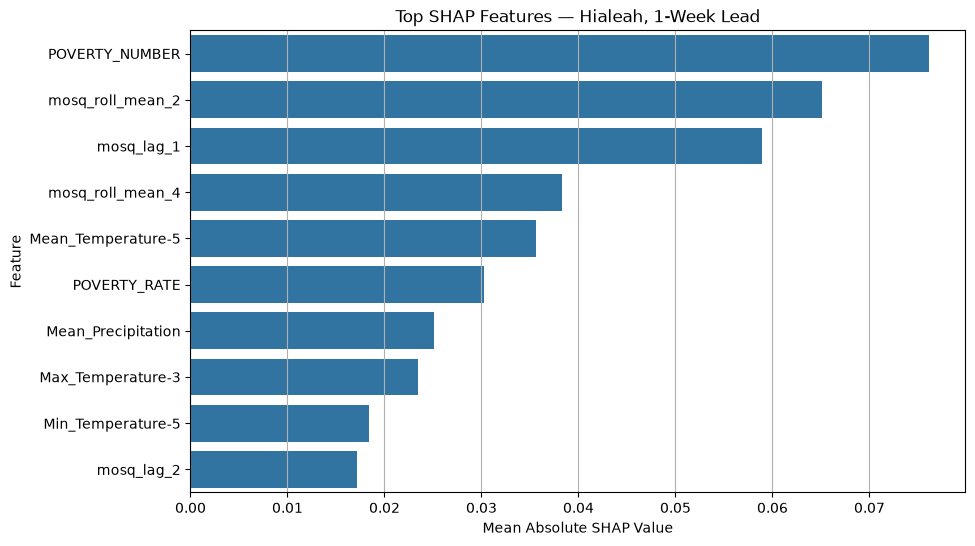

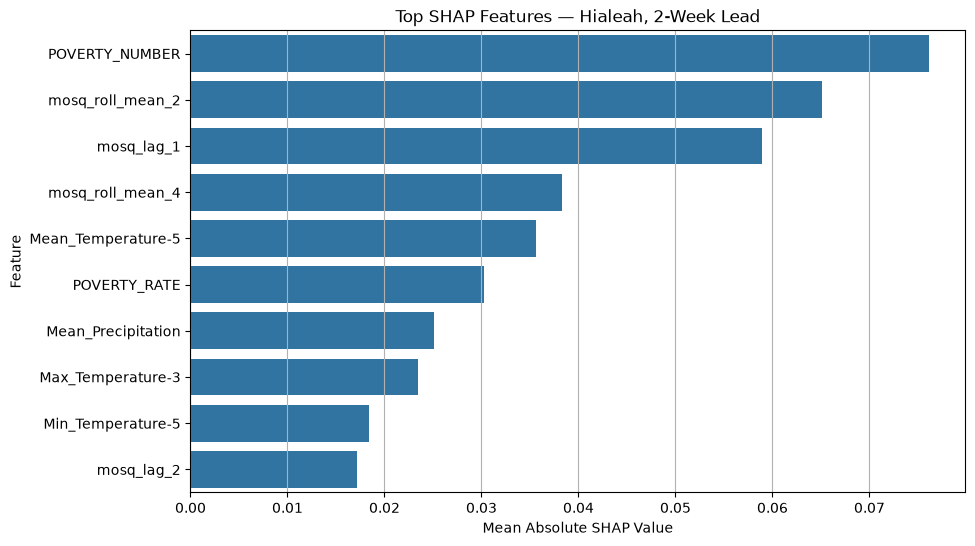

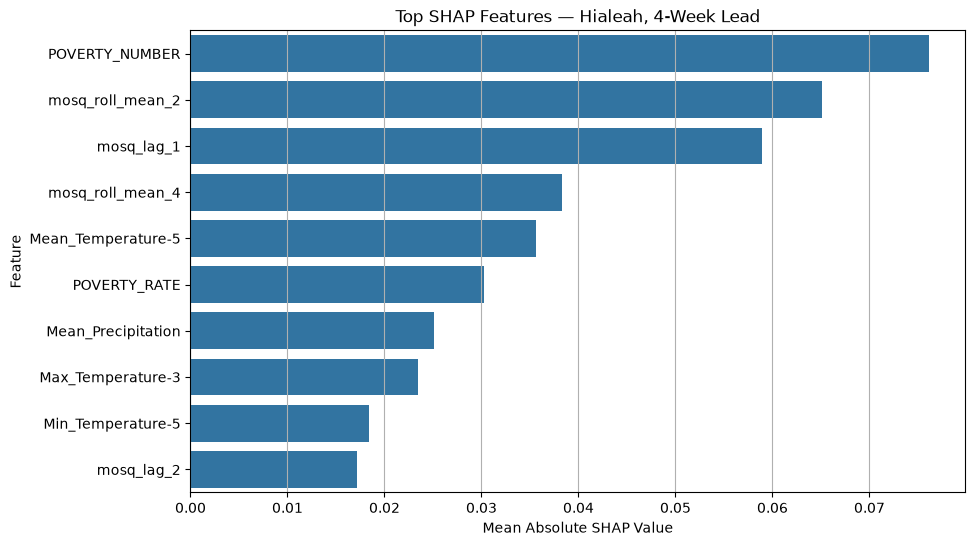

In [207]:
def plot_top_shap_features(shap_importance_df, city_name, horizon, top_n=10):
    plot_df = (
        shap_importance_df[
            (shap_importance_df["City"] == city_name) &
            (shap_importance_df["Lead Time (weeks)"] == horizon)
        ]
        .sort_values("Mean Absolute SHAP", ascending=False)
        .head(top_n)
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        data=plot_df,
        x="Mean Absolute SHAP",
        y="Feature"
    )

    plt.title(f"Top SHAP Features — {city_name}, {horizon}-Week Lead")
    plt.xlabel("Mean Absolute SHAP Value")
    plt.ylabel("Feature")
    plt.show()


for city in ["Miami", "Hialeah"]:
    for h in lead_horizons:
        plot_top_shap_features(
            combined_shap_importance,
            city_name=city,
            horizon=h,
            top_n=10
        )

In [208]:
def classify_feature_source(feature):
    if feature in MOSQ_HISTORY_COLS:
        return "Mosquito History"
    elif feature in ENV_FEATURE_COLS:
        return "Environmental / Context"
    else:
        return "Other"


combined_shap_importance["Feature Source"] = (
    combined_shap_importance["Feature"]
    .apply(classify_feature_source)
)

shap_source_summary = (
    combined_shap_importance
    .groupby(["City", "Lead Time (weeks)", "Feature Source"])
    .agg(
        Total_Mean_Abs_SHAP=("Mean Absolute SHAP", "sum"),
        Mean_Mean_Abs_SHAP=("Mean Absolute SHAP", "mean"),
        Number_of_Features=("Feature", "count")
    )
    .reset_index()
)

shap_source_summary

,City,Lead Time (weeks),Feature Source,Total_Mean_Abs_SHAP,Mean_Mean_Abs_SHAP,Number_of_Features
0,Hialeah,1,Environmental / Context,0.267656,0.016728,16
1,Hialeah,1,Mosquito History,0.209976,0.029997,7
2,Hialeah,2,Environmental / Context,0.267656,0.016728,16
3,Hialeah,2,Mosquito History,0.209976,0.029997,7
4,Hialeah,4,Environmental / Context,0.267656,0.016728,16
5,Hialeah,4,Mosquito History,0.209976,0.029997,7
6,Miami,1,Environmental / Context,0.295162,0.018448,16
7,Miami,1,Mosquito History,0.163756,0.023394,7
8,Miami,2,Environmental / Context,0.295162,0.018448,16
9,Miami,2,Mosquito History,0.163756,0.023394,7


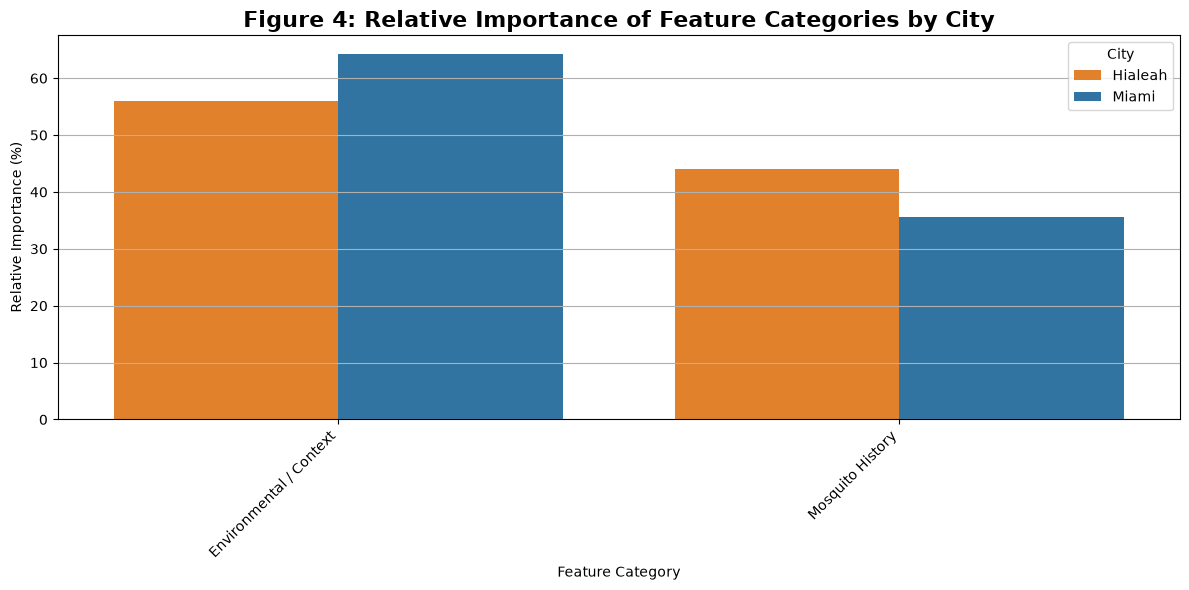

In [209]:
%matplotlib inline 

df_shap = combined_shap_importance.copy()

if 'Feature Source' in df_shap.columns:
    df_shap = df_shap.rename(columns={'Feature Source': 'Feature Category'})

if 'Feature Category' in df_shap.columns and 'Mean Absolute SHAP' in df_shap.columns:
    category_shap = df_shap.groupby(['City', 'Feature Category'])['Mean Absolute SHAP'].sum().reset_index()
    
    city_totals = category_shap.groupby('City')['Mean Absolute SHAP'].sum().reset_index()
    city_totals = city_totals.rename(columns={'Mean Absolute SHAP': 'Total SHAP'})
    
    category_shap = pd.merge(category_shap, city_totals, on='City')
    category_shap['Relative Importance (%)'] = (category_shap['Mean Absolute SHAP'] / category_shap['Total SHAP']) * 100
    
    df_shap_pivot = category_shap.pivot(index='Feature Category', columns='City', values='Relative Importance (%)').fillna(0)
    df_shap_pivot = df_shap_pivot.round(2)
    
    if 'Miami' in df_shap_pivot.columns:
        df_shap_pivot = df_shap_pivot.sort_values(by='Miami', ascending=False).reset_index()
    else:
        df_shap_pivot = df_shap_pivot.reset_index()
    
    plt.figure(figsize=(12, 6))
    
    df_shap_plot = df_shap_pivot.melt(id_vars='Feature Category', var_name='City', value_name='Relative Importance (%)')
    
    sns.barplot(
        data=df_shap_plot, 
        x='Feature Category', 
        y='Relative Importance (%)', 
        hue='City',
        palette={'Miami': '#1f77b4', 'Hialeah': '#ff7f0e'}
    )
    
    plt.title("Figure 4: Relative Importance of Feature Categories by City", fontsize=16, weight='bold')
    plt.ylabel("Relative Importance (%)")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    
    plt.show()

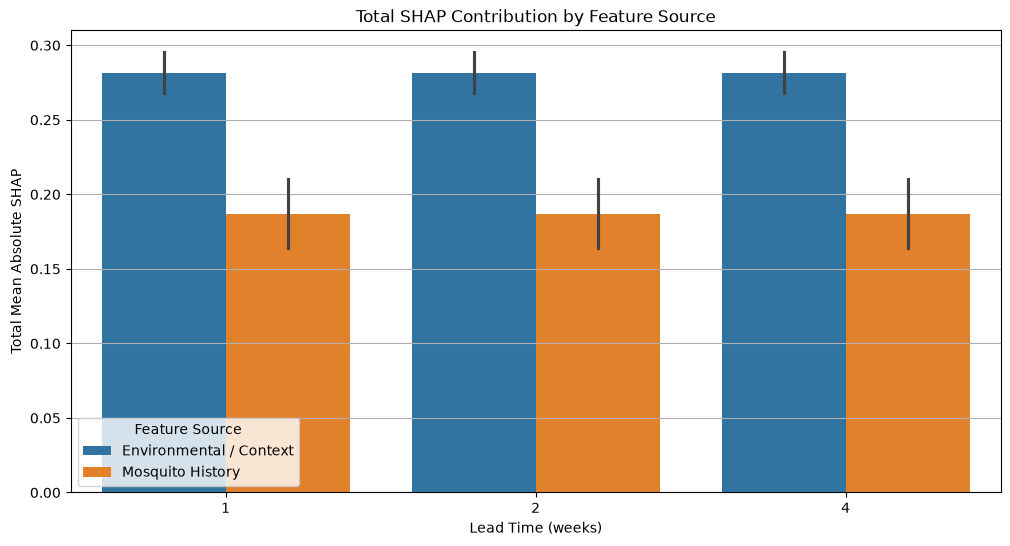

In [210]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=shap_source_summary,
    x="Lead Time (weeks)",
    y="Total_Mean_Abs_SHAP",
    hue="Feature Source"
)

plt.title("Total SHAP Contribution by Feature Source")
plt.xlabel("Lead Time (weeks)")
plt.ylabel("Total Mean Absolute SHAP")
plt.legend(title="Feature Source")
plt.show()

In [211]:
city_shap_driver_summary = (
    top_shap_features_by_city_horizon
    .groupby(["City", "Lead Time (weeks)"])
    .agg(
        Top_SHAP_Feature=("Feature", "first"),
        Top_SHAP_Value=("Mean Absolute SHAP", "first")
    )
    .reset_index()
)

city_shap_driver_summary

,City,Lead Time (weeks),Top_SHAP_Feature,Top_SHAP_Value
0,Hialeah,1,POVERTY_NUMBER,0.076095
1,Hialeah,2,POVERTY_NUMBER,0.076095
2,Hialeah,4,POVERTY_NUMBER,0.076095
3,Miami,1,Mean_Temperature-5,0.069223
4,Miami,2,Mean_Temperature-5,0.069223
5,Miami,4,Mean_Temperature-5,0.069223


In [212]:
combined_shap_importance.to_csv(
    "multivariate_shap_importance_all.csv",
    index=False
)

top_shap_features_by_city_horizon.to_csv(
    "multivariate_top_shap_features_by_city_horizon.csv",
    index=False
)

shap_source_summary.to_csv(
    "multivariate_shap_source_summary.csv",
    index=False
)

city_shap_driver_summary.to_csv(
    "multivariate_city_shap_driver_summary.csv",
    index=False
)